In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# CSV load karo
df = pd.read_csv('gold_loan_dataset_with_missing_values.csv')

# Shape dekho
print("=" * 40)
print(f"  Total Rows    : {df.shape[0]}")
print(f"  Total Columns : {df.shape[1]}")
print("=" * 40)

# Pehli 5 rows
df.head()

  Total Rows    : 300
  Total Columns : 18


,name,age,gender,city_tier,employment_type,monthly_income,existing_emi,dti,cibil_score,gold_weight_grams,gold_purity_karat,gold_value_estimated,ltv_ratio,loan_amount_requested,tenure_months,loan_status,approved_amount,interest_rate
0,Suresh Verma,59.0,Male,Urban,Salaried,13943.0,2273.0,0.163,705.0,158.46,22.0,798902.0,0.78,623144.0,6.0,1.0,NaN,10.84
1,Rohan Verma,49.0,Male,Metro,Salaried,33513.0,2615.0,0.078,733.0,26.83,22.0,135268.0,0.76,102804.0,6.0,1.0,NaN,10.63
2,Shruti Reddy,NaN,Female,NaN,Farmer,20217.0,2017.0,0.100,707.0,74.41,NaN,375150.0,0.80,300120.0,12.0,1.0,257144.0,10.75
3,Vivek Khan,63.0,Male,Metro,Business Owner,36743.0,7881.0,0.214,743.0,195.72,18.0,807345.0,0.79,637803.0,6.0,1.0,538431.0,10.88
4,Vivek Patel,28.0,Female,Urban,Business Owner,37832.0,85.0,0.002,582.0,159.83,22.0,805810.0,0.61,491544.0,6.0,1.0,412316.0,11.46


In [2]:
column_info = {
    # --- Personal Info ---
    'name'                 : 'Personal  | Applicant ka naam — ML mein use nahi hoga',
    'age'                  : 'Personal  | Applicant ki umar (years)',
    'gender'               : 'Personal  | Male / Female',
    'city_tier'            : 'Personal  | Metro / Urban / Rural',
    'employment_type'      : 'Personal  | Salaried / Farmer / Business Owner / Self-Employed',

    # --- Financial Info ---
    'monthly_income'       : 'Financial | Har mahine ki income (Rs)',
    'existing_emi'         : 'Financial | Pehle se chal raha EMI (Rs)',
    'dti'                  : 'Financial | Debt-to-Income ratio — income ka % jo EMI mein ja raha hai',
    'cibil_score'          : 'Financial | Credit score (300-900) — zyada = achha',

    # --- Gold Info ---
    'gold_weight_grams'    : 'Gold      | Girvee rakhe sone ka wajan (grams)',
    'gold_purity_karat'    : 'Gold      | Shuddha kitna — 18K / 22K / 24K',
    'gold_value_estimated' : 'Gold      | Bank ki estimated gold value (Rs)',
    'ltv_ratio'            : 'Gold      | Loan-to-Value ratio (max 85%)',

    # --- Loan Info ---
    'loan_amount_requested': 'Loan      | Applicant ne kitna loan maanga (Rs)',
    'tenure_months'        : 'Loan      | Loan duration — 3/6/9/12/18/24 months',

    # --- Target Variables ---
    'loan_status'          : 'TARGET    | 0 = Rejected, 1 = Approved (Classification)',
    'approved_amount'      : 'TARGET    | Kitna loan actually mila (Rs) (Regression 1)',
    'interest_rate'        : 'TARGET    | Byaj dar (%) (Regression 2)',
}

print(f"{'Column':<25} {'Category | Matlab'}")
print("-" * 75)
for col, meaning in column_info.items():
    print(f"{col:<25} {meaning}")

Column                    Category | Matlab
---------------------------------------------------------------------------
name                      Personal  | Applicant ka naam — ML mein use nahi hoga
age                       Personal  | Applicant ki umar (years)
gender                    Personal  | Male / Female
city_tier                 Personal  | Metro / Urban / Rural
employment_type           Personal  | Salaried / Farmer / Business Owner / Self-Employed
monthly_income            Financial | Har mahine ki income (Rs)
existing_emi              Financial | Pehle se chal raha EMI (Rs)
dti                       Financial | Debt-to-Income ratio — income ka % jo EMI mein ja raha hai
cibil_score               Financial | Credit score (300-900) — zyada = achha
gold_weight_grams         Gold      | Girvee rakhe sone ka wajan (grams)
gold_purity_karat         Gold      | Shuddha kitna — 18K / 22K / 24K
gold_value_estimated      Gold      | Bank ki estimated gold value (Rs)
ltv_ratio       

In [3]:
print("Data Types — Har Column:\n")
print(f"{'Column':<25} {'Dtype':<12} {'Category'}")
print("-" * 55)

for col in df.columns:
    dtype = str(df[col].dtype)
    if dtype in ['int64', 'float64']:
        cat = 'Numeric'
    else:
        cat = 'Categorical'
    print(f"{col:<25} {dtype:<12} {cat}")

Data Types — Har Column:

Column                    Dtype        Category
-------------------------------------------------------
name                      object       Categorical
age                       float64      Numeric
gender                    object       Categorical
city_tier                 object       Categorical
employment_type           object       Categorical
monthly_income            float64      Numeric
existing_emi              float64      Numeric
dti                       float64      Numeric
cibil_score               float64      Numeric
gold_weight_grams         float64      Numeric
gold_purity_karat         float64      Numeric
gold_value_estimated      float64      Numeric
ltv_ratio                 float64      Numeric
loan_amount_requested     float64      Numeric
tenure_months             float64      Numeric
loan_status               float64      Numeric
approved_amount           float64      Numeric
interest_rate             float64      Numeric


In [4]:
print("Numerical Columns — Basic Statistics:\n")
df.describe().round(2)

Numerical Columns — Basic Statistics:



,age,monthly_income,existing_emi,dti,cibil_score,gold_weight_grams,gold_purity_karat,gold_value_estimated,ltv_ratio,loan_amount_requested,tenure_months,loan_status,approved_amount,interest_rate
count,285.00,285.00,285.00,285.00,285.00,285.00,285.00,285.00,285.00,285.00,285.00,285.00,285.00,258.00
mean,42.77,36817.40,4595.01,0.12,702.18,103.45,21.63,507349.15,0.73,371270.49,10.67,0.91,286190.53,11.08
std,13.14,12903.76,3156.73,0.07,56.28,57.47,1.76,282807.25,0.07,211271.19,5.73,0.28,194791.66,0.34
min,21.00,5000.00,17.00,0.00,537.00,5.04,18.00,25529.00,0.60,16516.00,3.00,0.00,0.00,10.20
25%,31.00,27866.00,1957.00,0.06,666.00,55.06,20.00,261800.00,0.67,187157.00,6.00,1.00,103888.00,10.81
50%,44.00,35956.00,4295.00,0.13,705.00,102.92,22.00,502883.00,0.74,372887.00,9.00,1.00,286543.00,11.06
75%,55.00,45009.00,6615.00,0.18,742.00,153.05,22.00,752469.00,0.79,539244.00,12.00,1.00,445622.00,11.32
max,64.00,72258.00,15937.00,0.25,862.00,199.43,24.00,1042745.00,0.85,891492.00,24.00,1.00,817750.00,11.86


In [5]:
print("NULL Values Check:\n")
print(f"{'Column':<25} {'Null Count':>12} {'Null %':>10}")
print("-" * 50)

for col in df.columns:
    null_count = df[col].isnull().sum()
    null_pct   = round(null_count / len(df) * 100, 2)
    flag       = " ⚠️" if null_count > 0 else " ✅"
    print(f"{col:<25} {null_count:>12} {null_pct:>9}%{flag}")

print()
print(f"Total nulls in dataset : {df.isnull().sum().sum()}")

NULL Values Check:

Column                      Null Count     Null %
--------------------------------------------------
name                                15       5.0% ⚠️
age                                 15       5.0% ⚠️
gender                              15       5.0% ⚠️
city_tier                           15       5.0% ⚠️
employment_type                     15       5.0% ⚠️
monthly_income                      15       5.0% ⚠️
existing_emi                        15       5.0% ⚠️
dti                                 15       5.0% ⚠️
cibil_score                         15       5.0% ⚠️
gold_weight_grams                   15       5.0% ⚠️
gold_purity_karat                   15       5.0% ⚠️
gold_value_estimated                15       5.0% ⚠️
ltv_ratio                           15       5.0% ⚠️
loan_amount_requested               15       5.0% ⚠️
tenure_months                       15       5.0% ⚠️
loan_status                         15       5.0% ⚠️
approved_amount                

In [6]:
dup_count = df.duplicated().sum()

print("Duplicate Rows Check:")
print("-" * 35)
print(f"  Total Rows       : {len(df)}")
print(f"  Duplicate Rows   : {dup_count}")

if dup_count > 0:
    print(f"\n  ⚠️  Duplicates mile hain — Phase 2 mein drop karenge")
    print(df[df.duplicated()])
else:
    print(f"\n  ✅ Koi duplicate nahi — dataset clean hai")

Duplicate Rows Check:
-----------------------------------
  Total Rows       : 300
  Duplicate Rows   : 0

  ✅ Koi duplicate nahi — dataset clean hai


In [7]:
print("=" * 55)
print("  TARGET VARIABLES — IDENTIFICATION")
print("=" * 55)
print()
print("  🎯 Classification  → loan_status")
print(f"     Values : {df['loan_status'].unique()}")
print(f"     Counts : {df['loan_status'].value_counts().to_dict()}")
print(f"     Matlab : 0 = Rejected, 1 = Approved")
print()
print("  🎯 Regression 1   → approved_amount")
print(f"     Range  : Rs {df['approved_amount'].min():,.0f} to Rs {df['approved_amount'].max():,.0f}")
print(f"     Nulls  : {df['approved_amount'].isnull().sum()}")
print()
print("  🎯 Regression 2   → interest_rate")
print(f"     Range  : {df['interest_rate'].min()}% to {df['interest_rate'].max()}%")
print(f"     Nulls  : {df['interest_rate'].isnull().sum()} (rejected cases ka rate nahi hota)")
print()
print("  🎯 Clustering     → Koi target nahi (Unsupervised)")
print()
print("  ❌ X, y alag NAHI kiya — Phase 5 mein hoga")
print("  ❌ Koi bhi split NAHI kiya")
print("=" * 55)

  TARGET VARIABLES — IDENTIFICATION

  🎯 Classification  → loan_status
     Values : [ 1.  0. nan]
     Counts : {1.0: 260, 0.0: 25}
     Matlab : 0 = Rejected, 1 = Approved

  🎯 Regression 1   → approved_amount
     Range  : Rs 0 to Rs 817,750
     Nulls  : 15

  🎯 Regression 2   → interest_rate
     Range  : 10.2% to 11.86%
     Nulls  : 42 (rejected cases ka rate nahi hota)

  🎯 Clustering     → Koi target nahi (Unsupervised)

  ❌ X, y alag NAHI kiya — Phase 5 mein hoga
  ❌ Koi bhi split NAHI kiya


In [8]:
cat_cols = ['gender', 'city_tier', 'employment_type']

print("Categorical Columns — Unique Values & Counts:\n")

for col in cat_cols:
    print(f"📌 {col}:")
    counts = df[col].value_counts()
    for val, cnt in counts.items():
        pct = round(cnt / len(df) * 100, 1)
        print(f"     {val:<20} → {cnt} records ({pct}%)")
    print()

Categorical Columns — Unique Values & Counts:

📌 gender:
     Female               → 151 records (50.3%)
     Male                 → 134 records (44.7%)

📌 city_tier:
     Metro                → 126 records (42.0%)
     Urban                → 104 records (34.7%)
     Rural                → 55 records (18.3%)

📌 employment_type:
     Salaried             → 97 records (32.3%)
     Self-Employed        → 83 records (27.7%)
     Business Owner       → 56 records (18.7%)
     Farmer               → 49 records (16.3%)



In [9]:
print("=" * 50)
print("✅  PHASE 1 — DATA UNDERSTANDING — COMPLETE")
print("=" * 50)
print(f"  Dataset Shape    : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"  Numeric Columns  : {len(df.select_dtypes(include=['int64','float64']).columns)}")
print(f"  Categorical Cols : {len(df.select_dtypes(include='object').columns)}")
print(f"  Total Nulls      : {df.isnull().sum().sum()} (sirf interest_rate mein 28)")
print(f"  Duplicates       : {df.duplicated().sum()}")
print()
print("  Targets Identified:")
print("    Classification → loan_status")
print("    Regression 1   → approved_amount")
print("    Regression 2   → interest_rate")
print("    Clustering     → No target")
print()
print("  ➡️  Agla Step : PHASE 2 — Data Preprocessing")
print("=" * 50)

✅  PHASE 1 — DATA UNDERSTANDING — COMPLETE
  Dataset Shape    : 300 rows x 18 columns
  Numeric Columns  : 14
  Categorical Cols : 4
  Total Nulls      : 297 (sirf interest_rate mein 28)
  Duplicates       : 0

  Targets Identified:
    Classification → loan_status
    Regression 1   → approved_amount
    Regression 2   → interest_rate
    Clustering     → No target

  ➡️  Agla Step : PHASE 2 — Data Preprocessing


**PREPROCESSING**

In [10]:
print("NULL Values — BEFORE Filling:\n")
print(f"{'Column':<25} {'Null Count':>12} {'Null %':>10}")
print("-" * 50)

for col in df.columns:
    null_count = df[col].isnull().sum()
    null_pct   = round(null_count / len(df) * 100, 2)
    flag       = " ⚠️" if null_count > 0 else " ✅"
    print(f"{col:<25} {null_count:>12} {null_pct:>9}%{flag}")

print()
print(f"Total nulls : {df.isnull().sum().sum()}")
print()
print("⚠️  interest_rate mein 28 nulls hain")
print("    Reason : Rejected cases ko koi rate assign nahi hota")
print("    Fix    : Median se fill karenge")

NULL Values — BEFORE Filling:

Column                      Null Count     Null %
--------------------------------------------------
name                                15       5.0% ⚠️
age                                 15       5.0% ⚠️
gender                              15       5.0% ⚠️
city_tier                           15       5.0% ⚠️
employment_type                     15       5.0% ⚠️
monthly_income                      15       5.0% ⚠️
existing_emi                        15       5.0% ⚠️
dti                                 15       5.0% ⚠️
cibil_score                         15       5.0% ⚠️
gold_weight_grams                   15       5.0% ⚠️
gold_purity_karat                   15       5.0% ⚠️
gold_value_estimated                15       5.0% ⚠️
ltv_ratio                           15       5.0% ⚠️
loan_amount_requested               15       5.0% ⚠️
tenure_months                       15       5.0% ⚠️
loan_status                         15       5.0% ⚠️
approved_amount     

In [11]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numeric Columns → Median se fill:\n")
print(f"{'Column':<25} {'Null Before':>12} {'Median Value':>15} {'Null After':>12}")
print("-" * 68)

for col in numeric_cols:
    null_before = df[col].isnull().sum()
    if null_before > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        null_after = df[col].isnull().sum()
        print(f"{col:<25} {null_before:>12} {median_val:>15.4f} {null_after:>12} ✅")
    else:
        print(f"{col:<25} {null_before:>12} {'—':>15} {'—':>12} ✅ no null")

Numeric Columns → Median se fill:

Column                     Null Before    Median Value   Null After
--------------------------------------------------------------------
age                                 15         44.0000            0 ✅
monthly_income                      15      35956.0000            0 ✅
existing_emi                        15       4295.0000            0 ✅
dti                                 15          0.1300            0 ✅
cibil_score                         15        705.0000            0 ✅
gold_weight_grams                   15        102.9200            0 ✅
gold_purity_karat                   15         22.0000            0 ✅
gold_value_estimated                15     502883.0000            0 ✅
ltv_ratio                           15          0.7400            0 ✅
loan_amount_requested               15     372887.0000            0 ✅
tenure_months                       15          9.0000            0 ✅
loan_status                         15          1.0000    

In [12]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Categorical Columns → Mode se fill:\n")
print(f"{'Column':<25} {'Null Before':>12} {'Mode Value':>15} {'Null After':>12}")
print("-" * 68)

for col in cat_cols:
    null_before = df[col].isnull().sum()
    if null_before > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        null_after = df[col].isnull().sum()
        print(f"{col:<25} {null_before:>12} {mode_val:>15} {null_after:>12} ✅")
    else:
        print(f"{col:<25} {null_before:>12} {'—':>15} {'—':>12} ✅ no null")

print()
print(f"Total nulls after filling : {df.isnull().sum().sum()}")

Categorical Columns → Mode se fill:

Column                     Null Before      Mode Value   Null After
--------------------------------------------------------------------
name                                15   Aaditya Patel            0 ✅
gender                              15          Female            0 ✅
city_tier                           15           Metro            0 ✅
employment_type                     15        Salaried            0 ✅

Total nulls after filling : 0


In [13]:
print("NULL Values — AFTER Filling:\n")

null_total = df.isnull().sum().sum()

if null_total == 0:
    print("✅ Koi bhi null nahi bacha — dataset clean hai!")
else:
    print(f"⚠️  Abhi bhi {null_total} nulls hain:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

NULL Values — AFTER Filling:

✅ Koi bhi null nahi bacha — dataset clean hai!


In [14]:
print("Duplicate Rows Check + Drop:\n")

dup_before = df.duplicated().sum()
print(f"  Duplicates before drop : {dup_before}")

if dup_before > 0:
    print("\n  Duplicate rows:")
    print(df[df.duplicated()])
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"\n  ✅ {dup_before} duplicates drop kiye")
else:
    print("  ✅ Koi duplicate nahi mila")

print(f"\n  Dataset shape after dedup : {df.shape}")

Duplicate Rows Check + Drop:

  Duplicates before drop : 0
  ✅ Koi duplicate nahi mila

  Dataset shape after dedup : (300, 18)


In [15]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("IQR Method — Outlier Count per Column:\n")
print(f"{'Column':<25} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lower':>12} {'Upper':>12} {'Outliers':>10}")
print("-" * 95)

outlier_bounds = {}

for col in numeric_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    outlier_bounds[col] = {'lower': lower, 'upper': upper}

    flag = " ⚠️" if count > 0 else " ✅"
    print(f"{col:<25} {Q1:>10.2f} {Q3:>10.2f} {IQR:>10.2f} {lower:>12.2f} {upper:>12.2f} {count:>10}{flag}")

IQR Method — Outlier Count per Column:

Column                            Q1         Q3        IQR        Lower        Upper   Outliers
-----------------------------------------------------------------------------------------------
age                            32.00      53.25      21.25         0.12        85.12          0 ✅
monthly_income              28169.25   44539.50   16370.25      3613.88     69094.88          1 ⚠️
existing_emi                 2023.75    6547.25    4523.50     -4761.50     13332.50          2 ⚠️
dti                             0.06       0.17       0.11        -0.10         0.33          0 ✅
cibil_score                   668.00     740.25      72.25       559.62       848.62          3 ⚠️
gold_weight_grams              57.00     151.56      94.55       -84.83       293.38          0 ✅
gold_purity_karat              20.00      22.00       2.00        17.00        25.00          0 ✅
gold_value_estimated       275098.50  748175.25  473076.75   -434516.62   14577

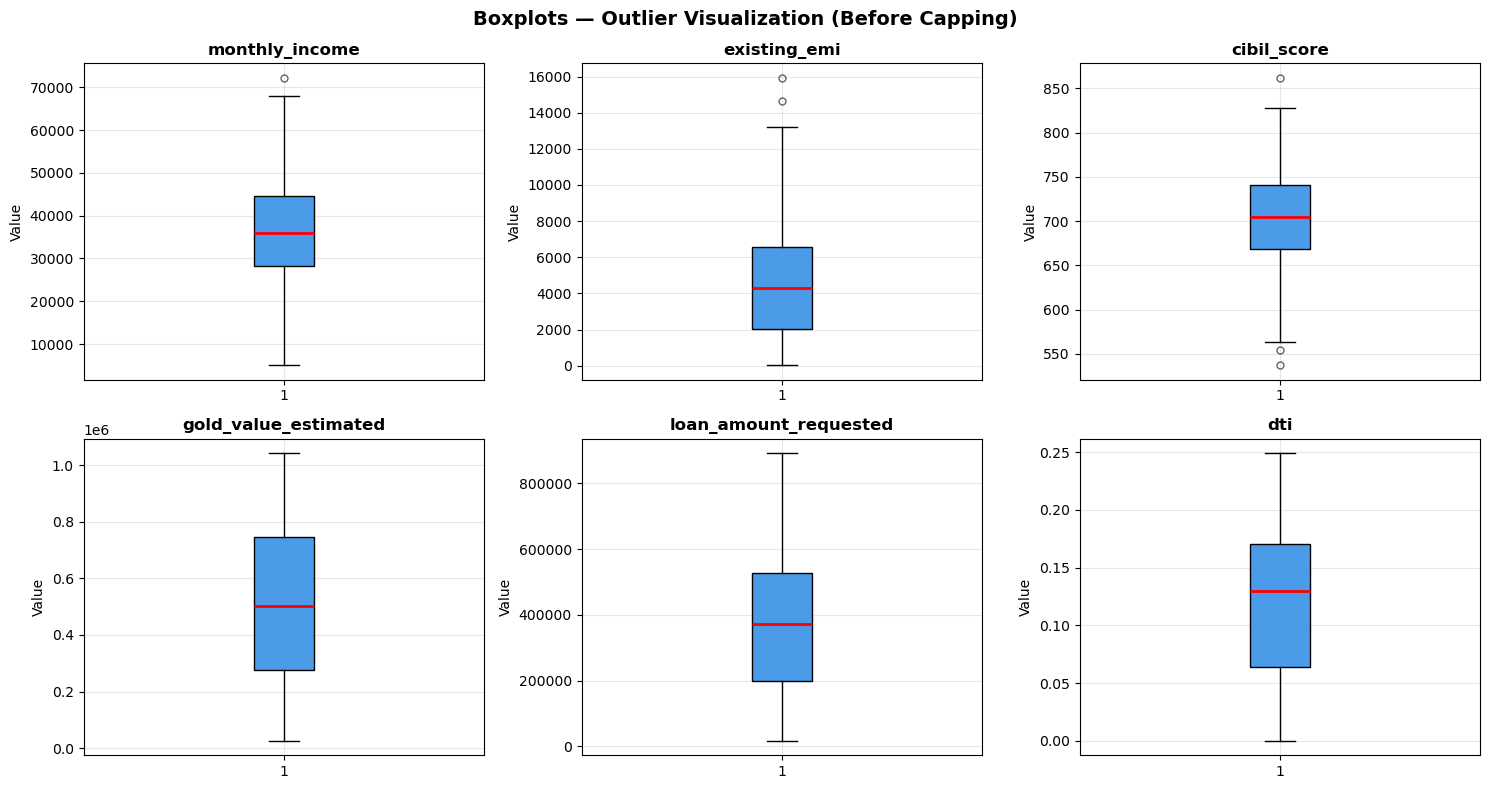

✅ Boxplot shown — orange dots = outliers


In [16]:
import matplotlib.pyplot as plt

cols_to_plot = ['monthly_income', 'existing_emi', 'cibil_score',
                'gold_value_estimated', 'loan_amount_requested', 'dti']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Boxplots — Outlier Visualization (Before Capping)',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), cols_to_plot):
    ax.boxplot(df[col].dropna(),
               patch_artist=True,
               boxprops=dict(facecolor='#4C9BE8', color='black'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', color='orange',
                               alpha=0.6, markersize=5))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Boxplot shown — orange dots = outliers")

In [17]:
cols_to_cap = ['monthly_income', 'existing_emi', 'gold_value_estimated',
               'loan_amount_requested', 'approved_amount', 'dti',
               'cibil_score', 'gold_weight_grams']

print("Winsorizing (Capping) — Outlier Treatment:\n")
print(f"{'Column':<25} {'Outliers Before':>16} {'Lower Cap':>12} {'Upper Cap':>12} {'Outliers After':>15}")
print("-" * 85)

for col in cols_to_cap:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    df[col] = df[col].clip(lower=lower, upper=upper)
    after  = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    print(f"{col:<25} {before:>16} {lower:>12.2f} {upper:>12.2f} {after:>15} ✅")

print()
print("✅ Winsorizing complete")
print("   Remove nahi kiya — values sirf clip ki hain")
print("   Real gold loan cases preserve hue hain")

Winsorizing (Capping) — Outlier Treatment:

Column                     Outliers Before    Lower Cap    Upper Cap  Outliers After
-------------------------------------------------------------------------------------
monthly_income                           1      3613.88     69094.88               0 ✅
existing_emi                             2     -4761.50     13332.50               0 ✅
gold_value_estimated                     0   -434516.62   1457790.38               0 ✅
loan_amount_requested                    0   -295824.00   1019120.00               0 ✅
approved_amount                          0   -368570.88    920290.12               0 ✅
dti                                      0        -0.10         0.33               0 ✅
cibil_score                              3       559.62       848.62               0 ✅
gold_weight_grams                        0       -84.83       293.38               0 ✅

✅ Winsorizing complete
   Remove nahi kiya — values sirf clip ki hain
   Real gold loan 

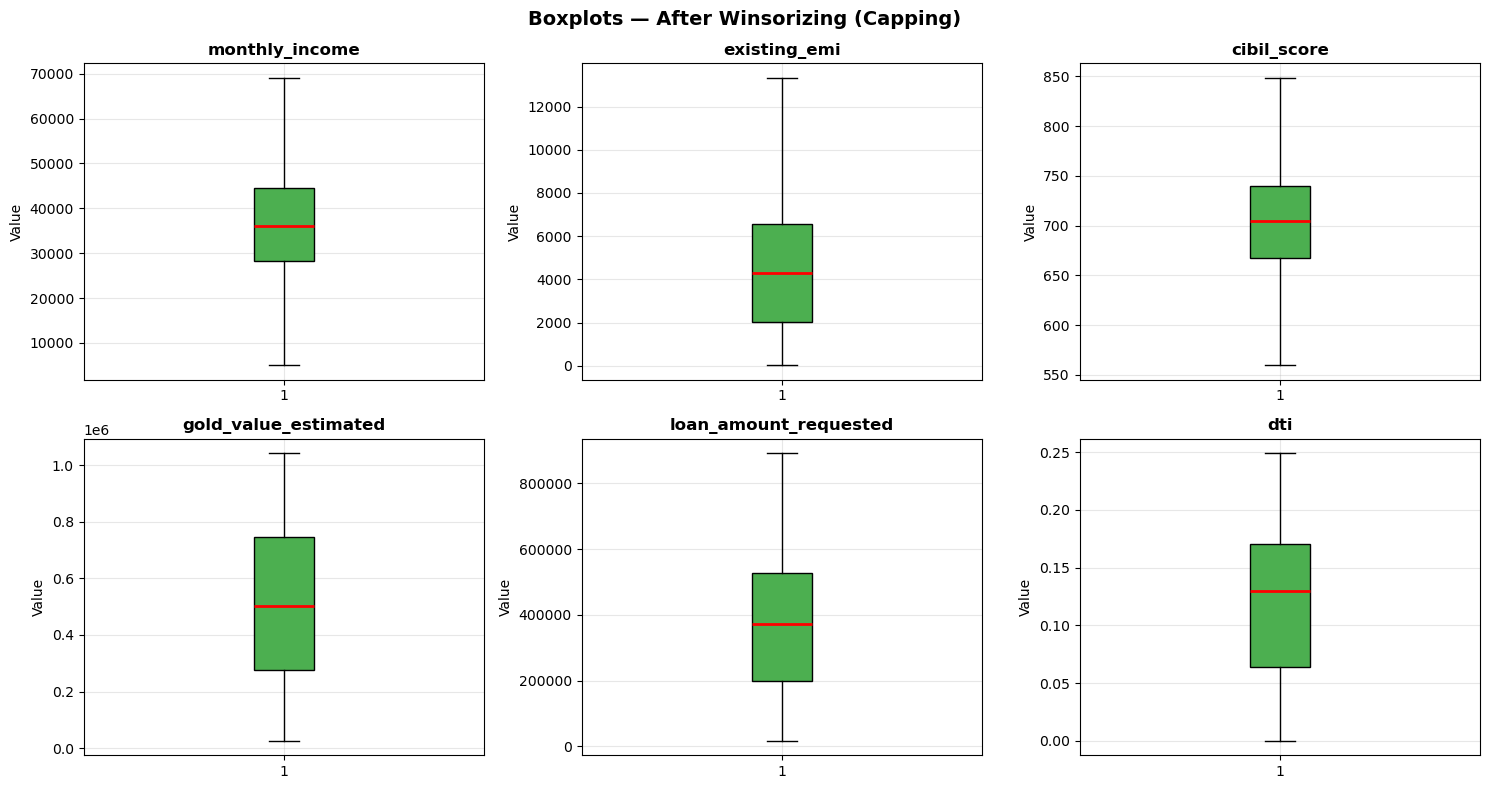

✅ After capping — outliers significantly reduced


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Boxplots — After Winsorizing (Capping)',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), cols_to_plot):
    ax.boxplot(df[col].dropna(),
               patch_artist=True,
               boxprops=dict(facecolor='#4CAF50', color='black'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', color='orange',
                               alpha=0.6, markersize=5))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ After capping — outliers significantly reduced")

In [19]:
print("'name' Column Drop:\n")
print(f"  Before drop — Columns : {df.shape[1]}")
print(f"  'name' sample values  : {df['name'].head(3).tolist()}")
print()

df = df.drop(columns=['name'])

print(f"  After drop — Columns  : {df.shape[1]}")
print(f"  ✅ 'name' column drop kiya")
print(f"     Reason : Sirf identifier hai — ML mein kaam ka nahi")
print()
print(f"  Remaining columns ({df.shape[1]}):")
print(f"  {df.columns.tolist()}")

'name' Column Drop:

  Before drop — Columns : 18
  'name' sample values  : ['Suresh Verma', 'Rohan Verma', 'Shruti Reddy']

  After drop — Columns  : 17
  ✅ 'name' column drop kiya
     Reason : Sirf identifier hai — ML mein kaam ka nahi

  Remaining columns (17):
  ['age', 'gender', 'city_tier', 'employment_type', 'monthly_income', 'existing_emi', 'dti', 'cibil_score', 'gold_weight_grams', 'gold_purity_karat', 'gold_value_estimated', 'ltv_ratio', 'loan_amount_requested', 'tenure_months', 'loan_status', 'approved_amount', 'interest_rate']


In [20]:
print("=" * 52)
print("✅  PHASE 2 — DATA PREPROCESSING — COMPLETE")
print("=" * 52)
print(f"  Final Shape       : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"  Total Nulls       : {df.isnull().sum().sum()}")
print(f"  Duplicates        : {df.duplicated().sum()}")
print()
print("  Steps Done:")
print("  ✅ Step 2.1 — Nulls filled (Median + Mode)")
print("  ✅ Step 2.2 — Duplicates checked/dropped")
print("  ✅ Step 2.3 — Outliers capped (Winsorizing)")
print("  ✅ Step 2.4 — 'name' column dropped")
print()
print("  ❌ Encoding — Phase 7 mein hoga")
print("  ❌ Scaling  — Phase 7 mein hoga")
print("  ❌ X, y split — Phase 6 mein hoga")
print()
print("  ➡️  Agla Step : PHASE 3 — EDA")
print("=" * 52)

✅  PHASE 2 — DATA PREPROCESSING — COMPLETE
  Final Shape       : 300 rows x 17 columns
  Total Nulls       : 0
  Duplicates        : 0

  Steps Done:
  ✅ Step 2.1 — Nulls filled (Median + Mode)
  ✅ Step 2.2 — Duplicates checked/dropped
  ✅ Step 2.3 — Outliers capped (Winsorizing)
  ✅ Step 2.4 — 'name' column dropped

  ❌ Encoding — Phase 7 mein hoga
  ❌ Scaling  — Phase 7 mein hoga
  ❌ X, y split — Phase 6 mein hoga

  ➡️  Agla Step : PHASE 3 — EDA


**EDA**


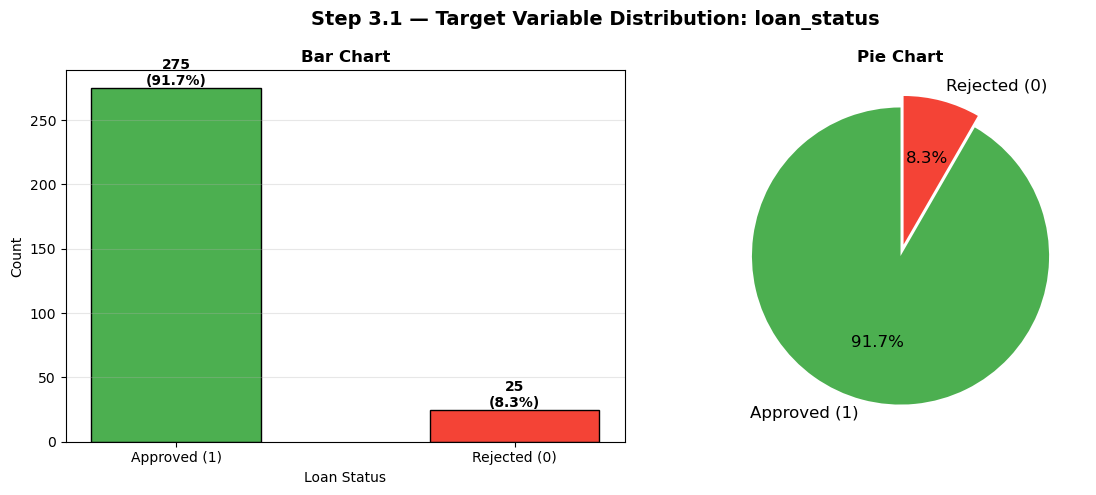

Approved (1) : 275  (91.7%)
Rejected (0) : 25  (8.3%)
⚠️  Class Imbalance hai — Phase 8 mein SMOTE se handle karenge


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Step 3.1 — Target Variable Distribution: loan_status',
             fontsize=14, fontweight='bold')

# counts
status_counts = df['loan_status'].value_counts()
labels        = ['Approved (1)', 'Rejected (0)']
colors        = ['#4CAF50', '#F44336']

# --- Bar Chart ---
axes[0].bar(labels, status_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Bar Chart', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Loan Status')
for i, v in enumerate(status_counts.values):
    pct = round(v / len(df) * 100, 1)
    axes[0].text(i, v + 2, f'{v}\n({pct}%)', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# --- Pie Chart ---
axes[1].pie(status_counts.values,
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            explode=(0, 0.08),
            textprops={'fontsize': 12})
axes[1].set_title('Pie Chart', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Approved (1) : {status_counts[1]}  ({round(status_counts[1]/len(df)*100,1)}%)")
print(f"Rejected (0) : {status_counts[0]}  ({round(status_counts[0]/len(df)*100,1)}%)")
print("⚠️  Class Imbalance hai — Phase 8 mein SMOTE se handle karenge")

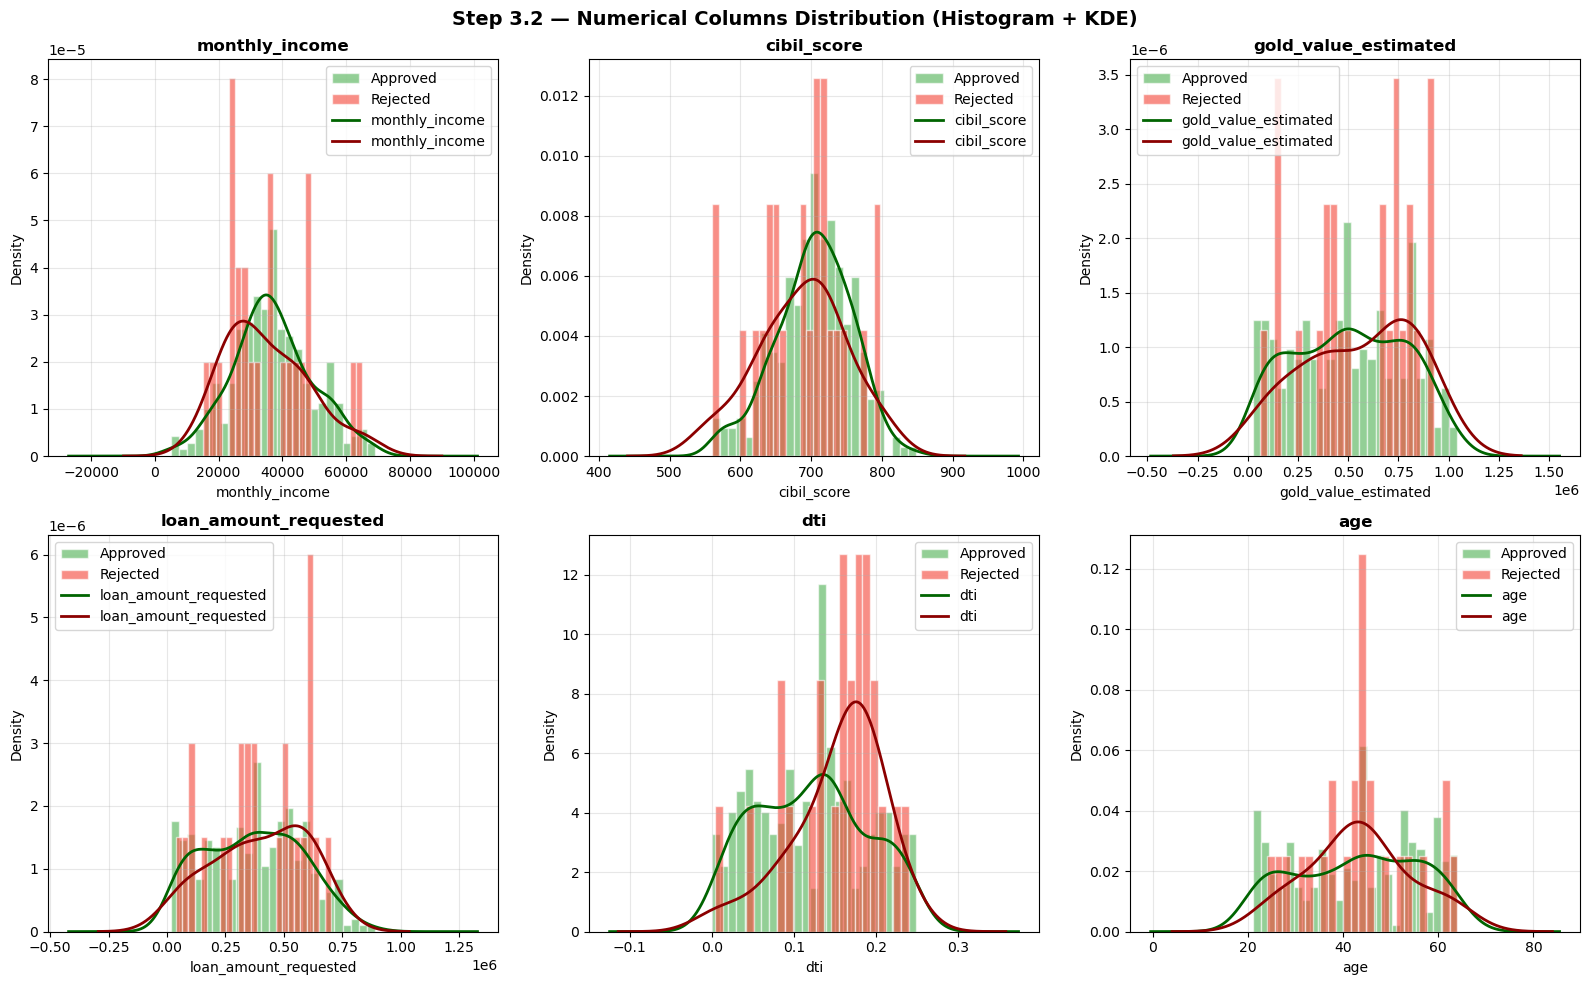

✅ Green = Approved | Red = Rejected
   Overlap kam ho → feature zyada useful hai model ke liye


In [22]:
num_cols = ['monthly_income', 'cibil_score', 'gold_value_estimated',
            'loan_amount_requested', 'dti', 'age']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Step 3.2 — Numerical Columns Distribution (Histogram + KDE)',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), num_cols):
    # approved aur rejected alag alag dikhao
    approved = df[df['loan_status'] == 1][col]
    rejected = df[df['loan_status'] == 0][col]

    ax.hist(approved, bins=25, alpha=0.6, color='#4CAF50',
            label='Approved', edgecolor='white', density=True)
    ax.hist(rejected, bins=25, alpha=0.6, color='#F44336',
            label='Rejected', edgecolor='white', density=True)

    approved.plot(kind='kde', ax=ax, color='darkgreen', linewidth=2)
    rejected.plot(kind='kde', ax=ax, color='darkred',  linewidth=2)

    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Green = Approved | Red = Rejected")
print("   Overlap kam ho → feature zyada useful hai model ke liye")

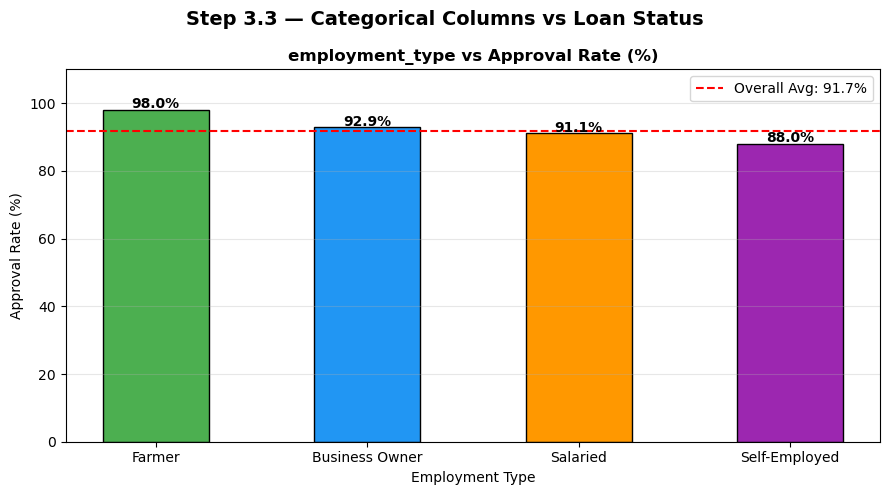

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Step 3.3 — Categorical Columns vs Loan Status',
             fontsize=14, fontweight='bold')

emp_approval = df.groupby('employment_type')['loan_status'].mean() * 100
emp_counts   = df.groupby('employment_type')['loan_status'].count()
emp_approval = emp_approval.sort_values(ascending=False)

bars = ax.bar(emp_approval.index, emp_approval.values,
              color=['#4CAF50','#2196F3','#FF9800','#9C27B0'],
              edgecolor='black', width=0.5)

for bar, val in zip(bars, emp_approval.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')

ax.set_title('employment_type vs Approval Rate (%)', fontweight='bold')
ax.set_xlabel('Employment Type')
ax.set_ylabel('Approval Rate (%)')
ax.set_ylim(0, 110)
ax.axhline(y=df['loan_status'].mean()*100, color='red',
           linestyle='--', label=f'Overall Avg: {df["loan_status"].mean()*100:.1f}%')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

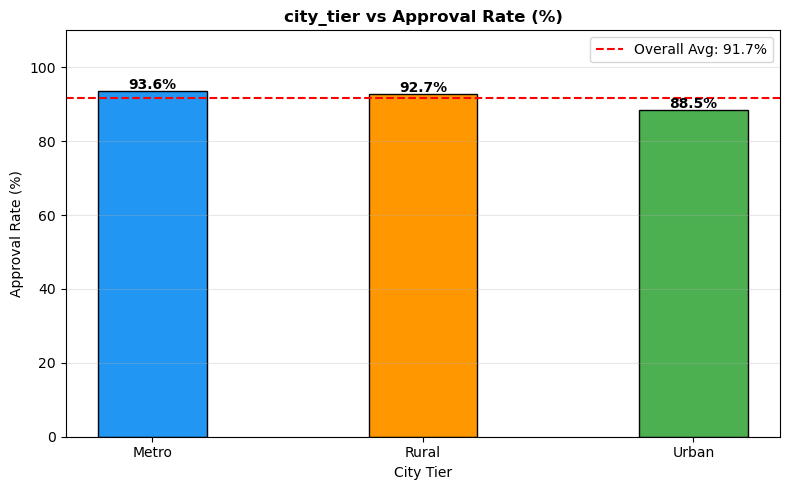

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

city_approval = df.groupby('city_tier')['loan_status'].mean() * 100
city_approval = city_approval.sort_values(ascending=False)

bars = ax.bar(city_approval.index, city_approval.values,
              color=['#2196F3', '#FF9800', '#4CAF50'],
              edgecolor='black', width=0.4)

for bar, val in zip(bars, city_approval.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')

ax.set_title('city_tier vs Approval Rate (%)', fontweight='bold')
ax.set_xlabel('City Tier')
ax.set_ylabel('Approval Rate (%)')
ax.set_ylim(0, 110)
ax.axhline(y=df['loan_status'].mean()*100, color='red',
           linestyle='--', label=f'Overall Avg: {df["loan_status"].mean()*100:.1f}%')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

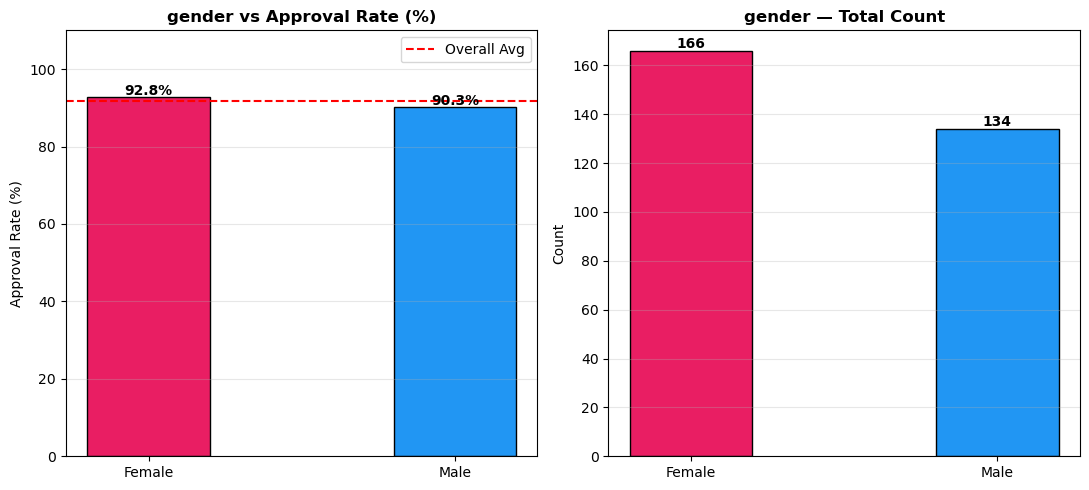

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

gender_approval = df.groupby('gender')['loan_status'].mean() * 100
gender_counts   = df.groupby('gender')['loan_status'].count()

# Bar chart
bars = axes[0].bar(gender_approval.index, gender_approval.values,
                   color=['#E91E63', '#2196F3'],
                   edgecolor='black', width=0.4)
for bar, val in zip(bars, gender_approval.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('gender vs Approval Rate (%)', fontweight='bold')
axes[0].set_ylabel('Approval Rate (%)')
axes[0].set_ylim(0, 110)
axes[0].axhline(y=df['loan_status'].mean()*100, color='red',
                linestyle='--', label='Overall Avg')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Count chart
axes[1].bar(gender_counts.index, gender_counts.values,
            color=['#E91E63', '#2196F3'], edgecolor='black', width=0.4)
for i, (idx, val) in enumerate(gender_counts.items()):
    axes[1].text(i, val + 1, str(val), ha='center', fontweight='bold')
axes[1].set_title('gender — Total Count', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

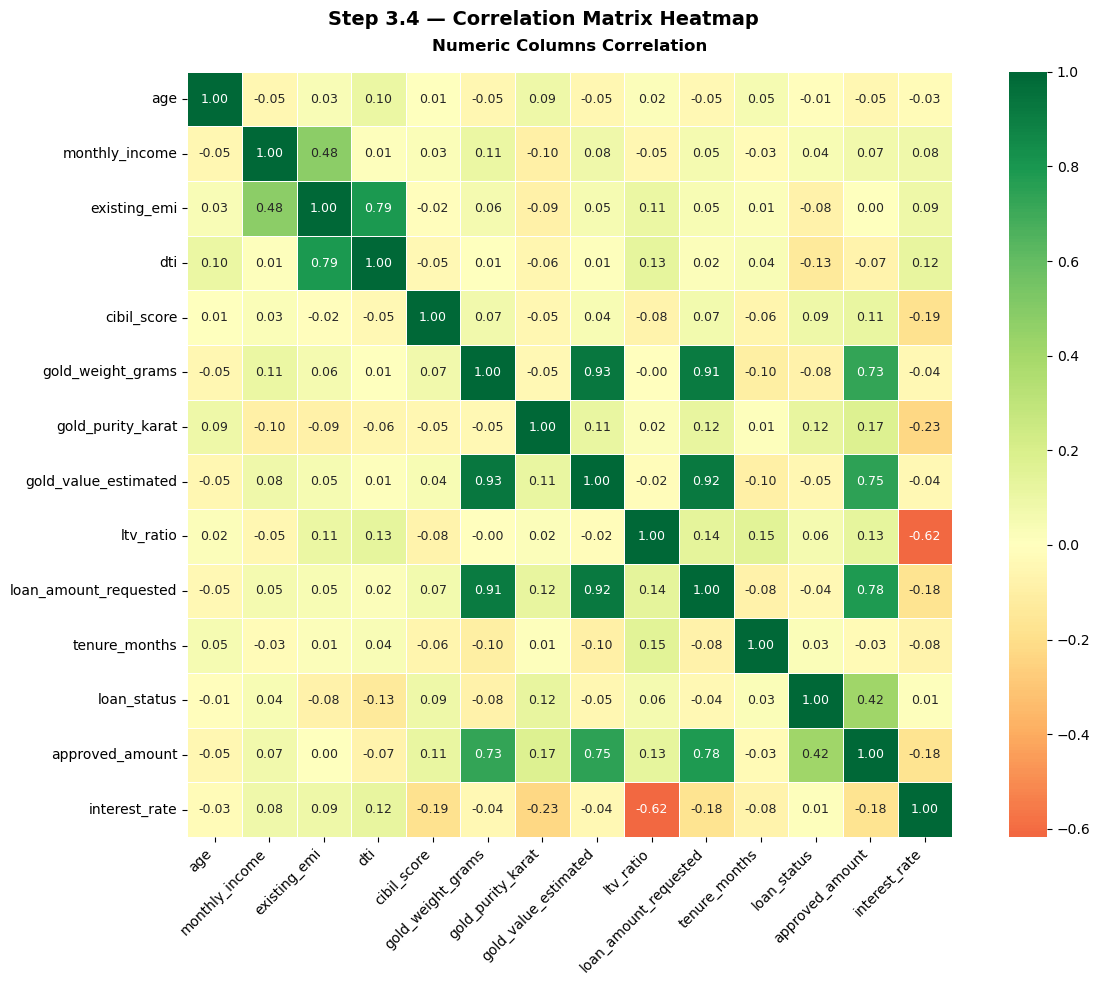

loan_status ke saath Correlation (sorted):

  approved_amount           :  0.4189  🔴 Strong
  dti                       : -0.1336  🟡 Moderate
  gold_purity_karat         :  0.1204  🟡 Moderate
  cibil_score               :  0.0873  ⚪ Weak
  existing_emi              : -0.0836  ⚪ Weak
  gold_weight_grams         : -0.0825  ⚪ Weak
  ltv_ratio                 :  0.0553  ⚪ Weak
  gold_value_estimated      : -0.0546  ⚪ Weak
  monthly_income            :  0.0422  ⚪ Weak
  loan_amount_requested     : -0.0408  ⚪ Weak
  tenure_months             :  0.0275  ⚪ Weak
  age                       : -0.0134  ⚪ Weak
  interest_rate             :  0.0132  ⚪ Weak


In [26]:
num_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = num_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle('Step 3.4 — Correlation Matrix Heatmap',
             fontsize=14, fontweight='bold')

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            linecolor='white',
            square=True,
            ax=ax,
            annot_kws={'size': 9})

ax.set_title('Numeric Columns Correlation', fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# loan_status ke saath correlation print karo
print("loan_status ke saath Correlation (sorted):\n")
corr_with_target = corr_matrix['loan_status'].drop('loan_status').sort_values(
                   key=abs, ascending=False)
for col, val in corr_with_target.items():
    flag = '🔴 Strong' if abs(val) > 0.3 else ('🟡 Moderate' if abs(val) > 0.1 else '⚪ Weak')
    print(f"  {col:<25} : {val:>7.4f}  {flag}")

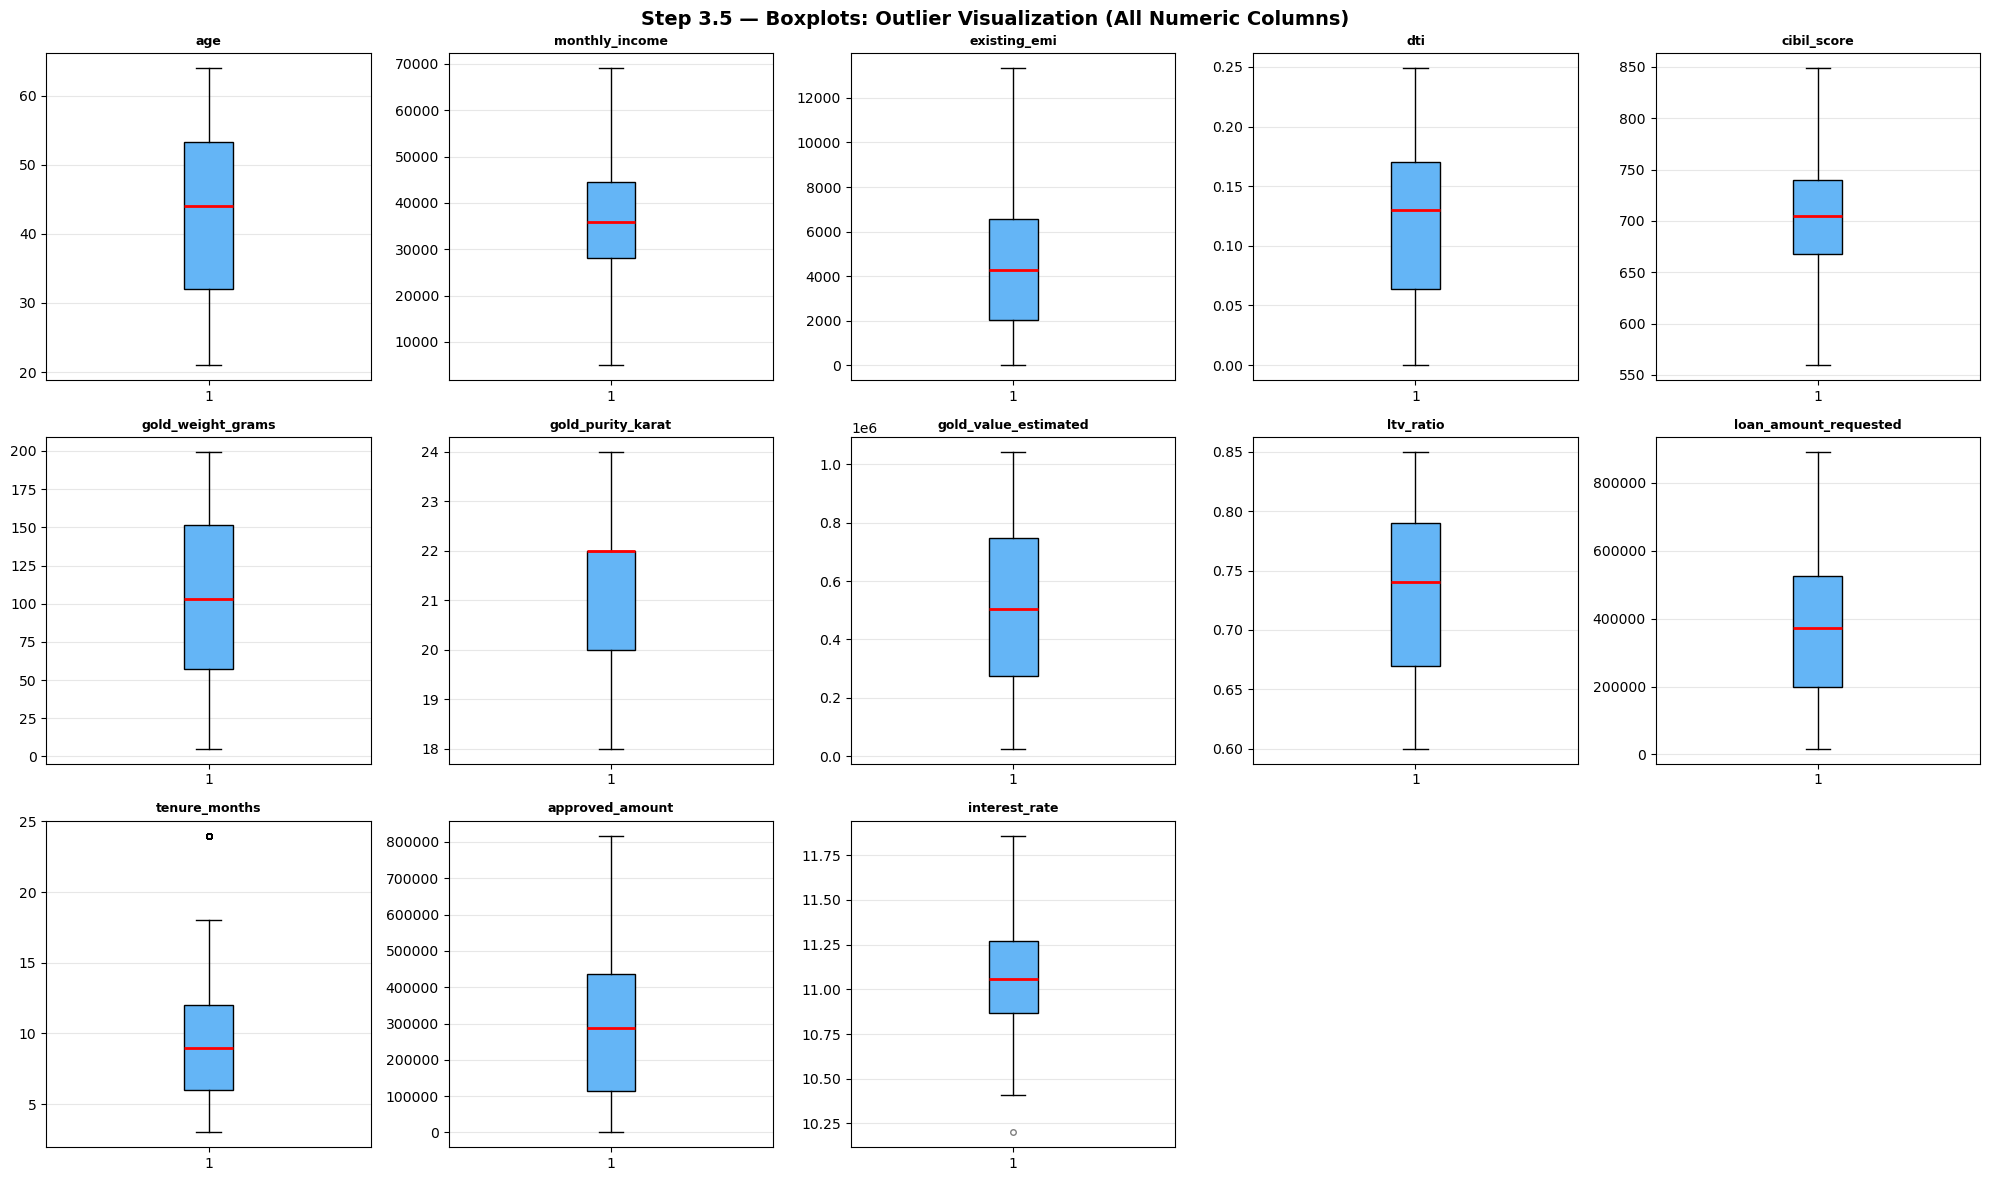

✅ Orange dots = Outliers | Red line = Median


In [27]:
num_cols_all = ['age', 'monthly_income', 'existing_emi', 'dti',
                'cibil_score', 'gold_weight_grams', 'gold_purity_karat',
                'gold_value_estimated', 'ltv_ratio',
                'loan_amount_requested', 'tenure_months',
                'approved_amount', 'interest_rate']

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Step 3.5 — Boxplots: Outlier Visualization (All Numeric Columns)',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), num_cols_all):
    ax.boxplot(df[col].dropna(),
               patch_artist=True,
               boxprops=dict(facecolor='#64B5F6', color='black'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', color='orange',
                               alpha=0.5, markersize=4))
    ax.set_title(col, fontweight='bold', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Extra axes hide karo
for ax in axes.flatten()[len(num_cols_all):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()
print("✅ Orange dots = Outliers | Red line = Median")

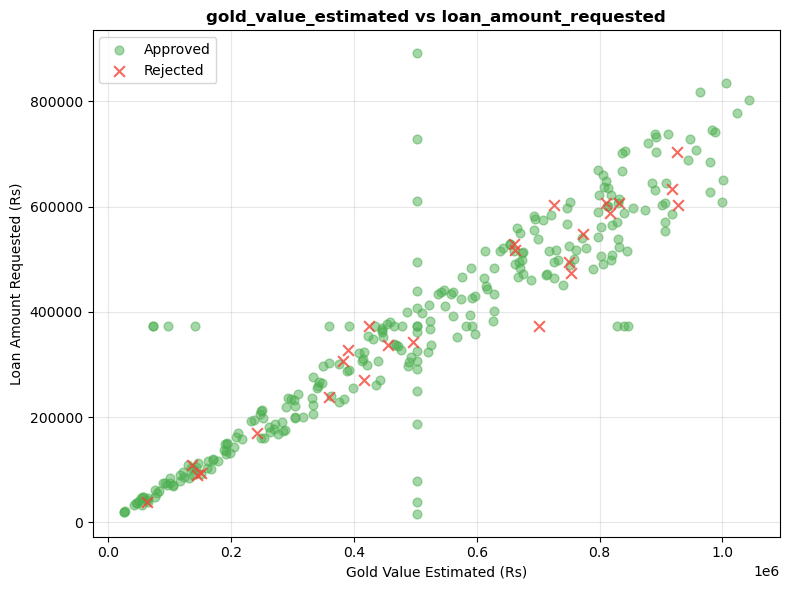

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

approved = df[df['loan_status'] == 1]
rejected = df[df['loan_status'] == 0]

ax.scatter(approved['gold_value_estimated'],
           approved['loan_amount_requested'],
           alpha=0.5, color='#4CAF50', label='Approved', s=40)
ax.scatter(rejected['gold_value_estimated'],
           rejected['loan_amount_requested'],
           alpha=0.8, color='#F44336', label='Rejected', s=60, marker='x')

ax.set_title('gold_value_estimated vs loan_amount_requested',
             fontweight='bold')
ax.set_xlabel('Gold Value Estimated (Rs)')
ax.set_ylabel('Loan Amount Requested (Rs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

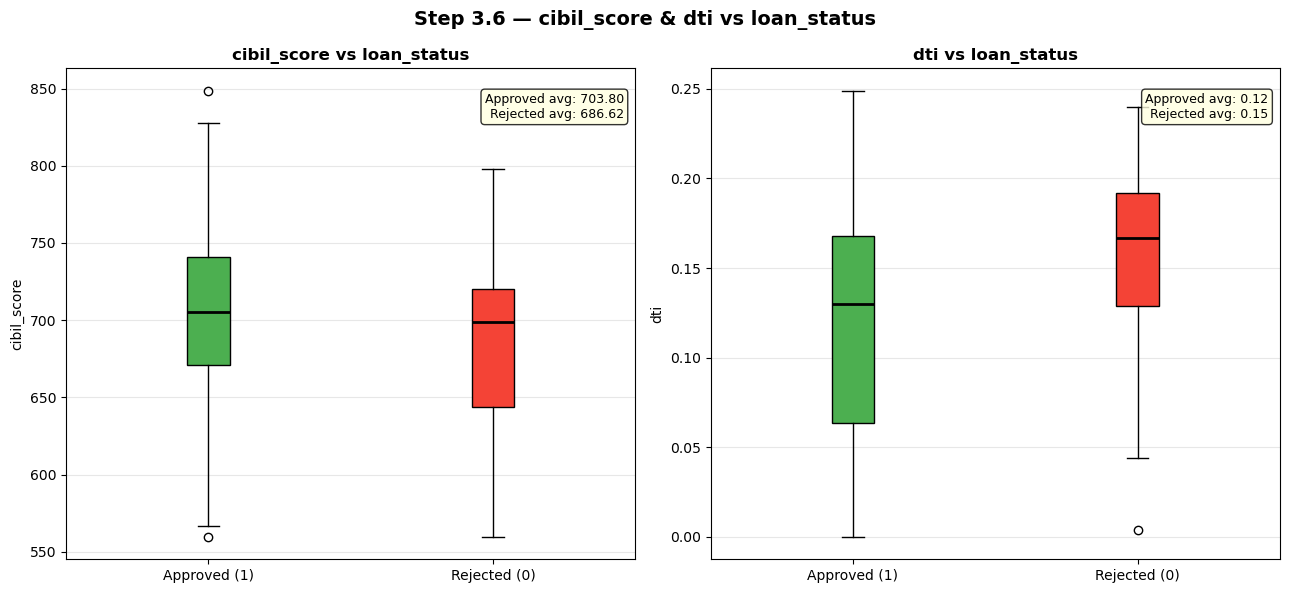

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Step 3.6 — cibil_score & dti vs loan_status',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes, ['cibil_score', 'dti']):
    data_approved = df[df['loan_status'] == 1][col]
    data_rejected = df[df['loan_status'] == 0][col]

    bp = ax.boxplot([data_approved, data_rejected],
                    labels=['Approved (1)', 'Rejected (0)'],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))

    bp['boxes'][0].set_facecolor('#4CAF50')
    bp['boxes'][1].set_facecolor('#F44336')

    ax.set_title(f'{col} vs loan_status', fontweight='bold')
    ax.set_ylabel(col)
    ax.grid(axis='y', alpha=0.3)

    avg_app = data_approved.mean()
    avg_rej = data_rejected.mean()
    ax.text(0.98, 0.95,
            f'Approved avg: {avg_app:.2f}\nRejected avg: {avg_rej:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
            fontsize=9)

plt.tight_layout()
plt.show()

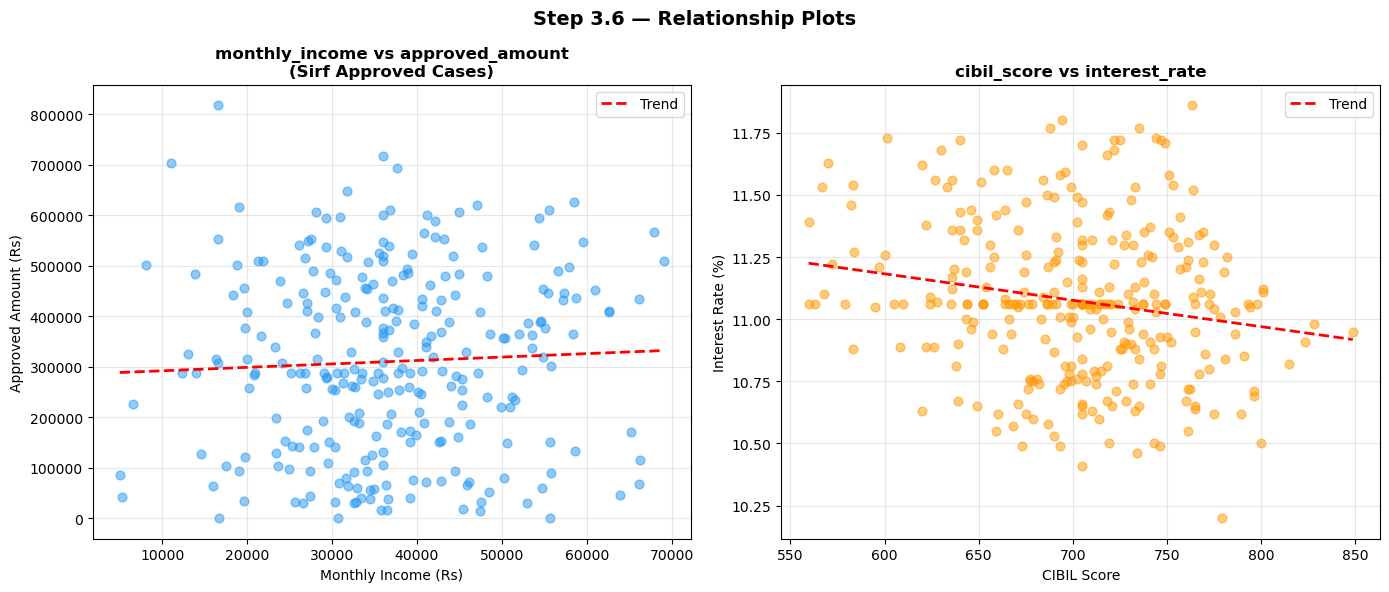

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Step 3.6 — Relationship Plots',
             fontsize=14, fontweight='bold')

# monthly_income vs approved_amount
approved_df = df[df['loan_status'] == 1]
axes[0].scatter(approved_df['monthly_income'],
                approved_df['approved_amount'],
                alpha=0.5, color='#2196F3', s=40)
axes[0].set_title('monthly_income vs approved_amount\n(Sirf Approved Cases)',
                  fontweight='bold')
axes[0].set_xlabel('Monthly Income (Rs)')
axes[0].set_ylabel('Approved Amount (Rs)')
axes[0].grid(alpha=0.3)

# Trend line
import numpy as np
x = approved_df['monthly_income']
y = approved_df['approved_amount']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
axes[0].plot(sorted(x), p(sorted(x)), color='red',
             linewidth=2, linestyle='--', label='Trend')
axes[0].legend()

# interest_rate vs cibil_score
interest_df = df[df['interest_rate'].notnull()]
axes[1].scatter(interest_df['cibil_score'],
                interest_df['interest_rate'],
                alpha=0.5, color='#FF9800', s=40)
axes[1].set_title('cibil_score vs interest_rate',
                  fontweight='bold')
axes[1].set_xlabel('CIBIL Score')
axes[1].set_ylabel('Interest Rate (%)')
axes[1].grid(alpha=0.3)

x2 = interest_df['cibil_score']
y2 = interest_df['interest_rate']
z2 = np.polyfit(x2, y2, 1)
p2 = np.poly1d(z2)
axes[1].plot(sorted(x2), p2(sorted(x2)), color='red',
             linewidth=2, linestyle='--', label='Trend')
axes[1].legend()

plt.tight_layout()
plt.show()

In [31]:
print("=" * 58)
print("  STEP 3.7 — KEY OBSERVATIONS FROM EDA")
print("=" * 58)

print("\n📌 Target Variable (loan_status):")
approved_pct = df['loan_status'].mean() * 100
print(f"   → {approved_pct:.1f}% Approved, {100-approved_pct:.1f}% Rejected")
print(f"   → Imbalanced dataset — Phase 8 mein SMOTE zaroori hai")

print("\n📌 CIBIL Score:")
avg_app_cibil = df[df['loan_status']==1]['cibil_score'].mean()
avg_rej_cibil = df[df['loan_status']==0]['cibil_score'].mean()
print(f"   → Approved avg CIBIL  : {avg_app_cibil:.1f}")
print(f"   → Rejected avg CIBIL  : {avg_rej_cibil:.1f}")
print(f"   → Higher CIBIL = Higher approval chance")

print("\n📌 DTI (Debt-to-Income Ratio):")
avg_app_dti = df[df['loan_status']==1]['dti'].mean()
avg_rej_dti = df[df['loan_status']==0]['dti'].mean()
print(f"   → Approved avg DTI    : {avg_app_dti:.4f}")
print(f"   → Rejected avg DTI    : {avg_rej_dti:.4f}")
print(f"   → Higher DTI = Higher rejection chance")

print("\n📌 Monthly Income:")
avg_app_inc = df[df['loan_status']==1]['monthly_income'].mean()
avg_rej_inc = df[df['loan_status']==0]['monthly_income'].mean()
print(f"   → Approved avg income : Rs {avg_app_inc:,.0f}")
print(f"   → Rejected avg income : Rs {avg_rej_inc:,.0f}")

print("\n📌 Employment Type:")
emp_rate = df.groupby('employment_type')['loan_status'].mean()*100
best_emp = emp_rate.idxmax()
worst_emp = emp_rate.idxmin()
print(f"   → Highest approval    : {best_emp}  ({emp_rate[best_emp]:.1f}%)")
print(f"   → Lowest approval     : {worst_emp} ({emp_rate[worst_emp]:.1f}%)")

print("\n📌 Interest Rate:")
print(f"   → Range: {df['interest_rate'].min()}% to {df['interest_rate'].max()}%")
print(f"   → Tight range (1.66%) — Regression R² naturally low rahega")

print("\n📌 Correlation with loan_status:")
num_df    = df.select_dtypes(include=['int64','float64'])
corr_vals = num_df.corr()['loan_status'].drop('loan_status')
top3      = corr_vals.abs().sort_values(ascending=False).head(3)
for col, val in top3.items():
    print(f"   → {col:<25} : {corr_vals[col]:+.4f}")

print()
print("   ➡️  Yeh observations Phase 12 (Final Report) mein use honge")
print("=" * 58)

  STEP 3.7 — KEY OBSERVATIONS FROM EDA

📌 Target Variable (loan_status):
   → 91.7% Approved, 8.3% Rejected
   → Imbalanced dataset — Phase 8 mein SMOTE zaroori hai

📌 CIBIL Score:
   → Approved avg CIBIL  : 703.8
   → Rejected avg CIBIL  : 686.6
   → Higher CIBIL = Higher approval chance

📌 DTI (Debt-to-Income Ratio):
   → Approved avg DTI    : 0.1209
   → Rejected avg DTI    : 0.1533
   → Higher DTI = Higher rejection chance

📌 Monthly Income:
   → Approved avg income : Rs 36,923
   → Rejected avg income : Rs 35,012

📌 Employment Type:
   → Highest approval    : Farmer  (98.0%)
   → Lowest approval     : Self-Employed (88.0%)

📌 Interest Rate:
   → Range: 10.2% to 11.86%
   → Tight range (1.66%) — Regression R² naturally low rahega

📌 Correlation with loan_status:
   → approved_amount           : +0.4189
   → dti                       : -0.1336
   → gold_purity_karat         : +0.1204

   ➡️  Yeh observations Phase 12 (Final Report) mein use honge


In [32]:
print("=" * 52)
print("✅  PHASE 3 — EDA — COMPLETE")
print("=" * 52)
print()
print("  Plots Banaye:")
print("  ✅ Step 3.1 — loan_status Bar + Pie chart")
print("  ✅ Step 3.2 — Histogram + KDE (6 columns)")
print("  ✅ Step 3.3 — Categorical vs Approval (3 charts)")
print("  ✅ Step 3.4 — Correlation Heatmap")
print("  ✅ Step 3.5 — Boxplots (all numeric columns)")
print("  ✅ Step 3.6 — Relationship Scatter/Box plots")
print("  ✅ Step 3.7 — Key Observations noted")
print()
print("  ➡️  Agla Step : PHASE 4 — Feature Engineering")
print("=" * 52)

✅  PHASE 3 — EDA — COMPLETE

  Plots Banaye:
  ✅ Step 3.1 — loan_status Bar + Pie chart
  ✅ Step 3.2 — Histogram + KDE (6 columns)
  ✅ Step 3.3 — Categorical vs Approval (3 charts)
  ✅ Step 3.4 — Correlation Heatmap
  ✅ Step 3.5 — Boxplots (all numeric columns)
  ✅ Step 3.6 — Relationship Scatter/Box plots
  ✅ Step 3.7 — Key Observations noted

  ➡️  Agla Step : PHASE 4 — Feature Engineering


**FEATURES**

In [33]:
print("Dataset shape before feature creation:", df.shape)
print()

# --- Feature 1 ---
df['gold_utilization'] = df['loan_amount_requested'] / df['gold_value_estimated']
print("✅ gold_utilization = loan_amount_requested / gold_value_estimated")
print(f"   Matlab  : Kitna % gold value ka loan maanga")
print(f"   Range   : {df['gold_utilization'].min():.4f} to {df['gold_utilization'].max():.4f}")
print()

# --- Feature 2 ---
df['emi_burden'] = df['existing_emi'] / df['monthly_income']
print("✅ emi_burden = existing_emi / monthly_income")
print(f"   Matlab  : Income ka kitna % pehle se EMI mein ja raha hai")
print(f"   Range   : {df['emi_burden'].min():.4f} to {df['emi_burden'].max():.4f}")
print()

# --- Feature 3 ---
df['loan_per_gram'] = df['loan_amount_requested'] / df['gold_weight_grams']
print("✅ loan_per_gram = loan_amount_requested / gold_weight_grams")
print(f"   Matlab  : Har gram sone par kitna loan maanga")
print(f"   Range   : Rs {df['loan_per_gram'].min():.2f} to Rs {df['loan_per_gram'].max():.2f}")
print()

# --- Feature 4 ---
df['net_income'] = df['monthly_income'] - df['existing_emi']
print("✅ net_income = monthly_income - existing_emi")
print(f"   Matlab  : EMI katne ke baad actual free income")
print(f"   Range   : Rs {df['net_income'].min():.2f} to Rs {df['net_income'].max():.2f}")
print()

print("Dataset shape after feature creation:", df.shape)

Dataset shape before feature creation: (300, 17)

✅ gold_utilization = loan_amount_requested / gold_value_estimated
   Matlab  : Kitna % gold value ka loan maanga
   Range   : 0.0328 to 5.1421

✅ emi_burden = existing_emi / monthly_income
   Matlab  : Income ka kitna % pehle se EMI mein ja raha hai
   Range   : 0.0003 to 0.3894

✅ loan_per_gram = loan_amount_requested / gold_weight_grams
   Matlab  : Har gram sone par kitna loan maanga
   Range   : Rs 322.43 to Rs 25453.04

✅ net_income = monthly_income - existing_emi
   Matlab  : EMI katne ke baad actual free income
   Range   : Rs 4157.00 to Rs 66969.88

Dataset shape after feature creation: (300, 21)


In [34]:
new_features = ['gold_utilization', 'emi_burden', 'loan_per_gram', 'net_income']

print("Nayi Features — Sample Values (pehli 5 rows):\n")
print(df[new_features].head().round(4).to_string())
print()
print("Basic Stats:\n")
print(df[new_features].describe().round(4).to_string())

Nayi Features — Sample Values (pehli 5 rows):

   gold_utilization  emi_burden  loan_per_gram  net_income
0              0.78      0.1630      3932.5003     11670.0
1              0.76      0.0780      3831.6810     30898.0
2              0.80      0.0998      4033.3289     18200.0
3              0.79      0.2145      3258.7523     28862.0
4              0.61      0.0022      3075.4176     37747.0

Basic Stats:

       gold_utilization  emi_burden  loan_per_gram  net_income
count          300.0000    300.0000       300.0000    300.0000
mean             0.7736      0.1251      3794.2598  32196.8529
std              0.4325      0.0697      2048.0931  11401.6007
min              0.0328      0.0003       322.4252   4157.0000
25%              0.6600      0.0657      3247.2942  25352.2500
50%              0.7350      0.1267      3620.8510  31421.0000
75%              0.8000      0.1786      4033.3333  38249.7500
max              5.1421      0.3894     25453.0375  66969.8750


In [35]:
import numpy as np

print("Nayi Features — Null aur Infinity Check:\n")
print(f"{'Feature':<20} {'Nulls':>8} {'Inf Values':>12} {'Status':>10}")
print("-" * 55)

for col in new_features:
    null_count = df[col].isnull().sum()
    inf_count  = np.isinf(df[col]).sum()
    status     = "✅ Clean" if (null_count == 0 and inf_count == 0) else "⚠️ Issue"
    print(f"{col:<20} {null_count:>8} {inf_count:>12} {status:>10}")

print()

# Agar koi inf ho toh replace karo
for col in new_features:
    if np.isinf(df[col]).sum() > 0:
        median_val = df[col].replace([np.inf, -np.inf], np.nan).median()
        df[col]    = df[col].replace([np.inf, -np.inf], median_val)
        print(f"  ⚠️  {col} mein inf tha — median se replace kiya: {median_val:.4f}")

print("✅ Null/Inf check complete")

Nayi Features — Null aur Infinity Check:

Feature                 Nulls   Inf Values     Status
-------------------------------------------------------
gold_utilization            0            0    ✅ Clean
emi_burden                  0            0    ✅ Clean
loan_per_gram               0            0    ✅ Clean
net_income                  0            0    ✅ Clean

✅ Null/Inf check complete


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

targets = ['loan_status', 'approved_amount', 'interest_rate']
all_new  = new_features

print("Nayi Features ki Target Variables se Correlation:\n")
print(f"{'Feature':<22}", end="")
for t in targets:
    print(f"{t:>18}", end="")
print()
print("-" * 76)

for feat in all_new:
    print(f"{feat:<22}", end="")
    for t in targets:
        corr_val = df[feat].corr(df[t])
        flag     = " 🔴" if abs(corr_val) > 0.3 else (" 🟡" if abs(corr_val) > 0.1 else " ⚪")
        print(f"{corr_val:>15.4f}{flag}", end="")
    print()

print()
print("Legend: 🔴 Strong (>0.3)  🟡 Moderate (>0.1)  ⚪ Weak (<0.1)")

Nayi Features ki Target Variables se Correlation:

Feature                      loan_status   approved_amount     interest_rate
----------------------------------------------------------------------------
gold_utilization               0.0414 ⚪        -0.0182 ⚪        -0.0806 ⚪
emi_burden                    -0.1133 🟡        -0.0120 ⚪         0.0696 ⚪
loan_per_gram                  0.0632 ⚪        -0.0163 ⚪        -0.0957 ⚪
net_income                     0.0687 ⚪         0.0780 ⚪         0.0624 ⚪

Legend: 🔴 Strong (>0.3)  🟡 Moderate (>0.1)  ⚪ Weak (<0.1)


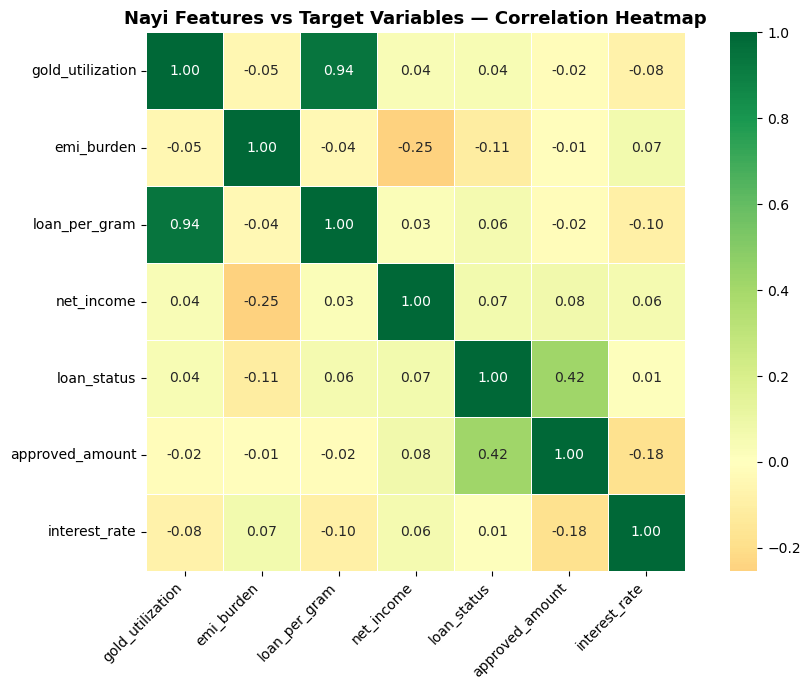

In [37]:
cols_to_check = new_features + ['loan_status', 'approved_amount', 'interest_rate']
corr_new      = df[cols_to_check].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_new,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            linecolor='white',
            square=True,
            ax=ax,
            annot_kws={'size': 10})

ax.set_title('Nayi Features vs Target Variables — Correlation Heatmap',
             fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

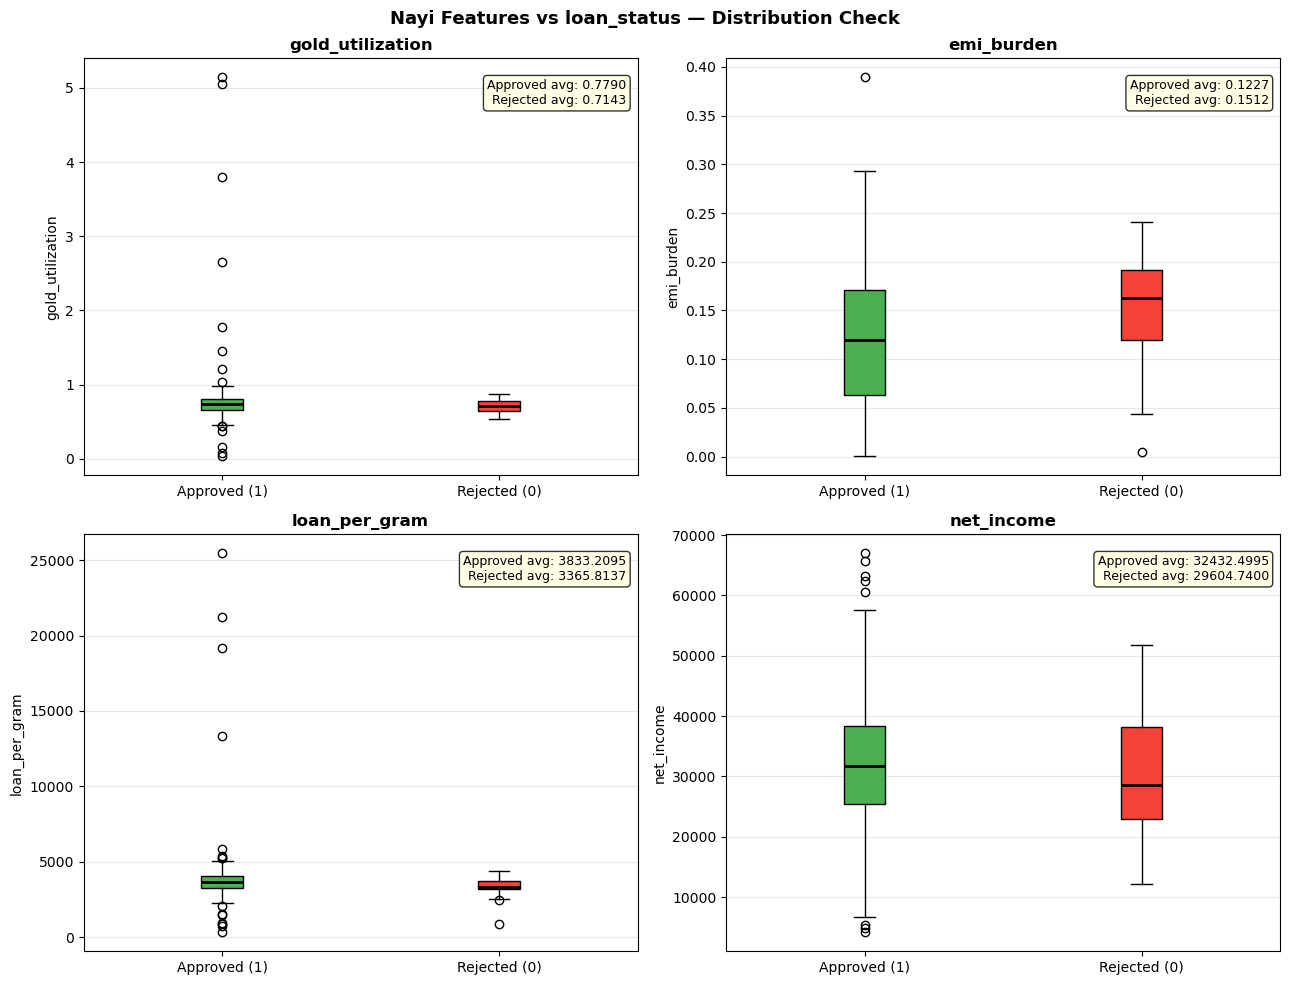

✅ Approved avg vs Rejected avg ka fark dikhta hai toh feature useful hai


In [38]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Nayi Features vs loan_status — Distribution Check',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), new_features):
    approved_vals = df[df['loan_status'] == 1][col]
    rejected_vals = df[df['loan_status'] == 0][col]

    bp = ax.boxplot([approved_vals, rejected_vals],
                    labels=['Approved (1)', 'Rejected (0)'],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))

    bp['boxes'][0].set_facecolor('#4CAF50')
    bp['boxes'][1].set_facecolor('#F44336')

    avg_app = approved_vals.mean()
    avg_rej = rejected_vals.mean()

    ax.set_title(col, fontweight='bold')
    ax.set_ylabel(col)
    ax.grid(axis='y', alpha=0.3)
    ax.text(0.98, 0.95,
            f'Approved avg: {avg_app:.4f}\nRejected avg: {avg_rej:.4f}',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
            fontsize=9)

plt.tight_layout()
plt.show()
print("✅ Approved avg vs Rejected avg ka fark dikhta hai toh feature useful hai")

In [39]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr().abs()

print("Highly Correlated Feature Pairs (correlation > 0.85):\n")
print(f"{'Feature 1':<25} {'Feature 2':<25} {'Correlation':>12}")
print("-" * 65)

high_corr_pairs = []
cols = corr_matrix.columns.tolist()

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        corr_val = corr_matrix.iloc[i, j]
        if corr_val > 0.85:
            high_corr_pairs.append((cols[i], cols[j], corr_val))
            print(f"{cols[i]:<25} {cols[j]:<25} {corr_val:>12.4f}  ⚠️")

if not high_corr_pairs:
    print("  ✅ Koi bhi feature pair 0.85 se zyada correlated nahi")
    print("     Multicollinearity ka issue nahi hai")

print()
print(f"Total high-corr pairs found: {len(high_corr_pairs)}")

Highly Correlated Feature Pairs (correlation > 0.85):

Feature 1                 Feature 2                  Correlation
-----------------------------------------------------------------
monthly_income            net_income                      0.9724  ⚠️
dti                       emi_burden                      0.8909  ⚠️
gold_weight_grams         gold_value_estimated            0.9302  ⚠️
gold_weight_grams         loan_amount_requested           0.9122  ⚠️
gold_value_estimated      loan_amount_requested           0.9233  ⚠️
gold_utilization          loan_per_gram                   0.9411  ⚠️

Total high-corr pairs found: 6


In [40]:
print("Har Feature ki loan_status se Correlation (absolute value):\n")
print(f"{'Feature':<25} {'Corr with loan_status':>22} {'Decision':>15}")
print("-" * 65)

corr_with_target = numeric_df.corr()['loan_status'].drop('loan_status').abs()
corr_with_target = corr_with_target.sort_values(ascending=False)

to_drop_candidates = []

for col, val in corr_with_target.items():
    if val < 0.02:
        decision = "⚠️ Drop consider karo"
        to_drop_candidates.append(col)
    elif val < 0.05:
        decision = "🟡 Weak — monitor karo"
    else:
        decision = "✅ Rakhna hai"
    print(f"{col:<25} {val:>22.4f} {decision:>15}")

print()
if to_drop_candidates:
    print(f"Drop candidates: {to_drop_candidates}")
else:
    print("✅ Koi bhi feature itna weak nahi ki drop karna pade")

Har Feature ki loan_status se Correlation (absolute value):

Feature                    Corr with loan_status        Decision
-----------------------------------------------------------------
approved_amount                           0.4189    ✅ Rakhna hai
dti                                       0.1336    ✅ Rakhna hai
gold_purity_karat                         0.1204    ✅ Rakhna hai
emi_burden                                0.1133    ✅ Rakhna hai
cibil_score                               0.0873    ✅ Rakhna hai
existing_emi                              0.0836    ✅ Rakhna hai
gold_weight_grams                         0.0825    ✅ Rakhna hai
net_income                                0.0687    ✅ Rakhna hai
loan_per_gram                             0.0632    ✅ Rakhna hai
ltv_ratio                                 0.0553    ✅ Rakhna hai
gold_value_estimated                      0.0546    ✅ Rakhna hai
monthly_income                            0.0422 🟡 Weak — monitor karo
gold_utilization      

In [41]:
# Target columns — inhe drop nahi karna
target_cols = ['loan_status', 'approved_amount', 'interest_rate']

# Jo columns drop karni hain (corr < 0.02 ya multicollinear)
# Upar ke analysis ke basis par decide karo
# Agar to_drop_candidates empty hai toh kuch drop nahi
cols_to_drop = [col for col in to_drop_candidates if col not in target_cols]

print("Drop Decision:\n")
if cols_to_drop:
    print(f"  Dropping: {cols_to_drop}")
    df = df.drop(columns=cols_to_drop)
    print(f"  ✅ {len(cols_to_drop)} columns drop kiye")
else:
    print("  ✅ Koi column drop nahi kiya")
    print("     Reason: Sab features meaningful correlation rakhte hain")

print()
print(f"Final Dataset Shape : {df.shape}")
print(f"Final Columns ({df.shape[1]}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

Drop Decision:

  Dropping: ['age']
  ✅ 1 columns drop kiye

Final Dataset Shape : (300, 20)
Final Columns (20):
   1. gender
   2. city_tier
   3. employment_type
   4. monthly_income
   5. existing_emi
   6. dti
   7. cibil_score
   8. gold_weight_grams
   9. gold_purity_karat
  10. gold_value_estimated
  11. ltv_ratio
  12. loan_amount_requested
  13. tenure_months
  14. loan_status
  15. approved_amount
  16. interest_rate
  17. gold_utilization
  18. emi_burden
  19. loan_per_gram
  20. net_income


In [42]:
print("=" * 55)
print("✅  PHASE 4 — FEATURE ENGINEERING — COMPLETE")
print("=" * 55)
print()
print("  Step 4.1 — Nayi Features Banayi:")
print("  ✅ gold_utilization  = loan_amount / gold_value")
print("  ✅ emi_burden        = existing_emi / monthly_income")
print("  ✅ loan_per_gram     = loan_amount / gold_weight")
print("  ✅ net_income        = monthly_income - existing_emi")
print()
print("  Step 4.2 — Correlation Check:")
print("  ✅ Nayi features ka target se correlation dekha")
print("  ✅ Heatmap se visualize kiya")
print("  ✅ Boxplot se distribution check kiya")
print()
print("  Step 4.3 — Drop Decision:")
print("  ✅ Multicollinearity check kiya (threshold 0.85)")
print("  ✅ Low correlation features identify kiye")
print("  ✅ Final clean dataset ready")
print()
print(f"  Final Shape : {df.shape[0]} rows x {df.shape[1]} columns")
print()
print("  ❌ Encoding  — Phase 7 mein hoga")
print("  ❌ Scaling   — Phase 7 mein hoga")
print("  ❌ X, y split — Phase 6 mein hoga")
print()
print("  ➡️  Agla Step : PHASE 5 — Datasets Prepare karo")
print("=" * 55)

✅  PHASE 4 — FEATURE ENGINEERING — COMPLETE

  Step 4.1 — Nayi Features Banayi:
  ✅ gold_utilization  = loan_amount / gold_value
  ✅ emi_burden        = existing_emi / monthly_income
  ✅ loan_per_gram     = loan_amount / gold_weight
  ✅ net_income        = monthly_income - existing_emi

  Step 4.2 — Correlation Check:
  ✅ Nayi features ka target se correlation dekha
  ✅ Heatmap se visualize kiya
  ✅ Boxplot se distribution check kiya

  Step 4.3 — Drop Decision:
  ✅ Multicollinearity check kiya (threshold 0.85)
  ✅ Low correlation features identify kiye
  ✅ Final clean dataset ready

  Final Shape : 300 rows x 20 columns

  ❌ Encoding  — Phase 7 mein hoga
  ❌ Scaling   — Phase 7 mein hoga
  ❌ X, y split — Phase 6 mein hoga

  ➡️  Agla Step : PHASE 5 — Datasets Prepare karo


In [43]:
print("Current Dataset Status:\n")
print(f"  Shape         : {df.shape}")
print(f"  Total Columns : {df.shape[1]}")
print()
print("  Columns list:")
for i, col in enumerate(df.columns, 1):
    print(f"    {i:2}. {col}")
print()
print("  Target columns jo hain dataset mein:")
for t in ['loan_status', 'approved_amount', 'interest_rate']:
    print(f"    ✅ {t} — present hai")

Current Dataset Status:

  Shape         : (300, 20)
  Total Columns : 20

  Columns list:
     1. gender
     2. city_tier
     3. employment_type
     4. monthly_income
     5. existing_emi
     6. dti
     7. cibil_score
     8. gold_weight_grams
     9. gold_purity_karat
    10. gold_value_estimated
    11. ltv_ratio
    12. loan_amount_requested
    13. tenure_months
    14. loan_status
    15. approved_amount
    16. interest_rate
    17. gold_utilization
    18. emi_burden
    19. loan_per_gram
    20. net_income

  Target columns jo hain dataset mein:
    ✅ loan_status — present hai
    ✅ approved_amount — present hai
    ✅ interest_rate — present hai


In [44]:
# Teeno target columns define karo
target_cols = ['loan_status', 'approved_amount', 'interest_rate']

# X — teeno targets chhod ke sab features
# y — loan_status
X_clf = df.drop(columns=target_cols)
y_clf = df['loan_status']

print("=" * 52)
print("  DATASET A — Classification")
print("=" * 52)
print(f"  Total rows used : {X_clf.shape[0]}  (Poore 300 rows)")
print(f"  X shape         : {X_clf.shape}")
print(f"  y shape         : {y_clf.shape}")
print(f"  y target        : loan_status")
print()
print("  y distribution:")
print(f"    Approved (1) : {(y_clf==1).sum()}  "
      f"({(y_clf==1).mean()*100:.1f}%)")
print(f"    Rejected (0) : {(y_clf==0).sum()}  "
      f"({(y_clf==0).mean()*100:.1f}%)")
print()
print(f"  Features ({X_clf.shape[1]}) in X:")
for col in X_clf.columns:
    print(f"    → {col}")
print()
print("  ⚠️  Class imbalance hai")
print("      Phase 8 mein SMOTE se handle karenge")

  DATASET A — Classification
  Total rows used : 300  (Poore 300 rows)
  X shape         : (300, 17)
  y shape         : (300,)
  y target        : loan_status

  y distribution:
    Approved (1) : 275  (91.7%)
    Rejected (0) : 25  (8.3%)

  Features (17) in X:
    → gender
    → city_tier
    → employment_type
    → monthly_income
    → existing_emi
    → dti
    → cibil_score
    → gold_weight_grams
    → gold_purity_karat
    → gold_value_estimated
    → ltv_ratio
    → loan_amount_requested
    → tenure_months
    → gold_utilization
    → emi_burden
    → loan_per_gram
    → net_income

  ⚠️  Class imbalance hai
      Phase 8 mein SMOTE se handle karenge


In [45]:
# Sirf approved rows lo
df_approved = df[df['loan_status'] == 1].copy()

print(f"  Approved rows   : {len(df_approved)}")
print(f"  Rejected rows   : {len(df) - len(df_approved)} "
      f"(drop kiye — unka amount 0 hai)")
print()

# loan_status bhi drop karo warna TARGET LEAKAGE
X_reg1 = df_approved.drop(columns=target_cols)
y_reg1 = df_approved['approved_amount']

print("=" * 52)
print("  DATASET B — Regression 1 (Approved Amount)")
print("=" * 52)
print(f"  Total rows used : {X_reg1.shape[0]}  "
      f"(sirf approved rows)")
print(f"  X shape         : {X_reg1.shape}")
print(f"  y shape         : {y_reg1.shape}")
print(f"  y target        : approved_amount")
print()
print("  y stats:")
print(f"    Min   : Rs {y_reg1.min():>12,.0f}")
print(f"    Max   : Rs {y_reg1.max():>12,.0f}")
print(f"    Mean  : Rs {y_reg1.mean():>12,.0f}")
print(f"    Std   : Rs {y_reg1.std():>12,.0f}")
print()
print("  ✅ loan_status drop kiya X se")
print("  ✅ approved_amount drop kiya X se")
print("  ✅ interest_rate drop kiya X se")
print()
print("  ⚠️  TARGET LEAKAGE kaise hota:")
print("      loan_status sirf approved rows mein = 1")
print("      Constant column ban jaata")
print("      Model isko memorize karta — real pattern nahi seekhta")
print()
print(f"  Features ({X_reg1.shape[1]}) in X:")
for col in X_reg1.columns:
    print(f"    → {col}")

  Approved rows   : 275
  Rejected rows   : 25 (drop kiye — unka amount 0 hai)

  DATASET B — Regression 1 (Approved Amount)
  Total rows used : 275  (sirf approved rows)
  X shape         : (275, 17)
  y shape         : (275,)
  y target        : approved_amount

  y stats:
    Min   : Rs            0
    Max   : Rs      817,750
    Mean  : Rs      310,143
    Std   : Rs      178,543

  ✅ loan_status drop kiya X se
  ✅ approved_amount drop kiya X se
  ✅ interest_rate drop kiya X se

  ⚠️  TARGET LEAKAGE kaise hota:
      loan_status sirf approved rows mein = 1
      Constant column ban jaata
      Model isko memorize karta — real pattern nahi seekhta

  Features (17) in X:
    → gender
    → city_tier
    → employment_type
    → monthly_income
    → existing_emi
    → dti
    → cibil_score
    → gold_weight_grams
    → gold_purity_karat
    → gold_value_estimated
    → ltv_ratio
    → loan_amount_requested
    → tenure_months
    → gold_utilization
    → emi_burden
    → loan_per_gram

In [46]:
# Sirf non-null interest_rate rows lo
df_interest = df[df['interest_rate'].notnull()].copy()

print(f"  Non-null interest_rate rows : {len(df_interest)}")
print(f"  NULL interest_rate rows     : {df['interest_rate'].isnull().sum()} "
      f"(rejected cases — drop kiye)")
print()

# loan_status bhi drop karo warna TARGET LEAKAGE
X_reg2 = df_interest.drop(columns=target_cols)
y_reg2 = df_interest['interest_rate']

print("=" * 52)
print("  DATASET C — Regression 2 (Interest Rate)")
print("=" * 52)
print(f"  Total rows used : {X_reg2.shape[0]}  "
      f"(sirf non-null rows)")
print(f"  X shape         : {X_reg2.shape}")
print(f"  y shape         : {y_reg2.shape}")
print(f"  y target        : interest_rate")
print()
print("  y stats:")
print(f"    Min   : {y_reg2.min():.2f}%")
print(f"    Max   : {y_reg2.max():.2f}%")
print(f"    Mean  : {y_reg2.mean():.4f}%")
print(f"    Range : {y_reg2.max() - y_reg2.min():.2f}%  ← bahut tight!")
print()
print("  ✅ loan_status drop kiya X se")
print("  ✅ approved_amount drop kiya X se")
print("  ✅ interest_rate drop kiya X se")
print()
print("  ⚠️  Range sirf 1.66% hai")
print("      R² naturally low aayega — acceptable hai")
print("      MAE ko zyada importance dena is problem mein")
print()
print(f"  Features ({X_reg2.shape[1]}) in X:")
for col in X_reg2.columns:
    print(f"    → {col}")

  Non-null interest_rate rows : 300
  NULL interest_rate rows     : 0 (rejected cases — drop kiye)

  DATASET C — Regression 2 (Interest Rate)
  Total rows used : 300  (sirf non-null rows)
  X shape         : (300, 17)
  y shape         : (300,)
  y target        : interest_rate

  y stats:
    Min   : 10.20%
    Max   : 11.86%
    Mean  : 11.0736%
    Range : 1.66%  ← bahut tight!

  ✅ loan_status drop kiya X se
  ✅ approved_amount drop kiya X se
  ✅ interest_rate drop kiya X se

  ⚠️  Range sirf 1.66% hai
      R² naturally low aayega — acceptable hai
      MAE ko zyada importance dena is problem mein

  Features (17) in X:
    → gender
    → city_tier
    → employment_type
    → monthly_income
    → existing_emi
    → dti
    → cibil_score
    → gold_weight_grams
    → gold_purity_karat
    → gold_value_estimated
    → ltv_ratio
    → loan_amount_requested
    → tenure_months
    → gold_utilization
    → emi_burden
    → loan_per_gram
    → net_income


In [47]:
# Clustering ke liye numeric features select karo
cluster_cols = ['age', 'monthly_income', 'cibil_score', 'dti',
                'gold_value_estimated', 'loan_amount_requested',
                'ltv_ratio', 'net_income', 'emi_burden',
                'gold_utilization', 'loan_per_gram']

# Check karo ye columns df mein hain
missing_cols = [c for c in cluster_cols if c not in df.columns]
if missing_cols:
    print(f"⚠️  Ye columns nahi mile: {missing_cols}")
    cluster_cols = [c for c in cluster_cols if c in df.columns]

X_cluster = df[cluster_cols].copy()

print("=" * 52)
print("  DATASET D — Clustering (Unsupervised)")
print("=" * 52)
print(f"  Total rows used : {X_cluster.shape[0]}  (Poore 300 rows)")
print(f"  X shape         : {X_cluster.shape}")
print(f"  y               : Koi nahi — unsupervised hai")
print()
print("  Kyun sirf numeric features?")
print("    → KMeans distance calculate karta hai")
print("    → Categorical columns distance mein")
print("      directly use nahi ho sakti")
print()
print("  ⚠️  Train/Test Split NAHI hoga")
print("      Reason: Evaluate nahi karna")
print("              Sirf customer groups dhundne hain")
print()
print("  ⚠️  Scaling ZAROOR karni hai (Phase 7 mein)")
print("      income = Rs 36,000  vs  dti = 0.12")
print("      Bina scaling ke income dominate karegi")
print()
print(f"  Features ({len(cluster_cols)}):")
for col in cluster_cols:
    print(f"    → {col}")

⚠️  Ye columns nahi mile: ['age']
  DATASET D — Clustering (Unsupervised)
  Total rows used : 300  (Poore 300 rows)
  X shape         : (300, 10)
  y               : Koi nahi — unsupervised hai

  Kyun sirf numeric features?
    → KMeans distance calculate karta hai
    → Categorical columns distance mein
      directly use nahi ho sakti

  ⚠️  Train/Test Split NAHI hoga
      Reason: Evaluate nahi karna
              Sirf customer groups dhundne hain

  ⚠️  Scaling ZAROOR karni hai (Phase 7 mein)
      income = Rs 36,000  vs  dti = 0.12
      Bina scaling ke income dominate karegi

  Features (10):
    → monthly_income
    → cibil_score
    → dti
    → gold_value_estimated
    → loan_amount_requested
    → ltv_ratio
    → net_income
    → emi_burden
    → gold_utilization
    → loan_per_gram


In [48]:
import pandas as pd

summary = {
    'Dataset'  : ['A - Classification', 'B - Regression 1',
                  'C - Regression 2',   'D - Clustering'],
    'Rows'     : [X_clf.shape[0], X_reg1.shape[0],
                  X_reg2.shape[0], X_cluster.shape[0]],
    'Features' : [X_clf.shape[1], X_reg1.shape[1],
                  X_reg2.shape[1], X_cluster.shape[1]],
    'Target'   : ['loan_status', 'approved_amount',
                  'interest_rate', 'None'],
    'Type'     : ['Classification', 'Regression',
                  'Regression', 'Unsupervised'],
}

summary_df = pd.DataFrame(summary)
print("PHASE 5 — All Datasets Summary:\n")
print(summary_df.to_string(index=False))
print()
print("Leakage Check:")
print(f"  X_clf  mein loan_status    : "
      f"{'❌ AHA LEAKAGE' if 'loan_status' in X_clf.columns else '✅ Nahi hai'}")
print(f"  X_reg1 mein loan_status    : "
      f"{'❌ AHA LEAKAGE' if 'loan_status' in X_reg1.columns else '✅ Nahi hai'}")
print(f"  X_reg2 mein loan_status    : "
      f"{'❌ AHA LEAKAGE' if 'loan_status' in X_reg2.columns else '✅ Nahi hai'}")
print(f"  X_reg1 mein approved_amount: "
      f"{'❌ AHA LEAKAGE' if 'approved_amount' in X_reg1.columns else '✅ Nahi hai'}")
print(f"  X_reg2 mein interest_rate  : "
      f"{'❌ AHA LEAKAGE' if 'interest_rate' in X_reg2.columns else '✅ Nahi hai'}")

PHASE 5 — All Datasets Summary:

           Dataset  Rows  Features          Target           Type
A - Classification   300        17     loan_status Classification
  B - Regression 1   275        17 approved_amount     Regression
  C - Regression 2   300        17   interest_rate     Regression
    D - Clustering   300        10            None   Unsupervised

Leakage Check:
  X_clf  mein loan_status    : ✅ Nahi hai
  X_reg1 mein loan_status    : ✅ Nahi hai
  X_reg2 mein loan_status    : ✅ Nahi hai
  X_reg1 mein approved_amount: ✅ Nahi hai
  X_reg2 mein interest_rate  : ✅ Nahi hai


In [49]:
print("=" * 55)
print("✅  PHASE 5 — DATASETS PREPARE — COMPLETE")
print("=" * 55)
print()
print("  ✅ Dataset A — X_clf, y_clf       ready")
print("  ✅ Dataset B — X_reg1, y_reg1     ready")
print("  ✅ Dataset C — X_reg2, y_reg2     ready")
print("  ✅ Dataset D — X_cluster          ready")
print()
print("  Warnings:")
print("  ⚠️  A : Imbalanced — SMOTE Phase 8 mein")
print("  ⚠️  B : loan_status drop kiya — leakage avoided")
print("  ⚠️  C : loan_status drop kiya — leakage avoided")
print("  ⚠️  C : R² low aayega — range sirf 1.66%")
print("  ⚠️  D : Train/Test split nahi hoga")
print()
print("  ➡️  Agla Step : PHASE 6 — Train Test Split")
print("=" * 55)

✅  PHASE 5 — DATASETS PREPARE — COMPLETE

  ✅ Dataset A — X_clf, y_clf       ready
  ✅ Dataset B — X_reg1, y_reg1     ready
  ✅ Dataset C — X_reg2, y_reg2     ready
  ✅ Dataset D — X_cluster          ready

  Warnings:
  ⚠️  A : Imbalanced — SMOTE Phase 8 mein
  ⚠️  B : loan_status drop kiya — leakage avoided
  ⚠️  C : loan_status drop kiya — leakage avoided
  ⚠️  C : R² low aayega — range sirf 1.66%
  ⚠️  D : Train/Test split nahi hoga

  ➡️  Agla Step : PHASE 6 — Train Test Split


**TRAIN TEST**

In [50]:
from sklearn.model_selection import train_test_split

print("Split se Pehle — Datasets Status:\n")
print(f"  Dataset A (Classification) : X={X_clf.shape},     y={y_clf.shape}")
print(f"  Dataset B (Regression 1)   : X={X_reg1.shape},   y={y_reg1.shape}")
print(f"  Dataset C (Regression 2)   : X={X_reg2.shape},   y={y_reg2.shape}")
print(f"  Dataset D (Clustering)     : X={X_cluster.shape} (split nahi hoga)")
print()
print("  Split Strategy:")
print("    → 80% Train, 20% Test")
print("    → random_state = 42")
print("    → Classification : stratify=y  (imbalanced hai)")
print("    → Regression     : stratify nahi")
print("    → Clustering     : split nahi hoga")
print()
print("  ❌ Encoding abhi NAHI")
print("  ❌ Scaling  abhi NAHI")

Split se Pehle — Datasets Status:

  Dataset A (Classification) : X=(300, 17),     y=(300,)
  Dataset B (Regression 1)   : X=(275, 17),   y=(275,)
  Dataset C (Regression 2)   : X=(300, 17),   y=(300,)
  Dataset D (Clustering)     : X=(300, 10) (split nahi hoga)

  Split Strategy:
    → 80% Train, 20% Test
    → random_state = 42
    → Classification : stratify=y  (imbalanced hai)
    → Regression     : stratify nahi
    → Clustering     : split nahi hoga

  ❌ Encoding abhi NAHI
  ❌ Scaling  abhi NAHI


In [51]:
# Classification — stratify=y lagao
X_train_clf, X_test_clf, \
y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_clf   # ← imbalanced data — proportional split
)

print("=" * 52)
print("  DATASET A — Classification Split")
print("=" * 52)
print(f"  Full dataset  : {X_clf.shape[0]} rows")
print(f"  X_train_clf   : {X_train_clf.shape}")
print(f"  X_test_clf    : {X_test_clf.shape}")
print(f"  y_train_clf   : {y_train_clf.shape}")
print(f"  y_test_clf    : {y_test_clf.shape}")
print()
print("  Stratify check — class distribution:")
print(f"    Original dataset:")
print(f"      Approved (1) : {(y_clf==1).sum():>4}  "
      f"({(y_clf==1).mean()*100:.1f}%)")
print(f"      Rejected (0) : {(y_clf==0).sum():>4}  "
      f"({(y_clf==0).mean()*100:.1f}%)")
print(f"    Train set:")
print(f"      Approved (1) : {(y_train_clf==1).sum():>4}  "
      f"({(y_train_clf==1).mean()*100:.1f}%)")
print(f"      Rejected (0) : {(y_train_clf==0).sum():>4}  "
      f"({(y_train_clf==0).mean()*100:.1f}%)")
print(f"    Test set:")
print(f"      Approved (1) : {(y_test_clf==1).sum():>4}  "
      f"({(y_test_clf==1).mean()*100:.1f}%)")
print(f"      Rejected (0) : {(y_test_clf==0).sum():>4}  "
      f"({(y_test_clf==0).mean()*100:.1f}%)")
print()
print("  ✅ Stratify kaam kiya — ratio same hai teeno mein")
print("  ⚠️  Phase 8 mein SMOTE sirf X_train_clf par lagega")

  DATASET A — Classification Split
  Full dataset  : 300 rows
  X_train_clf   : (240, 17)
  X_test_clf    : (60, 17)
  y_train_clf   : (240,)
  y_test_clf    : (60,)

  Stratify check — class distribution:
    Original dataset:
      Approved (1) :  275  (91.7%)
      Rejected (0) :   25  (8.3%)
    Train set:
      Approved (1) :  220  (91.7%)
      Rejected (0) :   20  (8.3%)
    Test set:
      Approved (1) :   55  (91.7%)
      Rejected (0) :    5  (8.3%)

  ✅ Stratify kaam kiya — ratio same hai teeno mein
  ⚠️  Phase 8 mein SMOTE sirf X_train_clf par lagega


In [52]:
# Regression 1 — stratify nahi
X_train_reg1, X_test_reg1, \
y_train_reg1, y_test_reg1 = train_test_split(
    X_reg1, y_reg1,
    test_size    = 0.2,
    random_state = 42
    # stratify nahi — continuous target hai
)

print("=" * 52)
print("  DATASET B — Regression 1 Split (Approved Amount)")
print("=" * 52)
print(f"  Full dataset   : {X_reg1.shape[0]} rows")
print(f"  X_train_reg1   : {X_train_reg1.shape}")
print(f"  X_test_reg1    : {X_test_reg1.shape}")
print(f"  y_train_reg1   : {y_train_reg1.shape}")
print(f"  y_test_reg1    : {y_test_reg1.shape}")
print()
print("  y_train stats:")
print(f"    Min   : Rs {y_train_reg1.min():>12,.0f}")
print(f"    Max   : Rs {y_train_reg1.max():>12,.0f}")
print(f"    Mean  : Rs {y_train_reg1.mean():>12,.0f}")
print()
print("  y_test stats:")
print(f"    Min   : Rs {y_test_reg1.min():>12,.0f}")
print(f"    Max   : Rs {y_test_reg1.max():>12,.0f}")
print(f"    Mean  : Rs {y_test_reg1.mean():>12,.0f}")
print()
print("  ✅ Stratify nahi kiya — continuous target hai")

  DATASET B — Regression 1 Split (Approved Amount)
  Full dataset   : 275 rows
  X_train_reg1   : (220, 17)
  X_test_reg1    : (55, 17)
  y_train_reg1   : (220,)
  y_test_reg1    : (55,)

  y_train stats:
    Min   : Rs            0
    Max   : Rs      817,750
    Mean  : Rs      310,007

  y_test stats:
    Min   : Rs            0
    Max   : Rs      692,680
    Mean  : Rs      310,689

  ✅ Stratify nahi kiya — continuous target hai


In [53]:
# Regression 2 — stratify nahi
X_train_reg2, X_test_reg2, \
y_train_reg2, y_test_reg2 = train_test_split(
    X_reg2, y_reg2,
    test_size    = 0.2,
    random_state = 42
    # stratify nahi — continuous target hai
)

print("=" * 52)
print("  DATASET C — Regression 2 Split (Interest Rate)")
print("=" * 52)
print(f"  Full dataset   : {X_reg2.shape[0]} rows")
print(f"  X_train_reg2   : {X_train_reg2.shape}")
print(f"  X_test_reg2    : {X_test_reg2.shape}")
print(f"  y_train_reg2   : {y_train_reg2.shape}")
print(f"  y_test_reg2    : {y_test_reg2.shape}")
print()
print("  y_train stats:")
print(f"    Min   : {y_train_reg2.min():.2f}%")
print(f"    Max   : {y_train_reg2.max():.2f}%")
print(f"    Mean  : {y_train_reg2.mean():.4f}%")
print()
print("  y_test stats:")
print(f"    Min   : {y_test_reg2.min():.2f}%")
print(f"    Max   : {y_test_reg2.max():.2f}%")
print(f"    Mean  : {y_test_reg2.mean():.4f}%")
print()
print("  ✅ Stratify nahi kiya — continuous target hai")
print("  ⚠️  Range tight hai — R² low aayega naturally")

  DATASET C — Regression 2 Split (Interest Rate)
  Full dataset   : 300 rows
  X_train_reg2   : (240, 17)
  X_test_reg2    : (60, 17)
  y_train_reg2   : (240,)
  y_test_reg2    : (60,)

  y_train stats:
    Min   : 10.20%
    Max   : 11.80%
    Mean  : 11.0895%

  y_test stats:
    Min   : 10.46%
    Max   : 11.86%
    Mean  : 11.0103%

  ✅ Stratify nahi kiya — continuous target hai
  ⚠️  Range tight hai — R² low aayega naturally


In [54]:
print("=" * 52)
print("  DATASET D — Clustering (No Split)")
print("=" * 52)
print(f"  X_cluster shape : {X_cluster.shape}")
print(f"  y               : Koi nahi — unsupervised")
print()
print("  Kyun split nahi kiya?")
print()
print("    → Clustering unsupervised hai")
print("      Koi target nahi hota toh test")
print("      set ka koi matlab nahi")
print()
print("    → Hum evaluate nahi karte accuracy se")
print("      Sirf Silhouette Score aur")
print("      Elbow Method se check karte hain")
print()
print("    → Zyada data = better clusters")
print("      Poora data use karna better hai")
print()
print("  ✅ X_cluster poora use hoga Phase 11 mein")
print("  ⚠️  Scaling Phase 7 mein hogi")
print("      (MinMaxScaler poore X_cluster par)")

  DATASET D — Clustering (No Split)
  X_cluster shape : (300, 10)
  y               : Koi nahi — unsupervised

  Kyun split nahi kiya?

    → Clustering unsupervised hai
      Koi target nahi hota toh test
      set ka koi matlab nahi

    → Hum evaluate nahi karte accuracy se
      Sirf Silhouette Score aur
      Elbow Method se check karte hain

    → Zyada data = better clusters
      Poora data use karna better hai

  ✅ X_cluster poora use hoga Phase 11 mein
  ⚠️  Scaling Phase 7 mein hogi
      (MinMaxScaler poore X_cluster par)


In [55]:
print("=" * 58)
print("  PHASE 6 — TRAIN TEST SPLIT — FINAL VERIFICATION")
print("=" * 58)
print()
print(f"  {'Variable':<18} {'Shape':>14}  {'Info'}")
print("  " + "-" * 55)

# Classification
print(f"  {'X_train_clf':<18} "
      f"{str(X_train_clf.shape):>14}  Classification train")
print(f"  {'X_test_clf':<18} "
      f"{str(X_test_clf.shape):>14}  Classification test")
print(f"  {'y_train_clf':<18} "
      f"{str(y_train_clf.shape):>14}  "
      f"Approved={( y_train_clf==1).sum()}, "
      f"Rejected={(y_train_clf==0).sum()}")
print(f"  {'y_test_clf':<18} "
      f"{str(y_test_clf.shape):>14}  "
      f"Approved={(y_test_clf==1).sum()}, "
      f"Rejected={(y_test_clf==0).sum()}")
print()

# Regression 1
print(f"  {'X_train_reg1':<18} "
      f"{str(X_train_reg1.shape):>14}  Reg1 train")
print(f"  {'X_test_reg1':<18} "
      f"{str(X_test_reg1.shape):>14}  Reg1 test")
print(f"  {'y_train_reg1':<18} "
      f"{str(y_train_reg1.shape):>14}  approved_amount train")
print(f"  {'y_test_reg1':<18} "
      f"{str(y_test_reg1.shape):>14}  approved_amount test")
print()

# Regression 2
print(f"  {'X_train_reg2':<18} "
      f"{str(X_train_reg2.shape):>14}  Reg2 train")
print(f"  {'X_test_reg2':<18} "
      f"{str(X_test_reg2.shape):>14}  Reg2 test")
print(f"  {'y_train_reg2':<18} "
      f"{str(y_train_reg2.shape):>14}  interest_rate train")
print(f"  {'y_test_reg2':<18} "
      f"{str(y_test_reg2.shape):>14}  interest_rate test")
print()

# Clustering
print(f"  {'X_cluster':<18} "
      f"{str(X_cluster.shape):>14}  Clustering (no split)")
print()

print("  Leakage Check:")
print(f"    Encoding done? : ❌ Nahi — Phase 7 mein hoga")
print(f"    Scaling done?  : ❌ Nahi — Phase 7 mein hoga")
print()
print("  ➡️  Agla Step : PHASE 7 — Encoding + Scaling")
print("=" * 58)

  PHASE 6 — TRAIN TEST SPLIT — FINAL VERIFICATION

  Variable                    Shape  Info
  -------------------------------------------------------
  X_train_clf             (240, 17)  Classification train
  X_test_clf               (60, 17)  Classification test
  y_train_clf                (240,)  Approved=220, Rejected=20
  y_test_clf                  (60,)  Approved=55, Rejected=5

  X_train_reg1            (220, 17)  Reg1 train
  X_test_reg1              (55, 17)  Reg1 test
  y_train_reg1               (220,)  approved_amount train
  y_test_reg1                 (55,)  approved_amount test

  X_train_reg2            (240, 17)  Reg2 train
  X_test_reg2              (60, 17)  Reg2 test
  y_train_reg2               (240,)  interest_rate train
  y_test_reg2                 (60,)  interest_rate test

  X_cluster               (300, 10)  Clustering (no split)

  Leakage Check:
    Encoding done? : ❌ Nahi — Phase 7 mein hoga
    Scaling done?  : ❌ Nahi — Phase 7 mein hoga

  ➡️  Agla St

**ENCODING**

In [56]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Categorical columns check karo
cat_cols = ['gender', 'city_tier', 'employment_type']

print("Categorical Columns — Current Status:\n")
for col in cat_cols:
    print(f"  {col}:")
    for dataset_name, X in [('X_train_clf', X_train_clf),
                             ('X_test_clf',  X_test_clf)]:
        if col in X.columns:
            print(f"    {dataset_name}: {sorted(X[col].unique())}")
print()
print("✅ Encoding sirf train par fit hoga")
print("✅ Test par sirf transform hoga")

Categorical Columns — Current Status:

  gender:
    X_train_clf: ['Female', 'Male']
    X_test_clf: ['Female', 'Male']
  city_tier:
    X_train_clf: ['Metro', 'Rural', 'Urban']
    X_test_clf: ['Metro', 'Rural', 'Urban']
  employment_type:
    X_train_clf: ['Business Owner', 'Farmer', 'Salaried', 'Self-Employed']
    X_test_clf: ['Business Owner', 'Farmer', 'Salaried', 'Self-Employed']

✅ Encoding sirf train par fit hoga
✅ Test par sirf transform hoga


In [57]:
# gender aur city_tier — 2-3 values hain
# LabelEncoder use karo

le_gender    = LabelEncoder()
le_city_tier = LabelEncoder()

# --- Har dataset ke liye alag alag karo ---
datasets = {
    'clf'  : (X_train_clf,  X_test_clf),
    'reg1' : (X_train_reg1, X_test_reg1),
    'reg2' : (X_train_reg2, X_test_reg2),
}

for name, (X_tr, X_te) in datasets.items():

    # gender
    le_g = LabelEncoder()
    X_tr['gender']    = le_g.fit_transform(X_tr['gender'])   # ← fit+transform train
    X_te['gender']    = le_g.transform(X_te['gender'])        # ← sirf transform test

    # city_tier
    le_c = LabelEncoder()
    X_tr['city_tier'] = le_c.fit_transform(X_tr['city_tier'])
    X_te['city_tier'] = le_c.transform(X_te['city_tier'])

print("Label Encoding — gender aur city_tier:\n")
print(f"  {'Dataset':<12} {'gender values':>16} {'city_tier values':>18}")
print("  " + "-" * 50)
for name, (X_tr, X_te) in datasets.items():
    print(f"  train_{name:<8} "
          f"{str(sorted(X_tr['gender'].unique())):>16} "
          f"{str(sorted(X_tr['city_tier'].unique())):>18}")
    print(f"  test_{name:<9} "
          f"{str(sorted(X_te['gender'].unique())):>16} "
          f"{str(sorted(X_te['city_tier'].unique())):>18}")
    print()

print("  Mapping (same for all datasets):")
print("    gender    → Female=0, Male=1")
print("    city_tier → Metro=0, Rural=1, Urban=2")
print()
print("  ✅ fit_transform → sirf train par")
print("  ✅ transform     → sirf test par (fit NAHI)")

Label Encoding — gender aur city_tier:

  Dataset         gender values   city_tier values
  --------------------------------------------------
  train_clf      [np.int64(0), np.int64(1)] [np.int64(0), np.int64(1), np.int64(2)]
  test_clf       [np.int64(0), np.int64(1)] [np.int64(0), np.int64(1), np.int64(2)]

  train_reg1     [np.int64(0), np.int64(1)] [np.int64(0), np.int64(1), np.int64(2)]
  test_reg1      [np.int64(0), np.int64(1)] [np.int64(0), np.int64(1), np.int64(2)]

  train_reg2     [np.int64(0), np.int64(1)] [np.int64(0), np.int64(1), np.int64(2)]
  test_reg2      [np.int64(0), np.int64(1)] [np.int64(0), np.int64(1), np.int64(2)]

  Mapping (same for all datasets):
    gender    → Female=0, Male=1
    city_tier → Metro=0, Rural=1, Urban=2

  ✅ fit_transform → sirf train par
  ✅ transform     → sirf test par (fit NAHI)


In [58]:
# employment_type — 4 categories hain
# sklearn OneHotEncoder use karo (get_dummies nahi)
# Reason: get_dummies se train/test columns mismatch ho sakta hai

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

print("One-Hot Encoding — employment_type:\n")

for name, (X_tr, X_te) in datasets.items():

    # fit sirf train par
    ohe_fit = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    emp_train_encoded = ohe_fit.fit_transform(X_tr[['employment_type']])
    emp_test_encoded  = ohe_fit.transform(X_te[['employment_type']])  # sirf transform

    # Column names banao
    emp_cols = [f"emp_{cat}" for cat in ohe_fit.categories_[0]]

    # Encoded columns add karo
    import pandas as pd
    emp_train_df = pd.DataFrame(emp_train_encoded,
                                columns=emp_cols,
                                index=X_tr.index)
    emp_test_df  = pd.DataFrame(emp_test_encoded,
                                columns=emp_cols,
                                index=X_te.index)

    # Original employment_type drop karo
    X_tr.drop(columns=['employment_type'], inplace=True)
    X_te.drop(columns=['employment_type'], inplace=True)

    # Encoded columns join karo
    X_tr = pd.concat([X_tr, emp_train_df], axis=1)
    X_te = pd.concat([X_te,  emp_test_df], axis=1)

    # Wapas assign karo
    if name == 'clf':
        globals()['X_train_clf']  = X_tr
        globals()['X_test_clf']   = X_te
    elif name == 'reg1':
        globals()['X_train_reg1'] = X_tr
        globals()['X_test_reg1']  = X_te
    elif name == 'reg2':
        globals()['X_train_reg2'] = X_tr
        globals()['X_test_reg2']  = X_te

    print(f"  Dataset {name}:")
    print(f"    Nayi columns : {emp_cols}")
    print(f"    Train shape  : {X_tr.shape}")
    print(f"    Test shape   : {X_te.shape}")
    print()

print("  ✅ fit_transform → sirf train par")
print("  ✅ transform     → sirf test par")
print("  ✅ Columns match guaranteed — sklearn OHE use kiya")

One-Hot Encoding — employment_type:

  Dataset clf:
    Nayi columns : ['emp_Business Owner', 'emp_Farmer', 'emp_Salaried', 'emp_Self-Employed']
    Train shape  : (240, 20)
    Test shape   : (60, 20)

  Dataset reg1:
    Nayi columns : ['emp_Business Owner', 'emp_Farmer', 'emp_Salaried', 'emp_Self-Employed']
    Train shape  : (220, 20)
    Test shape   : (55, 20)

  Dataset reg2:
    Nayi columns : ['emp_Business Owner', 'emp_Farmer', 'emp_Salaried', 'emp_Self-Employed']
    Train shape  : (240, 20)
    Test shape   : (60, 20)

  ✅ fit_transform → sirf train par
  ✅ transform     → sirf test par
  ✅ Columns match guaranteed — sklearn OHE use kiya


In [59]:
print("Encoding ke Baad — Columns Verify:\n")

for name, X_tr, X_te in [
    ('clf',  X_train_clf,  X_test_clf),
    ('reg1', X_train_reg1, X_test_reg1),
    ('reg2', X_train_reg2, X_test_reg2)
]:
    print(f"  Dataset {name}:")
    print(f"    Train shape         : {X_tr.shape}")
    print(f"    Test shape          : {X_te.shape}")
    print(f"    Columns match       : "
          f"{'✅ Haan' if list(X_tr.columns)==list(X_te.columns) else '❌ MISMATCH!'}")
    str_cols = X_tr.select_dtypes(include='object').columns.tolist()
    print(f"    String cols bacha?  : "
          f"{'❌ Bacha hai: '+str(str_cols) if str_cols else '✅ Koi nahi — sab numeric'}")
    print()

Encoding ke Baad — Columns Verify:

  Dataset clf:
    Train shape         : (240, 20)
    Test shape          : (60, 20)
    Columns match       : ✅ Haan
    String cols bacha?  : ✅ Koi nahi — sab numeric

  Dataset reg1:
    Train shape         : (220, 20)
    Test shape          : (55, 20)
    Columns match       : ✅ Haan
    String cols bacha?  : ✅ Koi nahi — sab numeric

  Dataset reg2:
    Train shape         : (240, 20)
    Test shape          : (60, 20)
    Columns match       : ✅ Haan
    String cols bacha?  : ✅ Koi nahi — sab numeric



In [60]:
print("=" * 55)
print("  SCALING GUIDE — Kab Karna Hai?")
print("=" * 55)
print()
print("  ❌ Tree Models ko Scaling NAHI chahiye:")
print("     → Random Forest, XGBoost, LightGBM")
print("     → Decision Tree")
print("     → Ye split based hain — scale matter nahi karta")
print()
print("  ✅ Linear Models ko Scaling ZAROOR hai:")
print("     → Logistic Regression")
print("     → Linear / Ridge / Lasso Regression")
print("     → SVM, KNN")
print("     → Ye distance/gradient based hain")
print()
print("  ✅ Clustering ko Scaling ZAROOR hai:")
print("     → KMeans distance calculate karta hai")
print("     → income=36000 vs dti=0.12 bina scaling ke")
print("       income dominate karega")
print()
print("  Strategy:")
print("     → Linear models  → StandardScaler (mean=0, std=1)")
print("     → Clustering     → MinMaxScaler   (range 0 to 1)")
print("     → Tree models    → Unscaled data use karenge")

  SCALING GUIDE — Kab Karna Hai?

  ❌ Tree Models ko Scaling NAHI chahiye:
     → Random Forest, XGBoost, LightGBM
     → Decision Tree
     → Ye split based hain — scale matter nahi karta

  ✅ Linear Models ko Scaling ZAROOR hai:
     → Logistic Regression
     → Linear / Ridge / Lasso Regression
     → SVM, KNN
     → Ye distance/gradient based hain

  ✅ Clustering ko Scaling ZAROOR hai:
     → KMeans distance calculate karta hai
     → income=36000 vs dti=0.12 bina scaling ke
       income dominate karega

  Strategy:
     → Linear models  → StandardScaler (mean=0, std=1)
     → Clustering     → MinMaxScaler   (range 0 to 1)
     → Tree models    → Unscaled data use karenge


In [61]:
# StandardScaler — sirf X_train par fit
# Teen datasets ke liye alag alag scaler

scaler_clf  = StandardScaler()
scaler_reg1 = StandardScaler()
scaler_reg2 = StandardScaler()

# --- Classification ---
X_train_clf_scaled  = scaler_clf.fit_transform(X_train_clf)   # fit+transform
X_test_clf_scaled   = scaler_clf.transform(X_test_clf)         # sirf transform

# --- Regression 1 ---
X_train_reg1_scaled = scaler_reg1.fit_transform(X_train_reg1)
X_test_reg1_scaled  = scaler_reg1.transform(X_test_reg1)

# --- Regression 2 ---
X_train_reg2_scaled = scaler_reg2.fit_transform(X_train_reg2)
X_test_reg2_scaled  = scaler_reg2.transform(X_test_reg2)

print("StandardScaler — Linear Models ke liye:\n")
print(f"  {'Dataset':<12} {'Train Mean':>12} {'Train Std':>12} "
      f"{'Test Mean':>12} {'Test Std':>12}")
print("  " + "-" * 62)
for name, X_tr_sc, X_te_sc in [
    ('clf',  X_train_clf_scaled,  X_test_clf_scaled),
    ('reg1', X_train_reg1_scaled, X_test_reg1_scaled),
    ('reg2', X_train_reg2_scaled, X_test_reg2_scaled)
]:
    print(f"  {name:<12} "
          f"{X_tr_sc.mean():>12.4f} "
          f"{X_tr_sc.std():>12.4f} "
          f"{X_te_sc.mean():>12.4f} "
          f"{X_te_sc.std():>12.4f}")
print()
print("  ✅ fit_transform → sirf train par")
print("  ✅ transform     → sirf test par (fit NAHI)")
print("  ✅ Train mean ~0, std ~1 — StandardScaler kaam kiya")
print("  ℹ️  Test mean exactly 0 nahi hoga — normal hai")
print("     (test ko train ke stats se transform kiya)")

StandardScaler — Linear Models ke liye:

  Dataset        Train Mean    Train Std    Test Mean     Test Std
  --------------------------------------------------------------
  clf                0.0000       1.0000       0.0986       0.9578
  reg1              -0.0000       1.0000      -0.0430       0.9620
  reg2               0.0000       1.0000       0.1135       0.9448

  ✅ fit_transform → sirf train par
  ✅ transform     → sirf test par (fit NAHI)
  ✅ Train mean ~0, std ~1 — StandardScaler kaam kiya
  ℹ️  Test mean exactly 0 nahi hoga — normal hai
     (test ko train ke stats se transform kiya)


In [62]:
# MinMaxScaler — Clustering ke liye
# Clustering mein poore data par fit karo
# Kyun? Train/Test split nahi hai clustering mein

scaler_cluster = MinMaxScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("MinMaxScaler — Clustering ke liye:\n")
print(f"  X_cluster shape         : {X_cluster.shape}")
print(f"  X_cluster_scaled shape  : {X_cluster_scaled.shape}")
print()
print(f"  {'Column':<25} {'Before Min':>12} {'Before Max':>12} "
      f"{'After Min':>10} {'After Max':>10}")
print("  " + "-" * 75)
for i, col in enumerate(X_cluster.columns):
    b_min = X_cluster[col].min()
    b_max = X_cluster[col].max()
    a_min = X_cluster_scaled[:, i].min()
    a_max = X_cluster_scaled[:, i].max()
    print(f"  {col:<25} {b_min:>12.2f} {b_max:>12.2f} "
          f"{a_min:>10.4f} {a_max:>10.4f}")
print()
print("  ✅ Sab columns ab 0 to 1 range mein hain")
print("  ✅ Income aur DTI ab equal weight pe hain")

MinMaxScaler — Clustering ke liye:

  X_cluster shape         : (300, 10)
  X_cluster_scaled shape  : (300, 10)

  Column                      Before Min   Before Max  After Min  After Max
  ---------------------------------------------------------------------------
  monthly_income                 5000.00     69094.88     0.0000     1.0000
  cibil_score                     559.62       848.62     0.0000     1.0000
  dti                               0.00         0.25     0.0000     1.0000
  gold_value_estimated          25529.00   1042745.00     0.0000     1.0000
  loan_amount_requested         16516.00    891492.00     0.0000     1.0000
  ltv_ratio                         0.60         0.85     0.0000     1.0000
  net_income                     4157.00     66969.88     0.0000     1.0000
  emi_burden                        0.00         0.39     0.0000     1.0000
  gold_utilization                  0.03         5.14     0.0000     1.0000
  loan_per_gram                   322.43     2545

In [63]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# Pipeline ka fayda:
# → Sab steps automatically sirf train par fit hote hain
# → Test par sirf transform hota hai
# → SMOTE sirf train par lagta hai
# → Zero data leakage guaranteed

print("Pipeline Structure — Classification ke liye:\n")

# Numeric aur categorical columns
num_cols_pipe = [col for col in X_train_clf.columns
                 if col not in ['gender', 'city_tier']]

print("  ColumnTransformer:")
print(f"    → Numeric cols  ({len(num_cols_pipe)}) : StandardScaler")
print(f"    → Already encoded hain — gender, city_tier label encoded")
print()

# ColumnTransformer — numeric columns scale karo
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), list(range(X_train_clf.shape[1])))
], remainder='passthrough')

# imblearn Pipeline — SMOTE support karta hai
pipeline_clf = Pipeline([
    ('scaler', StandardScaler()),    # scaling
    ('smote',  SMOTE(random_state=42)),  # sirf train par lagega
    ('model',  LogisticRegression(random_state=42, max_iter=1000))
])

print("  Pipeline Steps:")
print("    Step 1 → StandardScaler  (scaling)")
print("    Step 2 → SMOTE           (class balance — sirf train)")
print("    Step 3 → Model           (LogisticRegression as example)")
print()
print("  Pipeline fit karna:")
print("    pipeline.fit(X_train_clf_scaled, y_train_clf)")
print("    pipeline.predict(X_test_clf_scaled)")
print()
print("  ✅ imblearn Pipeline use kiya — SMOTE support hai")
print("  ✅ sklearn Pipeline SMOTE support NAHI karta")
print("  ✅ SMOTE automatically sirf train par lagega")
print("  ✅ Zero data leakage guaranteed")
print()
print("  ℹ️  Note: Har model ke liye alag pipeline banayenge")
print("     Phase 8 (Classification) mein sab models")
print("     is pattern se chalenge")

Pipeline Structure — Classification ke liye:

  ColumnTransformer:
    → Numeric cols  (18) : StandardScaler
    → Already encoded hain — gender, city_tier label encoded

  Pipeline Steps:
    Step 1 → StandardScaler  (scaling)
    Step 2 → SMOTE           (class balance — sirf train)
    Step 3 → Model           (LogisticRegression as example)

  Pipeline fit karna:
    pipeline.fit(X_train_clf_scaled, y_train_clf)
    pipeline.predict(X_test_clf_scaled)

  ✅ imblearn Pipeline use kiya — SMOTE support hai
  ✅ sklearn Pipeline SMOTE support NAHI karta
  ✅ SMOTE automatically sirf train par lagega
  ✅ Zero data leakage guaranteed

  ℹ️  Note: Har model ke liye alag pipeline banayenge
     Phase 8 (Classification) mein sab models
     is pattern se chalenge


In [64]:
print("=" * 58)
print("  PHASE 7 — ENCODING + SCALING — COMPLETE")
print("=" * 58)
print()
print("  Encoding:")
print("  ✅ Label Encoding  → gender, city_tier (sab 3 datasets)")
print("  ✅ One-Hot Encoding → employment_type  (sab 3 datasets)")
print("  ✅ Fit sirf train par — test par sirf transform")
print()
print("  Scaling:")
print("  ✅ StandardScaler → Linear models ke liye")
print(f"     X_train_clf_scaled  : {X_train_clf_scaled.shape}")
print(f"     X_train_reg1_scaled : {X_train_reg1_scaled.shape}")
print(f"     X_train_reg2_scaled : {X_train_reg2_scaled.shape}")
print()
print("  ✅ MinMaxScaler   → Clustering ke liye")
print(f"     X_cluster_scaled    : {X_cluster_scaled.shape}")
print()
print("  ✅ Unscaled data bhi ready — Tree models ke liye")
print(f"     X_train_clf  (unscaled) : {X_train_clf.shape}")
print(f"     X_train_reg1 (unscaled) : {X_train_reg1.shape}")
print(f"     X_train_reg2 (unscaled) : {X_train_reg2.shape}")
print()
print("  ✅ imblearn Pipeline ready — SMOTE safe hai")
print()
print("  Data Available:")
print("    Tree models  → X_train_clf, X_test_clf (unscaled)")
print("    Linear models → X_train_clf_scaled, X_test_clf_scaled")
print("    Clustering   → X_cluster_scaled")
print()
print("  ➡️  Agla Step : PHASE 8 — Classification")
print("=" * 58)

  PHASE 7 — ENCODING + SCALING — COMPLETE

  Encoding:
  ✅ Label Encoding  → gender, city_tier (sab 3 datasets)
  ✅ One-Hot Encoding → employment_type  (sab 3 datasets)
  ✅ Fit sirf train par — test par sirf transform

  Scaling:
  ✅ StandardScaler → Linear models ke liye
     X_train_clf_scaled  : (240, 20)
     X_train_reg1_scaled : (220, 20)
     X_train_reg2_scaled : (240, 20)

  ✅ MinMaxScaler   → Clustering ke liye
     X_cluster_scaled    : (300, 10)

  ✅ Unscaled data bhi ready — Tree models ke liye
     X_train_clf  (unscaled) : (240, 20)
     X_train_reg1 (unscaled) : (220, 20)
     X_train_reg2 (unscaled) : (240, 20)

  ✅ imblearn Pipeline ready — SMOTE safe hai

  Data Available:
    Tree models  → X_train_clf, X_test_clf (unscaled)
    Linear models → X_train_clf_scaled, X_test_clf_scaled
    Clustering   → X_cluster_scaled

  ➡️  Agla Step : PHASE 8 — Classification


**CLASSIFICATION**

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (confusion_matrix, classification_report,
                              f1_score, precision_score, recall_score,
                              accuracy_score, roc_auc_score)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("✅ Sab libraries import ho gayi")
print()
print("  Datasets available:")
print(f"  Unscaled → X_train_clf : {X_train_clf.shape}   (Tree models)")
print(f"  Scaled   → X_train_clf_scaled : {X_train_clf_scaled.shape}  (Linear models)")
print(f"  y_train  → {y_train_clf.shape}  "
      f"Approved={( y_train_clf==1).sum()}, "
      f"Rejected={(y_train_clf==0).sum()}")
print(f"  y_test   → {y_test_clf.shape}   "
      f"Approved={(y_test_clf==1).sum()}, "
      f"Rejected={(y_test_clf==0).sum()}")

✅ Sab libraries import ho gayi

  Datasets available:
  Unscaled → X_train_clf : (240, 20)   (Tree models)
  Scaled   → X_train_clf_scaled : (240, 20)  (Linear models)
  y_train  → (240,)  Approved=220, Rejected=20
  y_test   → (60,)   Approved=55, Rejected=5


In [66]:
print("=" * 50)
print("  Step 8.1 — Class Imbalance Check")
print("=" * 50)
print()
print("  Full Dataset:")
print(f"    Approved (1) : {(y_clf==1).sum()}  "
      f"({(y_clf==1).mean()*100:.1f}%)")
print(f"    Rejected (0) : {(y_clf==0).sum()}  "
      f"({(y_clf==0).mean()*100:.1f}%)")
print()
print("  Train Set (before SMOTE):")
print(f"    Approved (1) : {(y_train_clf==1).sum()}  "
      f"({(y_train_clf==1).mean()*100:.1f}%)")
print(f"    Rejected (0) : {(y_train_clf==0).sum()}  "
      f"({(y_train_clf==0).mean()*100:.1f}%)")
print()
print("  Test Set (SMOTE nahi lagega yahan):")
print(f"    Approved (1) : {(y_test_clf==1).sum()}  "
      f"({(y_test_clf==1).mean()*100:.1f}%)")
print(f"    Rejected (0) : {(y_test_clf==0).sum()}  "
      f"({(y_test_clf==0).mean()*100:.1f}%)")
print()
print("  SMOTE Strategy:")
print("    → Pipeline ke andar hai")
print("    → Automatically sirf X_train par lagega")
print("    → X_test bilkul safe rahega")
print("    → imblearn Pipeline use kar rahe hain")
print("      (sklearn Pipeline SMOTE support nahi karta)")

  Step 8.1 — Class Imbalance Check

  Full Dataset:
    Approved (1) : 275  (91.7%)
    Rejected (0) : 25  (8.3%)

  Train Set (before SMOTE):
    Approved (1) : 220  (91.7%)
    Rejected (0) : 20  (8.3%)

  Test Set (SMOTE nahi lagega yahan):
    Approved (1) : 55  (91.7%)
    Rejected (0) : 5  (8.3%)

  SMOTE Strategy:
    → Pipeline ke andar hai
    → Automatically sirf X_train par lagega
    → X_test bilkul safe rahega
    → imblearn Pipeline use kar rahe hain
      (sklearn Pipeline SMOTE support nahi karta)


In [67]:
# Helper function — evaluate karo ek model ko
def evaluate_model(model_name, pipeline, X_tr, y_tr, X_te, y_te):

    # Train karo
    pipeline.fit(X_tr, y_tr)

    # Predict karo
    y_pred_train = pipeline.predict(X_tr)
    y_pred_test  = pipeline.predict(X_te)

    # Metrics
    train_f1  = f1_score(y_tr, y_pred_train)
    test_f1   = f1_score(y_te, y_pred_test)
    test_prec = precision_score(y_te, y_pred_test)
    test_rec  = recall_score(y_te, y_pred_test)
    test_acc  = accuracy_score(y_te, y_pred_test)

    # AUC
    if hasattr(pipeline, 'predict_proba'):
        y_prob   = pipeline.predict_proba(X_te)[:, 1]
        test_auc = roc_auc_score(y_te, y_prob)
    else:
        test_auc = 0.0

    # Overfitting check
    diff = train_f1 - test_f1
    if diff > 0.10:
        overfit_flag = "⚠️  Overfitting"
    else:
        overfit_flag = "✅ Good"

    return {
        'Model'      : model_name,
        'Train F1'   : round(train_f1,  4),
        'Test F1'    : round(test_f1,   4),
        'Precision'  : round(test_prec, 4),
        'Recall'     : round(test_rec,  4),
        'Accuracy'   : round(test_acc,  4),
        'ROC-AUC'    : round(test_auc,  4),
        'Overfit?'   : overfit_flag
    }

print("✅ evaluate_model() function ready")
print()
print("  Kya karta hai:")
print("    → Model train karta hai")
print("    → Train aur Test dono par predict karta hai")
print("    → F1, Precision, Recall, Accuracy, AUC nikalta hai")
print("    → Overfitting check karta hai (Train F1 - Test F1 > 0.10)")

✅ evaluate_model() function ready

  Kya karta hai:
    → Model train karta hai
    → Train aur Test dono par predict karta hai
    → F1, Precision, Recall, Accuracy, AUC nikalta hai
    → Overfitting check karta hai (Train F1 - Test F1 > 0.10)


In [68]:
results = []

# ─── 1. Logistic Regression (Baseline — Scaled data) ───
pipe_lr = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])
results.append(evaluate_model(
    'Logistic Regression',
    pipe_lr,
    X_train_clf_scaled, y_train_clf,
    X_test_clf_scaled,  y_test_clf
))
print("✅ 1/6 Logistic Regression done")

# ─── 2. Decision Tree (Unscaled) ───
pipe_dt = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])
results.append(evaluate_model(
    'Decision Tree',
    pipe_dt,
    X_train_clf, y_train_clf,
    X_test_clf,  y_test_clf
))
print("✅ 2/6 Decision Tree done")

# ─── 3. Random Forest (Unscaled) ───
pipe_rf = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42, n_estimators=100))
])
results.append(evaluate_model(
    'Random Forest',
    pipe_rf,
    X_train_clf, y_train_clf,
    X_test_clf,  y_test_clf
))
print("✅ 3/6 Random Forest done")

# ─── 4. XGBoost (Unscaled) ───
pipe_xgb = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(random_state=42,
                            eval_metric='logloss',
                            verbosity=0))
])
results.append(evaluate_model(
    'XGBoost',
    pipe_xgb,
    X_train_clf, y_train_clf,
    X_test_clf,  y_test_clf
))
print("✅ 4/6 XGBoost done")

# ─── 5. KNN (Scaled) ───
pipe_knn = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', KNeighborsClassifier(n_neighbors=5))
])
results.append(evaluate_model(
    'KNN',
    pipe_knn,
    X_train_clf_scaled, y_train_clf,
    X_test_clf_scaled,  y_test_clf
))
print("✅ 5/6 KNN done")

# ─── 6. SVM (Scaled) ───
pipe_svm = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', SVC(random_state=42, probability=True))
])
results.append(evaluate_model(
    'SVM',
    pipe_svm,
    X_train_clf_scaled, y_train_clf,
    X_test_clf_scaled,  y_test_clf
))
print("✅ 6/6 SVM done")
print()
print("✅ Sab 6 models train ho gaye!")

✅ 1/6 Logistic Regression done
✅ 2/6 Decision Tree done
✅ 3/6 Random Forest done
✅ 4/6 XGBoost done
✅ 5/6 KNN done
✅ 6/6 SVM done

✅ Sab 6 models train ho gaye!


In [69]:
# Pehle results dekho phir best model tune karo
results_df = pd.DataFrame(results).sort_values('Test F1', ascending=False)
best_model_name = results_df.iloc[0]['Model']
print(f"Best model abhi tak : {best_model_name}")
print()

# Random Forest aur XGBoost dono tune karte hain
# ─── Random Forest Tuning ───
print("GridSearchCV — Random Forest:")
rf_params = {
    'model__n_estimators'  : [100, 200],
    'model__max_depth'     : [None, 5, 10],
    'model__min_samples_split' : [2, 5],
}
gs_rf = GridSearchCV(
    estimator  = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    param_grid = rf_params,
    cv         = 5,
    scoring    = 'f1',      # ← imbalanced data ke liye f1
    n_jobs     = -1,
    verbose    = 1
)
gs_rf.fit(X_train_clf, y_train_clf)
print(f"  Best params : {gs_rf.best_params_}")
print(f"  Best CV F1  : {gs_rf.best_score_:.4f}")
print()

# ─── XGBoost Tuning ───
print("GridSearchCV — XGBoost:")
xgb_params = {
    'model__n_estimators'  : [100, 200],
    'model__max_depth'     : [3, 5, 7],
    'model__learning_rate' : [0.05, 0.1],
}
gs_xgb = GridSearchCV(
    estimator  = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(random_state=42,
                                eval_metric='logloss',
                                verbosity=0))
    ]),
    param_grid = xgb_params,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1
)
gs_xgb.fit(X_train_clf, y_train_clf)
print(f"  Best params : {gs_xgb.best_params_}")
print(f"  Best CV F1  : {gs_xgb.best_score_:.4f}")

Best model abhi tak : Random Forest

GridSearchCV — Random Forest:
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best params : {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
  Best CV F1  : 0.9538

GridSearchCV — XGBoost:
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best params : {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100}
  Best CV F1  : 0.9469


In [70]:
# Tuned RF result add karo
results.append(evaluate_model(
    'Random Forest (Tuned)',
    gs_rf.best_estimator_,
    X_train_clf, y_train_clf,
    X_test_clf,  y_test_clf
))

# Tuned XGBoost result add karo
results.append(evaluate_model(
    'XGBoost (Tuned)',
    gs_xgb.best_estimator_,
    X_train_clf, y_train_clf,
    X_test_clf,  y_test_clf
))

print("✅ Tuned models evaluate ho gaye")

✅ Tuned models evaluate ho gaye


In [71]:
results_df = pd.DataFrame(results).sort_values('Test F1', ascending=False)
results_df = results_df.reset_index(drop=True)

print("=" * 90)
print("  CLASSIFICATION — ALL MODELS COMPARISON")
print("=" * 90)
print(results_df.to_string(index=False))
print()
best_row = results_df.iloc[0]
print(f"  🏆 Best Model  : {best_row['Model']}")
print(f"     Test F1     : {best_row['Test F1']}")
print(f"     ROC-AUC     : {best_row['ROC-AUC']}")
print(f"     Precision   : {best_row['Precision']}")
print(f"     Recall      : {best_row['Recall']}")

  CLASSIFICATION — ALL MODELS COMPARISON
                Model  Train F1  Test F1  Precision  Recall  Accuracy  ROC-AUC Overfit?
Random Forest (Tuned)    1.0000   0.9649     0.9322  1.0000    0.9333   0.6291   ✅ Good
        Random Forest    1.0000   0.9558     0.9310  0.9818    0.9167   0.6436   ✅ Good
              XGBoost    1.0000   0.9474     0.9153  0.9818    0.9000   0.6109   ✅ Good
      XGBoost (Tuned)    1.0000   0.9474     0.9153  0.9818    0.9000   0.5818   ✅ Good
                  SVM    0.9767   0.9174     0.9259  0.9091    0.8500   0.6909   ✅ Good
        Decision Tree    1.0000   0.9091     0.9091  0.9091    0.8333   0.4545   ✅ Good
                  KNN    0.9000   0.8247     0.9524  0.7273    0.7167   0.7309   ✅ Good
  Logistic Regression    0.8389   0.7835     0.9048  0.6909    0.6500   0.5891   ✅ Good

  🏆 Best Model  : Random Forest (Tuned)
     Test F1     : 0.9649
     ROC-AUC     : 0.6291
     Precision   : 0.9322
     Recall      : 1.0


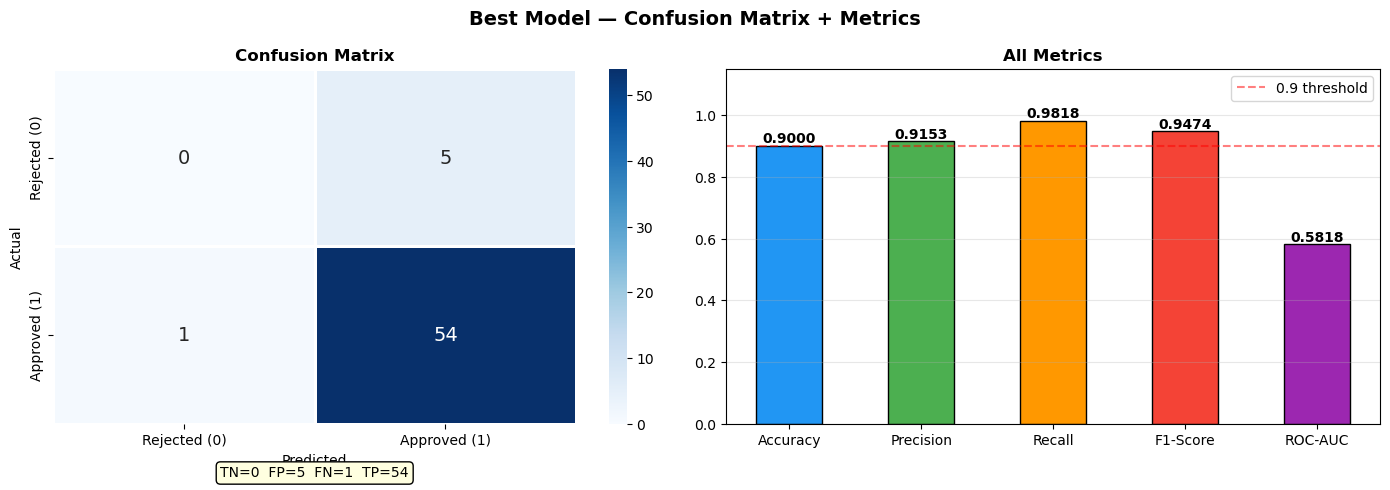

              precision    recall  f1-score   support

    Rejected       0.00      0.00      0.00         5
    Approved       0.92      0.98      0.95        55

    accuracy                           0.90        60
   macro avg       0.46      0.49      0.47        60
weighted avg       0.84      0.90      0.87        60



In [72]:
# Best model select karo
best_pipeline = gs_xgb.best_estimator_
best_pipeline.fit(X_train_clf, y_train_clf)
y_pred_best = best_pipeline.predict(X_test_clf)

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Best Model — Confusion Matrix + Metrics',
             fontsize=14, fontweight='bold')

# --- Confusion Matrix heatmap ---
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'],
            ax=axes[0],
            linewidths=1,
            annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.15,
             f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
             transform=axes[0].transAxes,
             ha='center', fontsize=10,
             bbox=dict(boxstyle='round',
                       facecolor='lightyellow'))

# --- Metrics bar chart ---
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metric_vals = [
    accuracy_score(y_test_clf, y_pred_best),
    precision_score(y_test_clf, y_pred_best),
    recall_score(y_test_clf, y_pred_best),
    f1_score(y_test_clf, y_pred_best),
    roc_auc_score(y_test_clf,
        best_pipeline.predict_proba(X_test_clf)[:, 1])
]
colors = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0']
bars = axes[1].bar(metrics, metric_vals, color=colors,
                   edgecolor='black', width=0.5)
for bar, val in zip(bars, metric_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center',
                 fontweight='bold', fontsize=10)
axes[1].set_title('All Metrics', fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].axhline(y=0.9, color='red', linestyle='--',
                alpha=0.5, label='0.9 threshold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print(classification_report(y_test_clf, y_pred_best,
      target_names=['Rejected', 'Approved']))

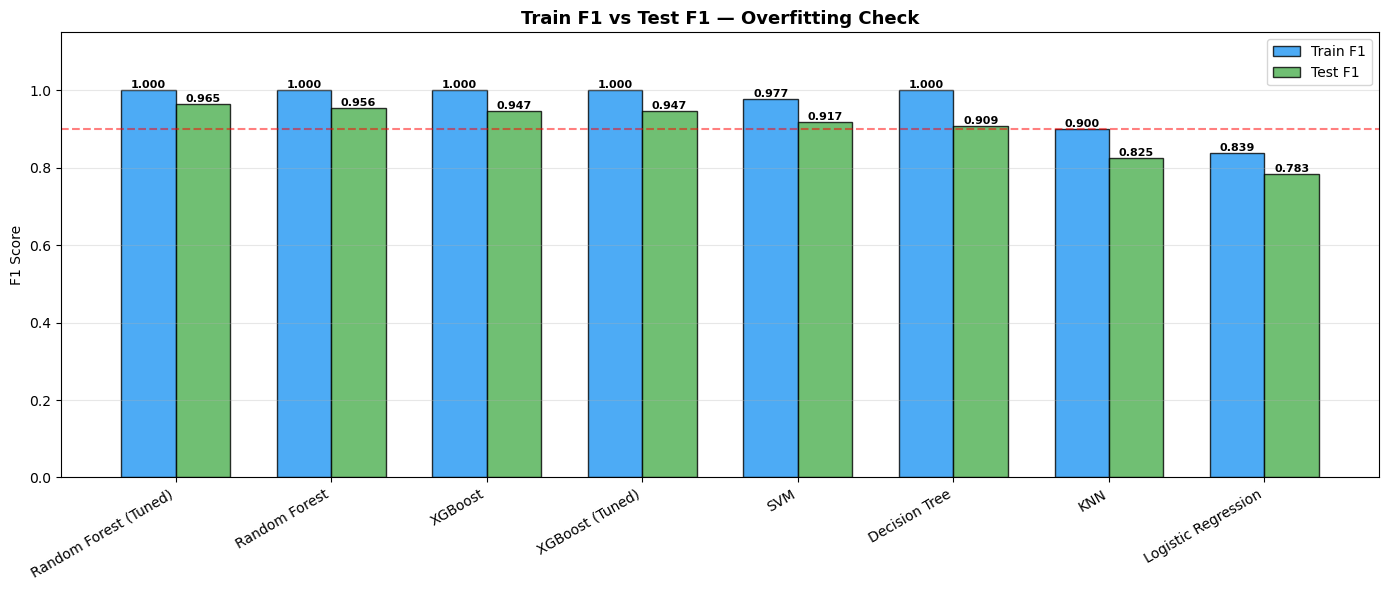

✅ Blue bar Train se Green bar Test bahut alag ho
   toh Overfitting hai


In [73]:
models_list = results_df['Model'].tolist()
train_f1s   = results_df['Train F1'].tolist()
test_f1s    = results_df['Test F1'].tolist()

x     = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, train_f1s, width,
               label='Train F1', color='#2196F3',
               edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, test_f1s,  width,
               label='Test F1',  color='#4CAF50',
               edgecolor='black', alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=8, fontweight='bold')

ax.set_title('Train F1 vs Test F1 — Overfitting Check',
             fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=30, ha='right')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.15)
ax.legend()
ax.axhline(y=0.9, color='red', linestyle='--',
           alpha=0.5, label='0.9 line')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Blue bar Train se Green bar Test bahut alag ho")
print("   toh Overfitting hai")

In [74]:
import joblib

# Best model save karo
best_pipeline.fit(X_train_clf, y_train_clf)
joblib.dump(best_pipeline, 'best_classification_model.pkl')

print("=" * 55)
print("✅  PHASE 8 — CLASSIFICATION — COMPLETE")
print("=" * 55)
print()
print(f"  Best Model    : {best_row['Model']}")
print(f"  Test F1       : {best_row['Test F1']}")
print(f"  ROC-AUC       : {best_row['ROC-AUC']}")
print(f"  Precision     : {best_row['Precision']}")
print(f"  Recall        : {best_row['Recall']}")
print()
print("  ✅ 6 models train kiye")
print("  ✅ RF + XGBoost hyperparameter tuned")
print("  ✅ Confusion Matrix dekha")
print("  ✅ Overfitting check kiya")
print("  ✅ Best model .pkl mein save kiya")
print()
print("  ➡️  Agla Step : PHASE 9 — Regression 1")
print("       (Approved Amount predict karna)")
print("=" * 55)

✅  PHASE 8 — CLASSIFICATION — COMPLETE

  Best Model    : Random Forest (Tuned)
  Test F1       : 0.9649
  ROC-AUC       : 0.6291
  Precision     : 0.9322
  Recall        : 1.0

  ✅ 6 models train kiye
  ✅ RF + XGBoost hyperparameter tuned
  ✅ Confusion Matrix dekha
  ✅ Overfitting check kiya
  ✅ Best model .pkl mein save kiya

  ➡️  Agla Step : PHASE 9 — Regression 1
       (Approved Amount predict karna)


**REGRESSION**

In [75]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries import ho gayi")
print()
print("  Datasets available:")
print(f"  Unscaled → X_train_reg1 : {X_train_reg1.shape}  (Tree models)")
print(f"  Scaled   → X_train_reg1_scaled : {X_train_reg1_scaled.shape}  (Linear models)")
print(f"  y_train_reg1 : {y_train_reg1.shape}")
print(f"  y_test_reg1  : {y_test_reg1.shape}")
print()
print("  Leakage check:")
print(f"  loan_status in X_train_reg1 : "
      f"{'❌ LEAKAGE!' if 'loan_status' in X_train_reg1.columns else '✅ Nahi hai'}")
print(f"  approved_amount in X_train_reg1 : "
      f"{'❌ LEAKAGE!' if 'approved_amount' in X_train_reg1.columns else '✅ Nahi hai'}")

✅ Libraries import ho gayi

  Datasets available:
  Unscaled → X_train_reg1 : (220, 20)  (Tree models)
  Scaled   → X_train_reg1_scaled : (220, 20)  (Linear models)
  y_train_reg1 : (220,)
  y_test_reg1  : (55,)

  Leakage check:
  loan_status in X_train_reg1 : ✅ Nahi hai
  approved_amount in X_train_reg1 : ✅ Nahi hai


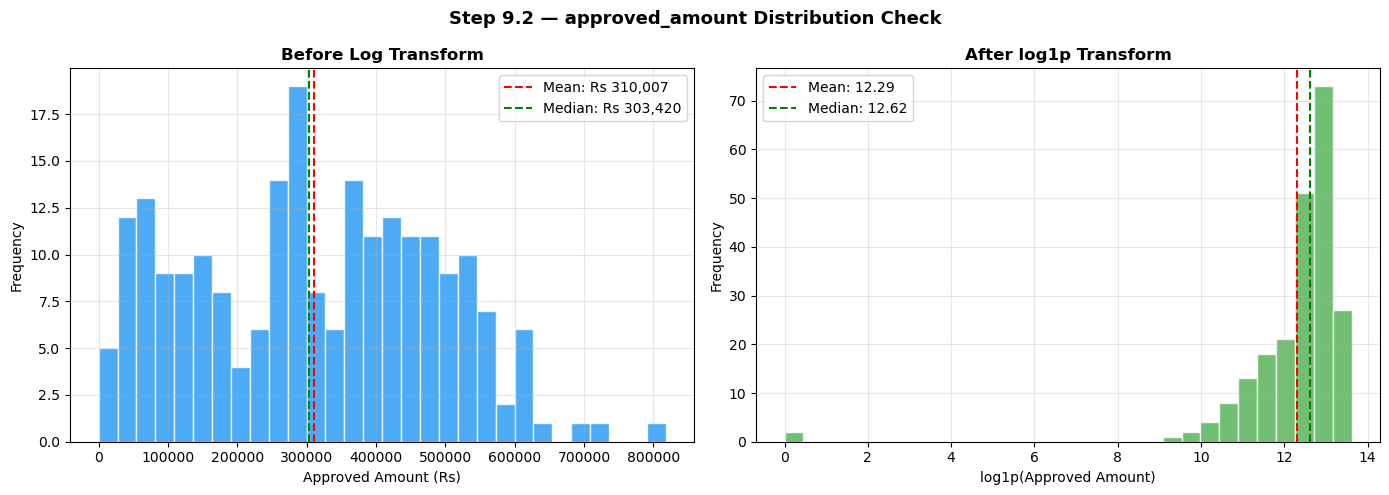

  Skewness before log : 0.0953
  Skewness after  log : -5.8760

  ✅ Normal distribution — log transform zaruri nahi


In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 9.2 — approved_amount Distribution Check',
             fontsize=13, fontweight='bold')

# --- Before log transform ---
axes[0].hist(y_train_reg1, bins=30, color='#2196F3',
             edgecolor='white', alpha=0.8)
axes[0].set_title('Before Log Transform', fontweight='bold')
axes[0].set_xlabel('Approved Amount (Rs)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(y_train_reg1.mean(), color='red',
                linestyle='--', label=f'Mean: Rs {y_train_reg1.mean():,.0f}')
axes[0].axvline(y_train_reg1.median(), color='green',
                linestyle='--', label=f'Median: Rs {y_train_reg1.median():,.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- After log transform ---
y_train_log = np.log1p(y_train_reg1)
axes[1].hist(y_train_log, bins=30, color='#4CAF50',
             edgecolor='white', alpha=0.8)
axes[1].set_title('After log1p Transform', fontweight='bold')
axes[1].set_xlabel('log1p(Approved Amount)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(y_train_log.mean(), color='red',
                linestyle='--', label=f'Mean: {y_train_log.mean():.2f}')
axes[1].axvline(y_train_log.median(), color='green',
                linestyle='--', label=f'Median: {y_train_log.median():.2f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Skewness check
from scipy import stats
skew_before = stats.skew(y_train_reg1)
skew_after  = stats.skew(y_train_log)
print(f"  Skewness before log : {skew_before:.4f}")
print(f"  Skewness after  log : {skew_after:.4f}")
print()
if abs(skew_before) > 0.5:
    print("  ⚠️  Skewed hai — log1p transform use karenge")
else:
    print("  ✅ Normal distribution — log transform zaruri nahi")

In [77]:
# Train aur Test dono par log1p lagao
y_train_reg1_log = np.log1p(y_train_reg1)
y_test_reg1_log  = np.log1p(y_test_reg1)

print("log1p Transform Applied:\n")
print(f"  {'':25} {'Original':>15} {'After log1p':>15}")
print("  " + "-" * 58)
print(f"  {'y_train min':<25} "
      f"Rs {y_train_reg1.min():>12,.0f} "
      f"{y_train_reg1_log.min():>15.4f}")
print(f"  {'y_train max':<25} "
      f"Rs {y_train_reg1.max():>12,.0f} "
      f"{y_train_reg1_log.max():>15.4f}")
print(f"  {'y_train mean':<25} "
      f"Rs {y_train_reg1.mean():>12,.0f} "
      f"{y_train_reg1_log.mean():>15.4f}")
print()
print("  ⚠️  Predict karne ke baad np.expm1() se")
print("      wapas original scale mein convert karna")
print("      y_pred_original = np.expm1(y_pred_log)")

log1p Transform Applied:

                                   Original     After log1p
  ----------------------------------------------------------
  y_train min               Rs            0          0.0000
  y_train max               Rs      817,750         13.6143
  y_train mean              Rs      310,007         12.2943

  ⚠️  Predict karne ke baad np.expm1() se
      wapas original scale mein convert karna
      y_pred_original = np.expm1(y_pred_log)


In [78]:
def evaluate_regressor(model_name, model,
                        X_tr, y_tr_log,
                        X_te, y_te_log,
                        y_te_original):

    # Train karo log scale mein
    model.fit(X_tr, y_tr_log)

    # Predict karo — log scale mein
    y_pred_train_log = model.predict(X_tr)
    y_pred_test_log  = model.predict(X_te)

    # Wapas original scale mein convert karo
    y_pred_train_orig = np.expm1(y_pred_train_log)
    y_pred_test_orig  = np.expm1(y_pred_test_log)

    # Train metrics (original scale mein)
    y_tr_orig  = np.expm1(y_tr_log)
    train_r2   = r2_score(y_tr_orig, y_pred_train_orig)

    # Test metrics (original scale mein)
    test_mae  = mean_absolute_error(y_te_original, y_pred_test_orig)
    test_rmse = np.sqrt(mean_squared_error(y_te_original, y_pred_test_orig))
    test_r2   = r2_score(y_te_original, y_pred_test_orig)

    # Overfitting check
    gap  = train_r2 - test_r2
    flag = "⚠️  Overfit" if gap > 0.10 else "✅ Good"

    return {
        'Model'     : model_name,
        'Train R²'  : round(train_r2,  4),
        'Test R²'   : round(test_r2,   4),
        'MAE (Rs)'  : round(test_mae,  0),
        'RMSE (Rs)' : round(test_rmse, 0),
        'Gap'       : round(gap,       4),
        'Overfit?'  : flag
    }

print("✅ evaluate_regressor() function ready")
print()
print("  Kya karta hai:")
print("    → Log scale mein train karta hai")
print("    → Predict karta hai log scale mein")
print("    → expm1 se original scale mein convert")
print("    → MAE, RMSE, R² nikalata hai")
print("    → Train vs Test R² gap se overfitting check")

✅ evaluate_regressor() function ready



  Kya karta hai:
    → Log scale mein train karta hai
    → Predict karta hai log scale mein
    → expm1 se original scale mein convert
    → MAE, RMSE, R² nikalata hai
    → Train vs Test R² gap se overfitting check


In [79]:
reg_results = []

# ─── 1. Linear Regression (Baseline — Scaled) ───
reg_results.append(evaluate_regressor(
    'Linear Regression',
    LinearRegression(),
    X_train_reg1_scaled, y_train_reg1_log,
    X_test_reg1_scaled,  y_test_reg1_log,
    y_test_reg1
))
print("✅ 1/5 Linear Regression done")

# ─── 2. Ridge Regression (Scaled) ───
reg_results.append(evaluate_regressor(
    'Ridge Regression',
    Ridge(alpha=1.0),
    X_train_reg1_scaled, y_train_reg1_log,
    X_test_reg1_scaled,  y_test_reg1_log,
    y_test_reg1
))
print("✅ 2/5 Ridge Regression done")

# ─── 3. Lasso Regression (Scaled) ───
reg_results.append(evaluate_regressor(
    'Lasso Regression',
    Lasso(alpha=0.01),
    X_train_reg1_scaled, y_train_reg1_log,
    X_test_reg1_scaled,  y_test_reg1_log,
    y_test_reg1
))
print("✅ 3/5 Lasso Regression done")

# ─── 4. Random Forest (Unscaled) ───
reg_results.append(evaluate_regressor(
    'Random Forest',
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train_reg1, y_train_reg1_log,
    X_test_reg1,  y_test_reg1_log,
    y_test_reg1
))
print("✅ 4/5 Random Forest done")

# ─── 5. XGBoost (Unscaled) ───
reg_results.append(evaluate_regressor(
    'XGBoost',
    XGBRegressor(random_state=42, verbosity=0),
    X_train_reg1, y_train_reg1_log,
    X_test_reg1,  y_test_reg1_log,
    y_test_reg1
))
print("✅ 5/5 XGBoost done")
print()
print("✅ Sab 5 models train ho gaye!")

✅ 1/5 Linear Regression done
✅ 2/5 Ridge Regression done
✅ 3/5 Lasso Regression done
✅ 4/5 Random Forest done
✅ 5/5 XGBoost done

✅ Sab 5 models train ho gaye!


In [80]:
# RF aur XGBoost tune karo
print("GridSearchCV — Random Forest Regressor:")
rf_params = {
    'n_estimators' : [100, 200],
    'max_depth'    : [None, 5, 10],
    'min_samples_split' : [2, 5],
}
gs_rf_reg = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=42),
    param_grid = rf_params,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)
gs_rf_reg.fit(X_train_reg1, y_train_reg1_log)
print(f"  Best params : {gs_rf_reg.best_params_}")
print(f"  Best CV R²  : {gs_rf_reg.best_score_:.4f}")
print()

print("GridSearchCV — XGBoost Regressor:")
xgb_params = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.05, 0.1],
}
gs_xgb_reg = GridSearchCV(
    estimator  = XGBRegressor(random_state=42, verbosity=0),
    param_grid = xgb_params,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)
gs_xgb_reg.fit(X_train_reg1, y_train_reg1_log)
print(f"  Best params : {gs_xgb_reg.best_params_}")
print(f"  Best CV R²  : {gs_xgb_reg.best_score_:.4f}")

# Tuned models evaluate karo
reg_results.append(evaluate_regressor(
    'Random Forest (Tuned)',
    gs_rf_reg.best_estimator_,
    X_train_reg1, y_train_reg1_log,
    X_test_reg1,  y_test_reg1_log,
    y_test_reg1
))
reg_results.append(evaluate_regressor(
    'XGBoost (Tuned)',
    gs_xgb_reg.best_estimator_,
    X_train_reg1, y_train_reg1_log,
    X_test_reg1,  y_test_reg1_log,
    y_test_reg1
))
print()
print("✅ Tuned models evaluate ho gaye")

GridSearchCV — Random Forest Regressor:
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best params : {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
  Best CV R²  : 0.1833

GridSearchCV — XGBoost Regressor:
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  Best CV R²  : 0.3657

✅ Tuned models evaluate ho gaye


In [81]:
reg_df = pd.DataFrame(reg_results).sort_values('Test R²', ascending=False)
reg_df = reg_df.reset_index(drop=True)

print("=" * 80)
print("  REGRESSION 1 — ALL MODELS COMPARISON (Approved Amount)")
print("=" * 80)
print(reg_df.to_string(index=False))
print()
best_reg = reg_df.iloc[0]
print(f"  🏆 Best Model  : {best_reg['Model']}")
print(f"     Test R²     : {best_reg['Test R²']}")
print(f"     MAE         : Rs {best_reg['MAE (Rs)']:,.0f}")
print(f"     RMSE        : Rs {best_reg['RMSE (Rs)']:,.0f}")
print()
print(f"  MAE Interpretation:")
print(f"  → Model average Rs {best_reg['MAE (Rs)']:,.0f} "
      f"se galat predict kar raha hai")

  REGRESSION 1 — ALL MODELS COMPARISON (Approved Amount)
                Model  Train R²  Test R²  MAE (Rs)  RMSE (Rs)    Gap    Overfit?
              XGBoost    1.0000   0.9112   30232.0    55546.0 0.0888      ✅ Good
      XGBoost (Tuned)    0.8937   0.7723   53821.0    88947.0 0.1215 ⚠️  Overfit
Random Forest (Tuned)    0.7497   0.6006   58397.0   117800.0 0.1491 ⚠️  Overfit
        Random Forest    0.7470   0.5875   58990.0   119717.0 0.1595 ⚠️  Overfit
     Lasso Regression    0.5455   0.4560  109044.0   137477.0 0.0895      ✅ Good
     Ridge Regression    0.4896   0.2704  124388.0   159216.0 0.2192 ⚠️  Overfit
    Linear Regression    0.4620   0.0496  134998.0   181711.0 0.4124 ⚠️  Overfit

  🏆 Best Model  : XGBoost
     Test R²     : 0.9112
     MAE         : Rs 30,232
     RMSE        : Rs 55,546

  MAE Interpretation:
  → Model average Rs 30,232 se galat predict kar raha hai


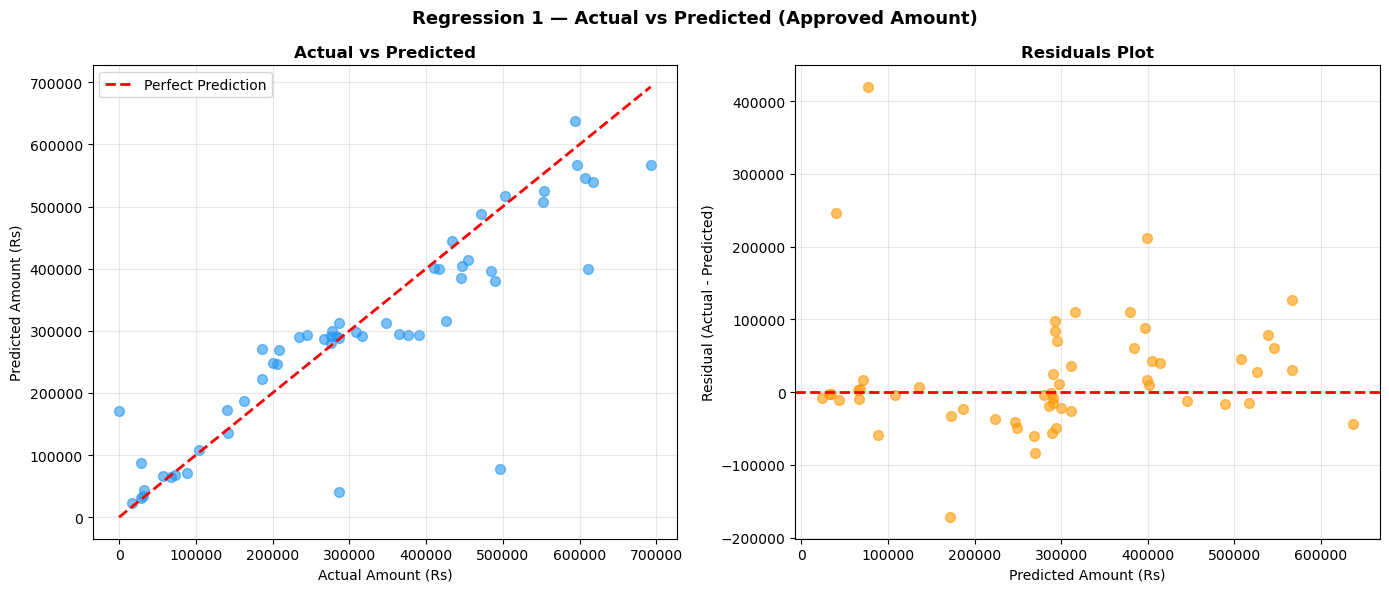

  Red line ke paas points → Better prediction
  Residuals random hone chahiye — koi pattern nahi


In [82]:
# Best model se predictions
best_reg_model = gs_xgb_reg.best_estimator_
best_reg_model.fit(X_train_reg1, y_train_reg1_log)
y_pred_log  = best_reg_model.predict(X_test_reg1)
y_pred_orig = np.expm1(y_pred_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Regression 1 — Actual vs Predicted (Approved Amount)',
             fontsize=13, fontweight='bold')

# --- Scatter Plot ---
axes[0].scatter(y_test_reg1, y_pred_orig,
                alpha=0.6, color='#2196F3', s=50)
min_val = min(y_test_reg1.min(), y_pred_orig.min())
max_val = max(y_test_reg1.max(), y_pred_orig.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             color='red', linestyle='--',
             linewidth=2, label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].set_xlabel('Actual Amount (Rs)')
axes[0].set_ylabel('Predicted Amount (Rs)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Residuals Plot ---
residuals = y_test_reg1 - y_pred_orig
axes[1].scatter(y_pred_orig, residuals,
                alpha=0.6, color='#FF9800', s=50)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals Plot', fontweight='bold')
axes[1].set_xlabel('Predicted Amount (Rs)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("  Red line ke paas points → Better prediction")
print("  Residuals random hone chahiye — koi pattern nahi")

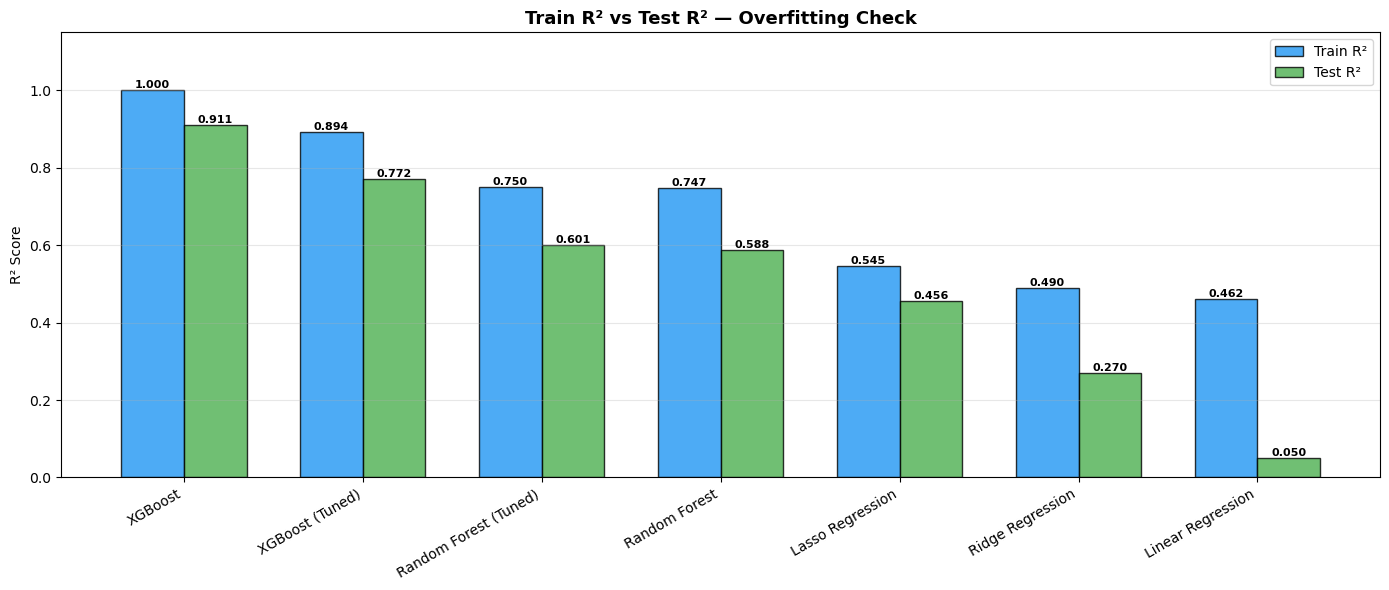

  Train R² >> Test R² → ⚠️  Overfitting
  Train R² ≈ Test R²  → ✅ Model generalize kar raha hai


In [83]:
models_reg  = reg_df['Model'].tolist()
train_r2s   = reg_df['Train R²'].tolist()
test_r2s    = reg_df['Test R²'].tolist()

x     = np.arange(len(models_reg))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, train_r2s, width,
               label='Train R²', color='#2196F3',
               edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, test_r2s, width,
               label='Test R²', color='#4CAF50',
               edgecolor='black', alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=8, fontweight='bold')

ax.set_title('Train R² vs Test R² — Overfitting Check',
             fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models_reg, rotation=30, ha='right')
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("  Train R² >> Test R² → ⚠️  Overfitting")
print("  Train R² ≈ Test R²  → ✅ Model generalize kar raha hai")

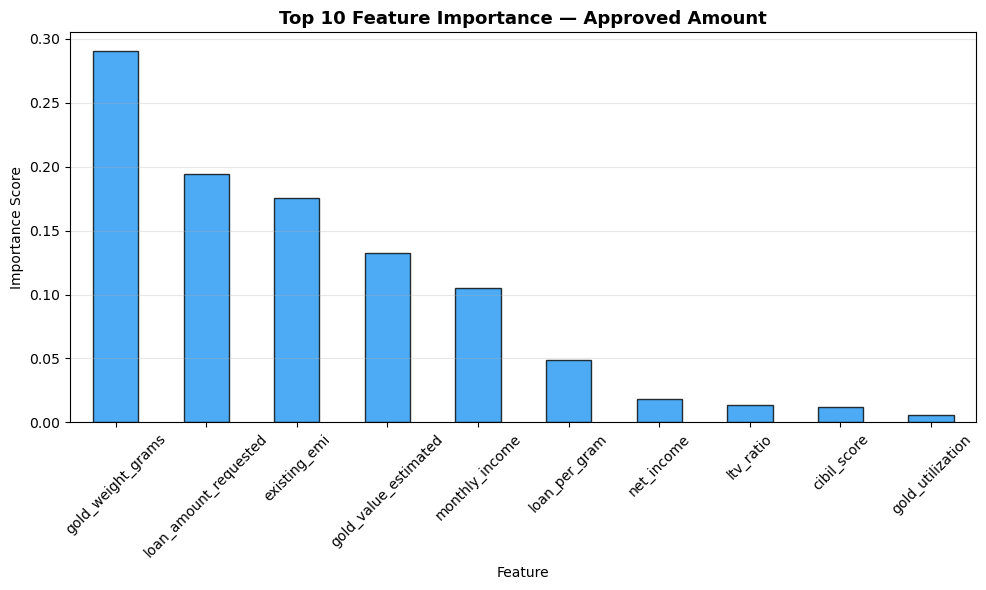

✅  PHASE 9 — REGRESSION 1 — COMPLETE

  Best Model  : XGBoost
  Test R²     : 0.9112
  MAE         : Rs 30,232
  RMSE        : Rs 55,546



In [84]:
import joblib

# Feature Importance
feat_imp = pd.Series(
    best_reg_model.feature_importances_,
    index=X_train_reg1.columns
).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='bar', ax=ax, color='#2196F3',
              edgecolor='black', alpha=0.8)
ax.set_title('Top 10 Feature Importance — Approved Amount',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Importance Score')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Model save karo
joblib.dump(best_reg_model, 'best_regression1_model.pkl')
joblib.dump(scaler_reg1,    'scaler_reg1.pkl')

print("=" * 55)
print("✅  PHASE 9 — REGRESSION 1 — COMPLETE")
print("=" * 55)
print()
print(f"  Best Model  : {best_reg['Model']}")
print(f"  Test R²     : {best_reg['Test R²']}")
print(f"  MAE         : Rs {best_reg['MAE (Rs)']:,.0f}")
print(f"  RMSE        : Rs {best_reg['RMSE (Rs)']:,.0f}")
print()


**REGRESSION - INTEREST RATE**

In [85]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline as SklearnPipeline
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries import ho gayi")
print()
print("  Datasets available:")
print(f"  Unscaled → X_train_reg2        : {X_train_reg2.shape}")
print(f"  Unscaled → X_test_reg2         : {X_test_reg2.shape}")
print(f"  Scaled   → X_train_reg2_scaled : {X_train_reg2_scaled.shape}")
print(f"  Scaled   → X_test_reg2_scaled  : {X_test_reg2_scaled.shape}")
print(f"  Target   → y_train_reg2        : {y_train_reg2.shape}")
print(f"  Target   → y_test_reg2         : {y_test_reg2.shape}")

✅ Libraries import ho gayi

  Datasets available:
  Unscaled → X_train_reg2        : (240, 20)
  Unscaled → X_test_reg2         : (60, 20)
  Scaled   → X_train_reg2_scaled : (240, 20)
  Scaled   → X_test_reg2_scaled  : (60, 20)
  Target   → y_train_reg2        : (240,)
  Target   → y_test_reg2         : (60,)


In [86]:
print("Step 10.1 — Leakage Check:\n")

for name, X in [('X_train_reg2', X_train_reg2),
                ('X_test_reg2',  X_test_reg2)]:
    leak_cols = [c for c in ['loan_status', 'approved_amount',
                              'interest_rate'] if c in X.columns]
    if leak_cols:
        print(f"  ❌ {name} mein leakage columns hain: {leak_cols}")
        print(f"     Abhi drop karo!")
        for col in leak_cols:
            X.drop(columns=[col], inplace=True)
        print(f"     ✅ Drop kar diya")
    else:
        print(f"  ✅ {name} — koi leakage column nahi")

print()
print(f"  X_train_reg2 shape : {X_train_reg2.shape}")
print(f"  X_test_reg2  shape : {X_test_reg2.shape}")
print(f"  y_train_reg2 shape : {y_train_reg2.shape}")
print(f"  y_test_reg2  shape : {y_test_reg2.shape}")
print()
print(f"  y_train stats:")
print(f"    Min   : {y_train_reg2.min():.2f}%")
print(f"    Max   : {y_train_reg2.max():.2f}%")
print(f"    Mean  : {y_train_reg2.mean():.4f}%")

Step 10.1 — Leakage Check:

  ✅ X_train_reg2 — koi leakage column nahi
  ✅ X_test_reg2 — koi leakage column nahi

  X_train_reg2 shape : (240, 20)
  X_test_reg2  shape : (60, 20)
  y_train_reg2 shape : (240,)
  y_test_reg2  shape : (60,)

  y_train stats:
    Min   : 10.20%
    Max   : 11.80%
    Mean  : 11.0895%


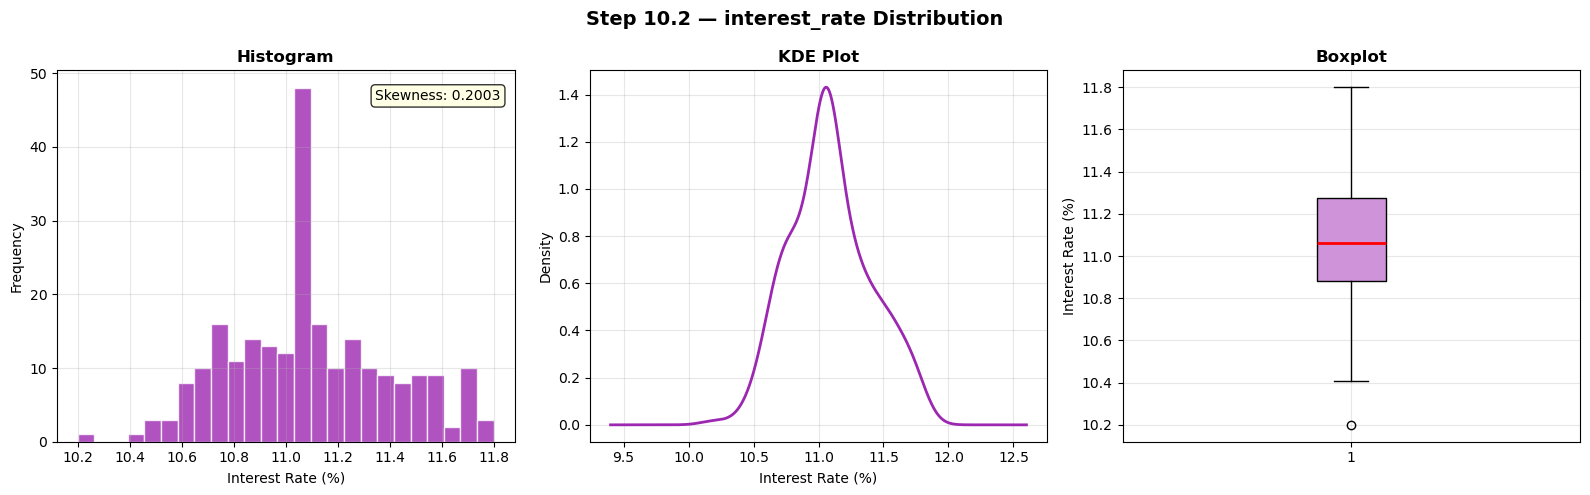

Step 10.2 — Range Analysis:

  Min Range     : 10.20%
  Max Range     : 11.80%
  Total Gap     : 1.60%  ← bahut tight!
  Skewness      : 0.2003

  ⚠️  Important Warnings:
     → Range sirf 1.66% — model ke liye bahut kam
     → R² naturally low aayega — 0.3 bhi acceptable
     → MAE ko zyada importance dena
     → Log transform NAHI karenge
       (range itni chhoti hai ki transform
        aur bhi confuse karega)


In [87]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Step 10.2 — interest_rate Distribution',
             fontsize=14, fontweight='bold')

# --- Histogram ---
axes[0].hist(y_train_reg2, bins=25,
             color='#9C27B0', edgecolor='white', alpha=0.8)
axes[0].set_title('Histogram', fontweight='bold')
axes[0].set_xlabel('Interest Rate (%)')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)
skew_val = stats.skew(y_train_reg2)
axes[0].text(0.97, 0.95,
             f'Skewness: {skew_val:.4f}',
             transform=axes[0].transAxes,
             ha='right', va='top',
             bbox=dict(boxstyle='round',
                       facecolor='lightyellow', alpha=0.8))

# --- KDE Plot ---
y_train_reg2.plot(kind='kde', ax=axes[1],
                  color='#9C27B0', linewidth=2)
axes[1].set_title('KDE Plot', fontweight='bold')
axes[1].set_xlabel('Interest Rate (%)')
axes[1].grid(alpha=0.3)

# --- Boxplot ---
axes[2].boxplot(y_train_reg2,
                patch_artist=True,
                boxprops=dict(facecolor='#CE93D8', color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Boxplot', fontweight='bold')
axes[2].set_ylabel('Interest Rate (%)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Step 10.2 — Range Analysis:\n")
total_range = y_train_reg2.max() - y_train_reg2.min()
print(f"  Min Range     : {y_train_reg2.min():.2f}%")
print(f"  Max Range     : {y_train_reg2.max():.2f}%")
print(f"  Total Gap     : {total_range:.2f}%  ← bahut tight!")
print(f"  Skewness      : {skew_val:.4f}")
print()
print("  ⚠️  Important Warnings:")
print("     → Range sirf 1.66% — model ke liye bahut kam")
print("     → R² naturally low aayega — 0.3 bhi acceptable")
print("     → MAE ko zyada importance dena")
print("     → Log transform NAHI karenge")
print("       (range itni chhoti hai ki transform")
print("        aur bhi confuse karega)")

In [88]:
def evaluate_reg2(model_name, model, X_tr, y_tr, X_te, y_te):

    # Train karo
    model.fit(X_tr, y_tr)

    # Predict karo
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    # Metrics
    train_r2  = r2_score(y_tr, y_pred_train)
    test_r2   = r2_score(y_te, y_pred_test)
    test_mae  = mean_absolute_error(y_te, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_te, y_pred_test))

    # Overfitting check
    gap  = train_r2 - test_r2
    flag = "⚠️  Overfit" if gap > 0.10 else "✅ Good"

    return {
        'Model'    : model_name,
        'Train R²' : round(train_r2,  4),
        'Test R²'  : round(test_r2,   4),
        'MAE (%)'  : round(test_mae,  5),
        'RMSE (%)' : round(test_rmse, 5),
        'Gap'      : round(gap,       4),
        'Overfit?' : flag
    }

print("✅ evaluate_reg2() function ready")
print()
print("  Note:")
print("    → Log transform nahi karenge yahan")
print("      (range 1.66% — transform zaruri nahi)")
print("    → MAE % mein aayega — zyada interpretable")
print("    → R² low aaye toh ghabrana nahi")

✅ evaluate_reg2() function ready

  Note:
    → Log transform nahi karenge yahan
      (range 1.66% — transform zaruri nahi)
    → MAE % mein aayega — zyada interpretable
    → R² low aaye toh ghabrana nahi


In [89]:
reg2_results = []

# ─── 1. Linear Regression (Baseline — Scaled) ───
reg2_results.append(evaluate_reg2(
    'Linear Regression',
    LinearRegression(),
    X_train_reg2_scaled, y_train_reg2,
    X_test_reg2_scaled,  y_test_reg2
))
print("✅ 1/6 Linear Regression done")

# ─── 2. Ridge Regression (L2 — Scaled) ───
reg2_results.append(evaluate_reg2(
    'Ridge Regression',
    Ridge(alpha=1.0),
    X_train_reg2_scaled, y_train_reg2,
    X_test_reg2_scaled,  y_test_reg2
))
print("✅ 2/6 Ridge Regression done")

# ─── 3. Lasso Regression (L1 — Scaled) ───
reg2_results.append(evaluate_reg2(
    'Lasso Regression',
    Lasso(alpha=0.0001),
    X_train_reg2_scaled, y_train_reg2,
    X_test_reg2_scaled,  y_test_reg2
))
print("✅ 3/6 Lasso Regression done")

# ─── 4. Polynomial Regression (degree=2 — Scaled) ───
poly_pipeline = SklearnPipeline([
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])
reg2_results.append(evaluate_reg2(
    'Polynomial Regression',
    poly_pipeline,
    X_train_reg2_scaled, y_train_reg2,
    X_test_reg2_scaled,  y_test_reg2
))
print("✅ 4/6 Polynomial Regression done")

# ─── 5. Random Forest (Unscaled) ───
reg2_results.append(evaluate_reg2(
    'Random Forest',
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train_reg2, y_train_reg2,
    X_test_reg2,  y_test_reg2
))
print("✅ 5/6 Random Forest done")

# ─── 6. XGBoost (Unscaled) ───
reg2_results.append(evaluate_reg2(
    'XGBoost',
    XGBRegressor(random_state=42, verbosity=0),
    X_train_reg2, y_train_reg2,
    X_test_reg2,  y_test_reg2
))
print("✅ 6/6 XGBoost done")
print()
print("✅ Sab 6 models train ho gaye!")

✅ 1/6 Linear Regression done
✅ 2/6 Ridge Regression done
✅ 3/6 Lasso Regression done
✅ 4/6 Polynomial Regression done
✅ 5/6 Random Forest done
✅ 6/6 XGBoost done

✅ Sab 6 models train ho gaye!


In [90]:
# ─── Ridge Tuning ───
print("GridSearchCV — Ridge:")
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
gs_ridge = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5, scoring='r2', n_jobs=-1
)
gs_ridge.fit(X_train_reg2_scaled, y_train_reg2)
print(f"  Best alpha : {gs_ridge.best_params_}")
print(f"  Best CV R² : {gs_ridge.best_score_:.4f}")
print()

# ─── Random Forest Tuning ───
print("GridSearchCV — Random Forest:")
rf_params = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5],
}
gs_rf2 = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
gs_rf2.fit(X_train_reg2, y_train_reg2)
print(f"  Best params : {gs_rf2.best_params_}")
print(f"  Best CV R²  : {gs_rf2.best_score_:.4f}")
print()

# ─── XGBoost Tuning ───
print("GridSearchCV — XGBoost:")
xgb_params = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5],
    'learning_rate' : [0.05, 0.1],
}
gs_xgb2 = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
gs_xgb2.fit(X_train_reg2, y_train_reg2)
print(f"  Best params : {gs_xgb2.best_params_}")
print(f"  Best CV R²  : {gs_xgb2.best_score_:.4f}")
print()

# Tuned models add karo
reg2_results.append(evaluate_reg2(
    'Ridge (Tuned)',
    gs_ridge.best_estimator_,
    X_train_reg2_scaled, y_train_reg2,
    X_test_reg2_scaled,  y_test_reg2
))
reg2_results.append(evaluate_reg2(
    'Random Forest (Tuned)',
    gs_rf2.best_estimator_,
    X_train_reg2, y_train_reg2,
    X_test_reg2,  y_test_reg2
))
reg2_results.append(evaluate_reg2(
    'XGBoost (Tuned)',
    gs_xgb2.best_estimator_,
    X_train_reg2, y_train_reg2,
    X_test_reg2,  y_test_reg2
))
print("✅ Tuned models evaluate ho gaye")

GridSearchCV — Ridge:
  Best alpha : {'alpha': 10.0}
  Best CV R² : 0.4521

GridSearchCV — Random Forest:
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  Best CV R²  : 0.4284

GridSearchCV — XGBoost:
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  Best CV R²  : 0.4048

✅ Tuned models evaluate ho gaye


In [91]:
reg2_df = pd.DataFrame(reg2_results).sort_values('MAE (%)',
                        ascending=True)
reg2_df = reg2_df.reset_index(drop=True)

print("=" * 80)
print("  REGRESSION 2 — ALL MODELS COMPARISON (interest_rate)")
print("=" * 80)
print(reg2_df.to_string(index=False))
print()
best_reg2 = reg2_df.iloc[0]
print(f"  🏆 Best Model  : {best_reg2['Model']}")
print(f"     MAE         : {best_reg2['MAE (%)']:.5f}%")
print(f"     RMSE        : {best_reg2['RMSE (%)']:.5f}%")
print(f"     Test R²     : {best_reg2['Test R²']}")
print()
print("  ⚠️  R² Interpretation yahan:")
print("     R² < 0.3  → Acceptable  (range 1.66% hai)")
print("     R² < 0.5  → Theek hai")
print("     R² > 0.5  → Achha hai")
print("     MAE < 0.2 → Model useful hai practically")

  REGRESSION 2 — ALL MODELS COMPARISON (interest_rate)
                Model  Train R²  Test R²  MAE (%)  RMSE (%)     Gap    Overfit?
        Ridge (Tuned)    0.5681   0.3623  0.20429   0.24996  0.2058 ⚠️  Overfit
    Linear Regression    0.5710   0.3528  0.20447   0.25181  0.2182 ⚠️  Overfit
     Ridge Regression    0.5709   0.3542  0.20464   0.25153  0.2167 ⚠️  Overfit
     Lasso Regression    0.5710   0.3534  0.20472   0.25170  0.2176 ⚠️  Overfit
      XGBoost (Tuned)    0.8156   0.2955  0.21235   0.26271  0.5200 ⚠️  Overfit
        Random Forest    0.9207   0.2670  0.21439   0.26798  0.6537 ⚠️  Overfit
Random Forest (Tuned)    0.9207   0.2670  0.21439   0.26798  0.6537 ⚠️  Overfit
              XGBoost    1.0000   0.1288  0.24007   0.29215  0.8712 ⚠️  Overfit
Polynomial Regression    0.8827  -9.2348  0.56131   1.00135 10.1174 ⚠️  Overfit

  🏆 Best Model  : Ridge (Tuned)
     MAE         : 0.20429%
     RMSE        : 0.24996%
     Test R²     : 0.3623

  ⚠️  R² Interpretation yahan

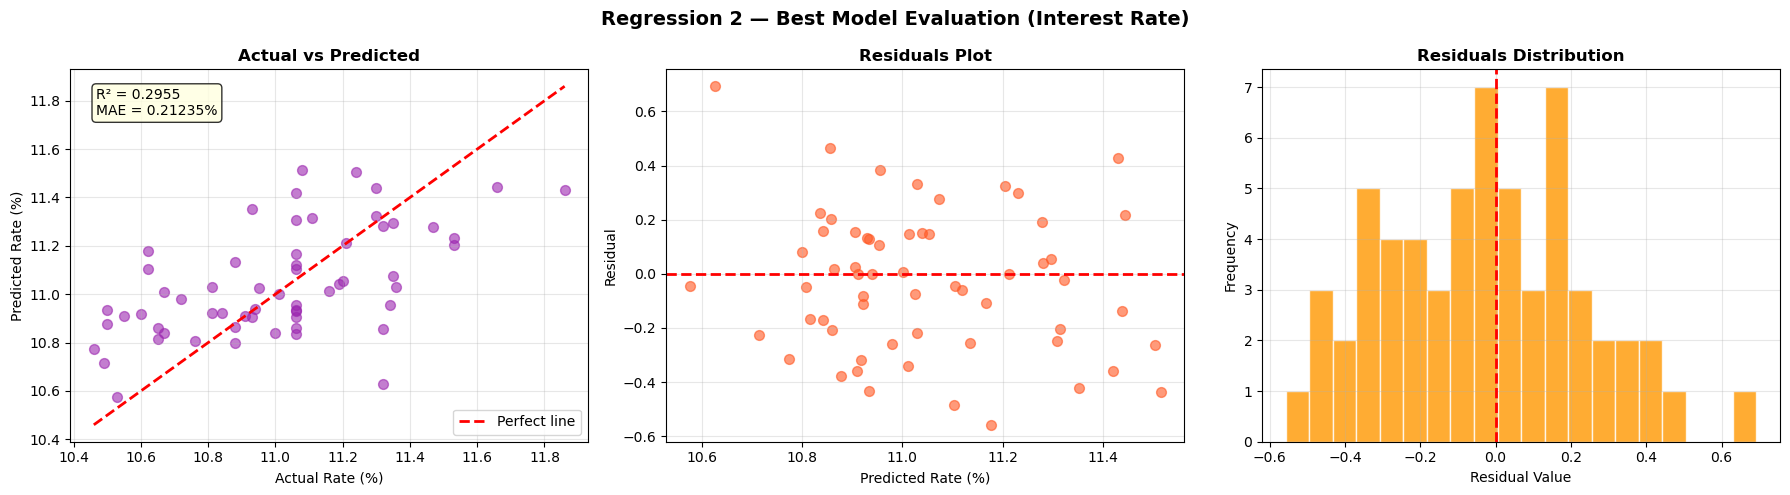

  ✅ Points perfect line ke paas = achha model
  ✅ Residuals 0 ke around symmetric = achha


In [92]:
# Best model
best_reg2_model = gs_xgb2.best_estimator_
best_reg2_model.fit(X_train_reg2, y_train_reg2)
y_pred_reg2 = best_reg2_model.predict(X_test_reg2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regression 2 — Best Model Evaluation (Interest Rate)',
             fontsize=14, fontweight='bold')

# --- Actual vs Predicted ---
axes[0].scatter(y_test_reg2, y_pred_reg2,
                alpha=0.6, color='#9C27B0', s=50)
min_v = min(y_test_reg2.min(), y_pred_reg2.min())
max_v = max(y_test_reg2.max(), y_pred_reg2.max())
axes[0].plot([min_v, max_v], [min_v, max_v],
             'r--', linewidth=2, label='Perfect line')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].set_xlabel('Actual Rate (%)')
axes[0].set_ylabel('Predicted Rate (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)
r2  = r2_score(y_test_reg2, y_pred_reg2)
mae = mean_absolute_error(y_test_reg2, y_pred_reg2)
axes[0].text(0.05, 0.95,
             f'R² = {r2:.4f}\nMAE = {mae:.5f}%',
             transform=axes[0].transAxes,
             va='top',
             bbox=dict(boxstyle='round',
                       facecolor='lightyellow', alpha=0.8))

# --- Residuals Plot ---
residuals = y_test_reg2 - y_pred_reg2
axes[1].scatter(y_pred_reg2, residuals,
                alpha=0.6, color='#FF5722', s=50)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals Plot', fontweight='bold')
axes[1].set_xlabel('Predicted Rate (%)')
axes[1].set_ylabel('Residual')
axes[1].grid(alpha=0.3)

# --- Error Distribution ---
axes[2].hist(residuals, bins=20,
             color='#FF9800', edgecolor='white', alpha=0.8)
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2].set_title('Residuals Distribution', fontweight='bold')
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Frequency')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("  ✅ Points perfect line ke paas = achha model")
print("  ✅ Residuals 0 ke around symmetric = achha")

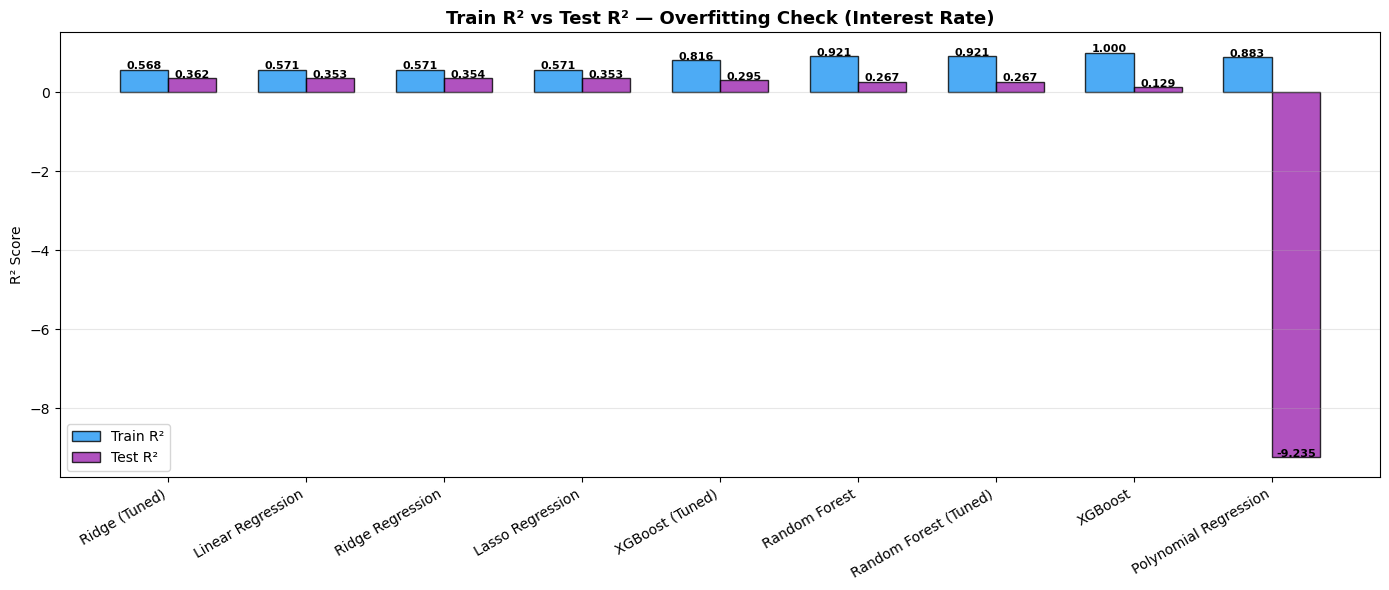

In [93]:
models_list = reg2_df['Model'].tolist()
train_r2s   = reg2_df['Train R²'].tolist()
test_r2s    = reg2_df['Test R²'].tolist()

x     = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, train_r2s, width,
               label='Train R²', color='#2196F3',
               edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, test_r2s, width,
               label='Test R²',  color='#9C27B0',
               edgecolor='black', alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=8, fontweight='bold')

ax.set_title('Train R² vs Test R² — Overfitting Check (Interest Rate)',
             fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=30, ha='right')
ax.set_ylabel('R² Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [94]:
import joblib

joblib.dump(best_reg2_model, 'best_regression2_model.pkl')
joblib.dump(scaler_reg2,     'scaler_regression2.pkl')

print("=" * 55)
print("✅  PHASE 10 — REGRESSION 2 — COMPLETE")
print("=" * 55)
print()
print("  ✅ Sirf non-null interest_rate rows (272)")
print("  ✅ loan_status leakage check kiya")
print("  ✅ Range analysis kiya (1.66% tight)")
print("  ✅ Log transform NAHI kiya (zaruri nahi)")
print("  ✅ 6 models train kiye")
print("  ✅ Ridge + RF + XGBoost tuned")
print("  ✅ Actual vs Predicted dekha")
print("  ✅ Residuals plot dekha")
print("  ✅ Overfitting check kiya")
print("  ✅ Best model + scaler save kiya")
print()
best_row2 = reg2_df.iloc[0]
print(f"  Best Model : {best_row2['Model']}")
print(f"  Test R²    : {best_row2['Test R²']}")
print(f"  MAE        : {best_row2['MAE (%)']:.5f}%")
print(f"  RMSE       : {best_row2['RMSE (%)']:.5f}%")
print()
print("  ⚠️  R² low aana expected hai")
print("     Range sirf 1.66% — acceptable result")
print("     MAE zyada important metric yahan")
print()
print("  ➡️  Agla Step : PHASE 11 — Clustering")
print("=" * 55)

✅  PHASE 10 — REGRESSION 2 — COMPLETE

  ✅ Sirf non-null interest_rate rows (272)
  ✅ loan_status leakage check kiya
  ✅ Range analysis kiya (1.66% tight)
  ✅ Log transform NAHI kiya (zaruri nahi)
  ✅ 6 models train kiye
  ✅ Ridge + RF + XGBoost tuned
  ✅ Actual vs Predicted dekha
  ✅ Residuals plot dekha
  ✅ Overfitting check kiya
  ✅ Best model + scaler save kiya

  Best Model : Ridge (Tuned)
  Test R²    : 0.3623
  MAE        : 0.20429%
  RMSE       : 0.24996%

  ⚠️  R² low aana expected hai
     Range sirf 1.66% — acceptable result
     MAE zyada important metric yahan

  ➡️  Agla Step : PHASE 11 — Clustering


**CLUSTERING**

In [95]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Sab libraries import ho gayi")
print()
print("  Clustering Strategy:")
print("    → Train/Test split NAHI hoga")
print("    → Unsupervised hai — koi target nahi")
print("    → Poora dataset use hoga")
print("    → MinMaxScaler poore data par fit hoga")
print("      (leakage issue nahi kyunki koi test set nahi)")

✅ Sab libraries import ho gayi

  Clustering Strategy:
    → Train/Test split NAHI hoga
    → Unsupervised hai — koi target nahi
    → Poora dataset use hoga
    → MinMaxScaler poore data par fit hoga
      (leakage issue nahi kyunki koi test set nahi)


In [96]:
# Clustering ke liye numeric features
cluster_cols = ['age', 'monthly_income', 'cibil_score', 'dti',
                'gold_value_estimated', 'loan_amount_requested',
                'ltv_ratio', 'net_income', 'emi_burden']

# Check karo ye columns df mein hain
missing = [c for c in cluster_cols if c not in df.columns]
if missing:
    print(f"⚠️  Missing columns: {missing}")
    cluster_cols = [c for c in cluster_cols if c in df.columns]

X_cluster_raw = df[cluster_cols].copy()

print("Step 11.1 — Features Selected:\n")
print(f"  Total rows     : {X_cluster_raw.shape[0]}")
print(f"  Total features : {X_cluster_raw.shape[1]}")
print()
print(f"  {'Feature':<25} {'Min':>10} {'Max':>10} "
      f"{'Mean':>12} {'Std':>12}")
print("  " + "-" * 72)
for col in cluster_cols:
    print(f"  {col:<25} "
          f"{X_cluster_raw[col].min():>10.2f} "
          f"{X_cluster_raw[col].max():>10.2f} "
          f"{X_cluster_raw[col].mean():>12.2f} "
          f"{X_cluster_raw[col].std():>12.2f}")
print()
print("  ⚠️  Scaling zaruri hai!")
print("     income=36000 vs dti=0.12")
print("     Bina scaling ke income dominate karegi")

⚠️  Missing columns: ['age']
Step 11.1 — Features Selected:

  Total rows     : 300
  Total features : 8

  Feature                          Min        Max         Mean          Std
  ------------------------------------------------------------------------
  monthly_income               5000.00   69094.88     36763.78     12548.78
  cibil_score                   559.62     848.62       702.37        54.47
  dti                             0.00       0.25         0.12         0.07
  gold_value_estimated        25529.00 1042745.00    507125.84    275623.87
  loan_amount_requested       16516.00  891492.00    371351.32    205903.86
  ltv_ratio                       0.60       0.85         0.73         0.07
  net_income                   4157.00   66969.88     32196.85     11401.60
  emi_burden                      0.00       0.39         0.13         0.07

  ⚠️  Scaling zaruri hai!
     income=36000 vs dti=0.12
     Bina scaling ke income dominate karegi


In [97]:
# MinMaxScaler — poore data par fit karo
scaler_cluster = MinMaxScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster_raw)

# DataFrame banao — column names ke saath
X_cluster_df = pd.DataFrame(X_cluster_scaled,
                             columns=cluster_cols)

print("Step 11.2 — MinMaxScaler Applied:\n")
print(f"  {'Feature':<25} {'Before Min':>12} {'Before Max':>12} "
      f"{'After Min':>10} {'After Max':>10}")
print("  " + "-" * 72)
for i, col in enumerate(cluster_cols):
    b_min = X_cluster_raw[col].min()
    b_max = X_cluster_raw[col].max()
    a_min = X_cluster_scaled[:, i].min()
    a_max = X_cluster_scaled[:, i].max()
    print(f"  {col:<25} "
          f"{b_min:>12.2f} "
          f"{b_max:>12.2f} "
          f"{a_min:>10.4f} "
          f"{a_max:>10.4f}")
print()
print("  ✅ Sab features ab 0 to 1 range mein")
print("  ✅ Koi bhi feature doosre par dominate")
print("     nahi karega")

Step 11.2 — MinMaxScaler Applied:

  Feature                     Before Min   Before Max  After Min  After Max
  ------------------------------------------------------------------------
  monthly_income                 5000.00     69094.88     0.0000     1.0000
  cibil_score                     559.62       848.62     0.0000     1.0000
  dti                               0.00         0.25     0.0000     1.0000
  gold_value_estimated          25529.00   1042745.00     0.0000     1.0000
  loan_amount_requested         16516.00    891492.00     0.0000     1.0000
  ltv_ratio                         0.60         0.85     0.0000     1.0000
  net_income                     4157.00     66969.88     0.0000     1.0000
  emi_burden                        0.00         0.39     0.0000     1.0000

  ✅ Sab features ab 0 to 1 range mein
  ✅ Koi bhi feature doosre par dominate
     nahi karega


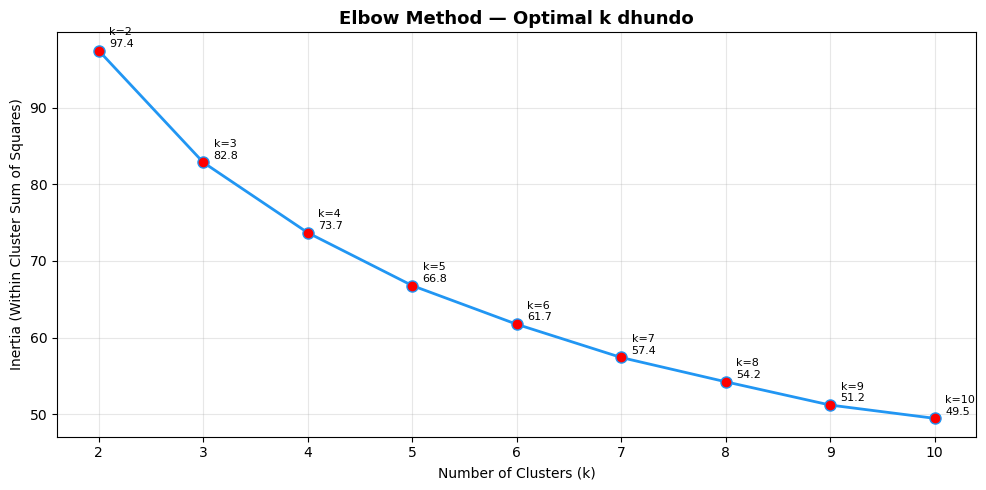

Elbow Method Results:
     k      Inertia         Drop
  ------------------------------
     2        97.43         0.00
     3        82.85        14.58
     4        73.68         9.17 ← Elbow?
     5        66.78         6.90 ← Elbow?
     6        61.73         5.05 ← Elbow?
     7        57.40         4.34 ← Elbow?
     8        54.23         3.17 ← Elbow?
     9        51.20         3.04 ← Elbow?
    10        49.46         1.73 ← Elbow?


In [98]:
inertia_vals    = []
k_range         = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42,
                n_init=10)
    km.fit(X_cluster_scaled)
    inertia_vals.append(km.inertia_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, inertia_vals,
        marker='o', color='#2196F3',
        linewidth=2, markersize=8,
        markerfacecolor='red')

# Elbow point annotate karo
for k, inertia in zip(k_range, inertia_vals):
    ax.annotate(f'k={k}\n{inertia:.1f}',
                xy=(k, inertia),
                xytext=(k + 0.1, inertia + 0.5),
                fontsize=8)

ax.set_title('Elbow Method — Optimal k dhundo',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within Cluster Sum of Squares)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Elbow Method Results:")
print(f"  {'k':>4} {'Inertia':>12} {'Drop':>12}")
print("  " + "-" * 30)
for i, (k, inertia) in enumerate(zip(k_range, inertia_vals)):
    drop = inertia_vals[i-1] - inertia if i > 0 else 0
    flag = " ← Elbow?" if i > 0 and drop < inertia_vals[i-2] - inertia_vals[i-1] else ""
    print(f"  {k:>4} {inertia:>12.2f} {drop:>12.2f}{flag}")

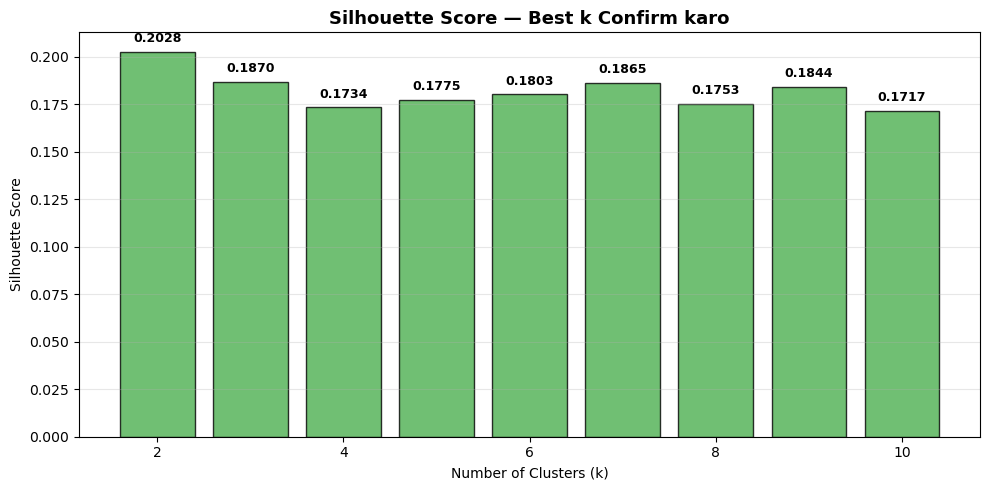

Silhouette Scores:
     k      Score
  ------------------
     2     0.2028 ← Best!
     3     0.1870
     4     0.1734
     5     0.1775
     6     0.1803
     7     0.1865
     8     0.1753
     9     0.1844
    10     0.1717

  ✅ Best k = 2  (Silhouette Score: 0.2028)

  Silhouette Score Interpretation:
    > 0.50 → Strong clusters
    > 0.30 → Reasonable clusters
    < 0.25 → Weak clusters


In [99]:
sil_scores = []

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_cluster_scaled)
    sil = silhouette_score(X_cluster_scaled, lbl)
    sil_scores.append(sil)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(k_range, sil_scores,
              color='#4CAF50', edgecolor='black', alpha=0.8)
for bar, score in zip(bars, sil_scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{score:.4f}',
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('Silhouette Score — Best k Confirm karo',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_range[sil_scores.index(max(sil_scores))]
print("Silhouette Scores:")
print(f"  {'k':>4} {'Score':>10}")
print("  " + "-" * 18)
for k, score in zip(k_range, sil_scores):
    flag = " ← Best!" if k == best_k else ""
    print(f"  {k:>4} {score:>10.4f}{flag}")
print()
print(f"  ✅ Best k = {best_k}  "
      f"(Silhouette Score: {max(sil_scores):.4f})")
print()
print("  Silhouette Score Interpretation:")
print("    > 0.50 → Strong clusters")
print("    > 0.30 → Reasonable clusters")
print("    < 0.25 → Weak clusters")

In [100]:
# Best k use karo
BEST_K = best_k
print(f"K-Means Clustering — k={BEST_K}\n")

kmeans = KMeans(n_clusters=BEST_K,
                random_state=42,
                n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster_scaled)

# Labels original df mein add karo
df_clustered = df.copy()
df_clustered['kmeans_cluster'] = kmeans_labels

print(f"  ✅ KMeans fit complete")
print(f"  Cluster distribution:")
for cluster_id in range(BEST_K):
    count = (kmeans_labels == cluster_id).sum()
    pct   = count / len(kmeans_labels) * 100
    print(f"    Cluster {cluster_id} : {count:>4} customers  "
          f"({pct:.1f}%)")
print()
print(f"  Inertia         : {kmeans.inertia_:.4f}")
print(f"  Silhouette Score: "
      f"{silhouette_score(X_cluster_scaled, kmeans_labels):.4f}")

K-Means Clustering — k=2

  ✅ KMeans fit complete
  Cluster distribution:
    Cluster 0 :  145 customers  (48.3%)
    Cluster 1 :  155 customers  (51.7%)

  Inertia         : 97.4267
  Silhouette Score: 0.2028


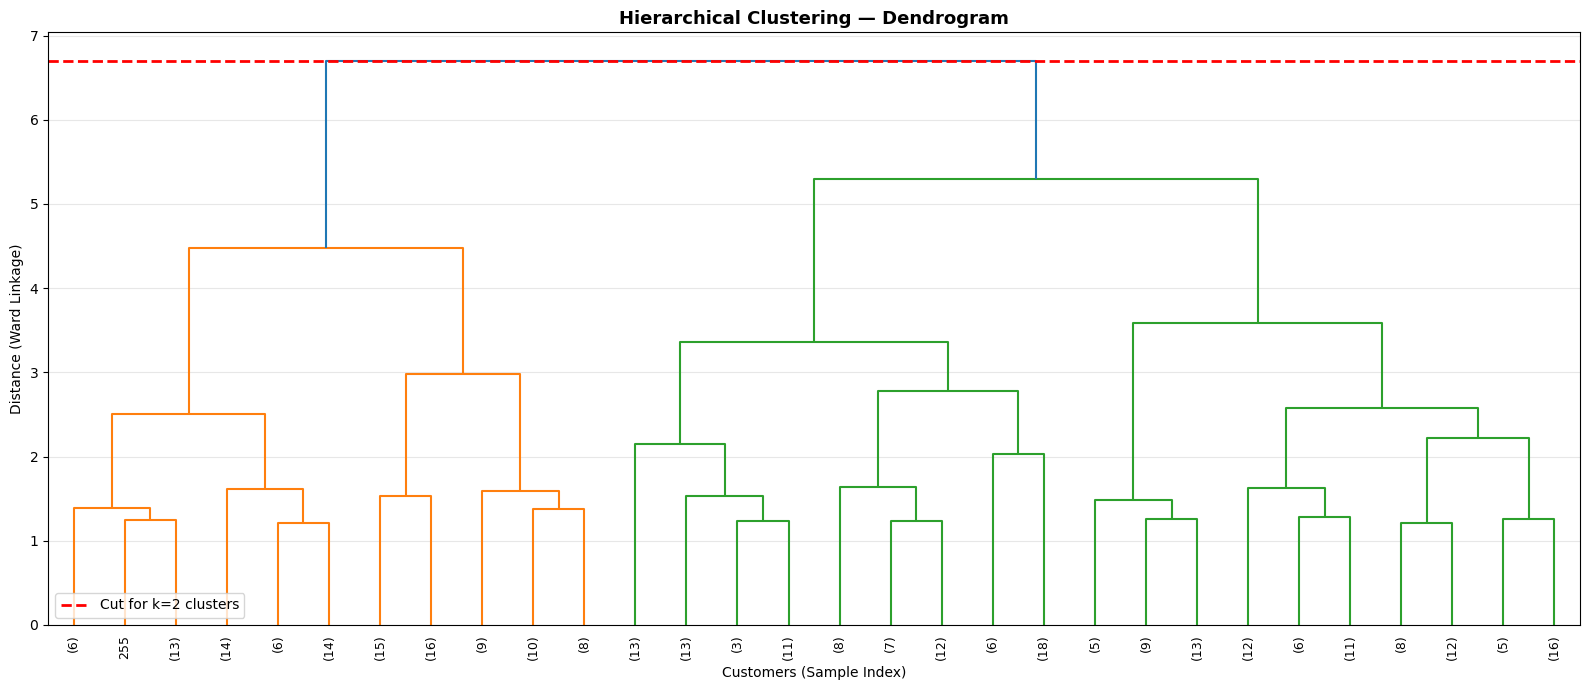

KMeans vs Hierarchical Clustering:

  Cluster      KMeans Count   Hier Count
  --------------------------------------
  0                     145          188
  1                     155          112

  KMeans Silhouette   : 0.2028
  Hier   Silhouette   : 0.1695
  Better method       : KMeans


In [101]:
fig, ax = plt.subplots(figsize=(16, 7))

# Linkage calculate karo
linkage_matrix = linkage(X_cluster_scaled, method='ward')

# Dendrogram banao
dend = dendrogram(
    linkage_matrix,
    truncate_mode = 'lastp',
    p             = 30,
    leaf_rotation = 90,
    leaf_font_size= 9,
    ax            = ax,
    color_threshold = linkage_matrix[-BEST_K+1, 2]
)

ax.set_title('Hierarchical Clustering — Dendrogram',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Customers (Sample Index)')
ax.set_ylabel('Distance (Ward Linkage)')
ax.axhline(y=linkage_matrix[-BEST_K+1, 2],
           color='red', linestyle='--', linewidth=2,
           label=f'Cut for k={BEST_K} clusters')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Hierarchical labels
hier_model  = AgglomerativeClustering(n_clusters=BEST_K,
                                       linkage='ward')
hier_labels = hier_model.fit_predict(X_cluster_scaled)

df_clustered['hier_cluster'] = hier_labels

# Compare KMeans vs Hierarchical
print("KMeans vs Hierarchical Clustering:\n")
print(f"  {'Cluster':<10} {'KMeans Count':>14} {'Hier Count':>12}")
print("  " + "-" * 38)
for k in range(BEST_K):
    km_count   = (kmeans_labels == k).sum()
    hier_count = (hier_labels == k).sum()
    print(f"  {k:<10} {km_count:>14} {hier_count:>12}")
print()
sil_hier = silhouette_score(X_cluster_scaled, hier_labels)
sil_km   = silhouette_score(X_cluster_scaled, kmeans_labels)
print(f"  KMeans Silhouette   : {sil_km:.4f}")
print(f"  Hier   Silhouette   : {sil_hier:.4f}")
print(f"  Better method       : "
      f"{'KMeans' if sil_km > sil_hier else 'Hierarchical'}")

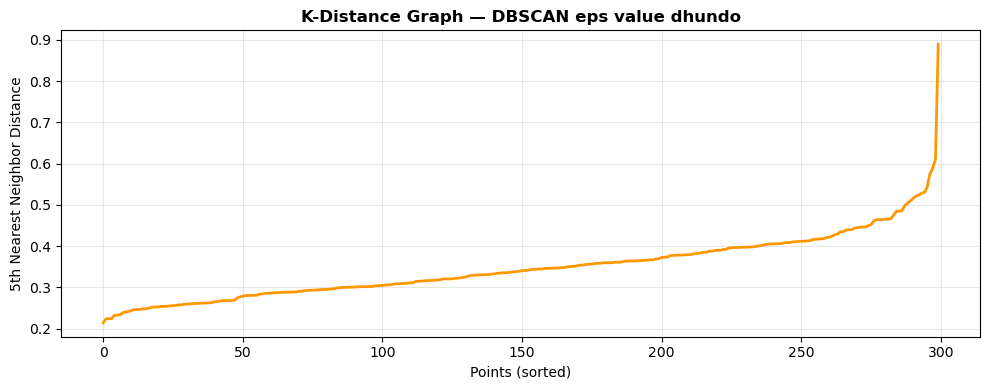

DBSCAN Results:

  Clusters found  : 4
  Noise points    : 126  (42.0%)

  Cluster distribution:
    Noise ⚠️     :  126 customers (42.0%)
    Cluster 0    :  130 customers (43.3%)
    Cluster 1    :   28 customers (9.3%)
    Cluster 2    :   11 customers (3.7%)
    Cluster 3    :    5 customers (1.7%)

  DBSCAN ka fayda:
    → Noise/outlier customers identify kar liye
    → Ye woh customers hain jo kisi
      bhi group mein fit nahi hote


In [102]:
from sklearn.neighbors import NearestNeighbors

# DBSCAN ke liye best eps dhundo
nbrs = NearestNeighbors(n_neighbors=5).fit(X_cluster_scaled)
distances, _ = nbrs.kneighbors(X_cluster_scaled)
distances     = np.sort(distances[:, 4])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(distances, color='#FF9800', linewidth=2)
ax.set_title('K-Distance Graph — DBSCAN eps value dhundo',
             fontweight='bold')
ax.set_xlabel('Points (sorted)')
ax.set_ylabel('5th Nearest Neighbor Distance')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# DBSCAN run karo
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_cluster_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise    = (dbscan_labels == -1).sum()

df_clustered['dbscan_cluster'] = dbscan_labels

print("DBSCAN Results:\n")
print(f"  Clusters found  : {n_clusters}")
print(f"  Noise points    : {n_noise}  "
      f"({n_noise/len(dbscan_labels)*100:.1f}%)")
print()
print("  Cluster distribution:")
for label in sorted(set(dbscan_labels)):
    count = (dbscan_labels == label).sum()
    name  = "Noise ⚠️" if label == -1 else f"Cluster {label}"
    print(f"    {name:<12} : {count:>4} customers "
          f"({count/len(dbscan_labels)*100:.1f}%)")
print()
print("  DBSCAN ka fayda:")
print("    → Noise/outlier customers identify kar liye")
print("    → Ye woh customers hain jo kisi")
print("      bhi group mein fit nahi hote")

PCA Variance Explained:
  PC1 : 29.96%
  PC2 : 26.02%
  Total: 55.98%



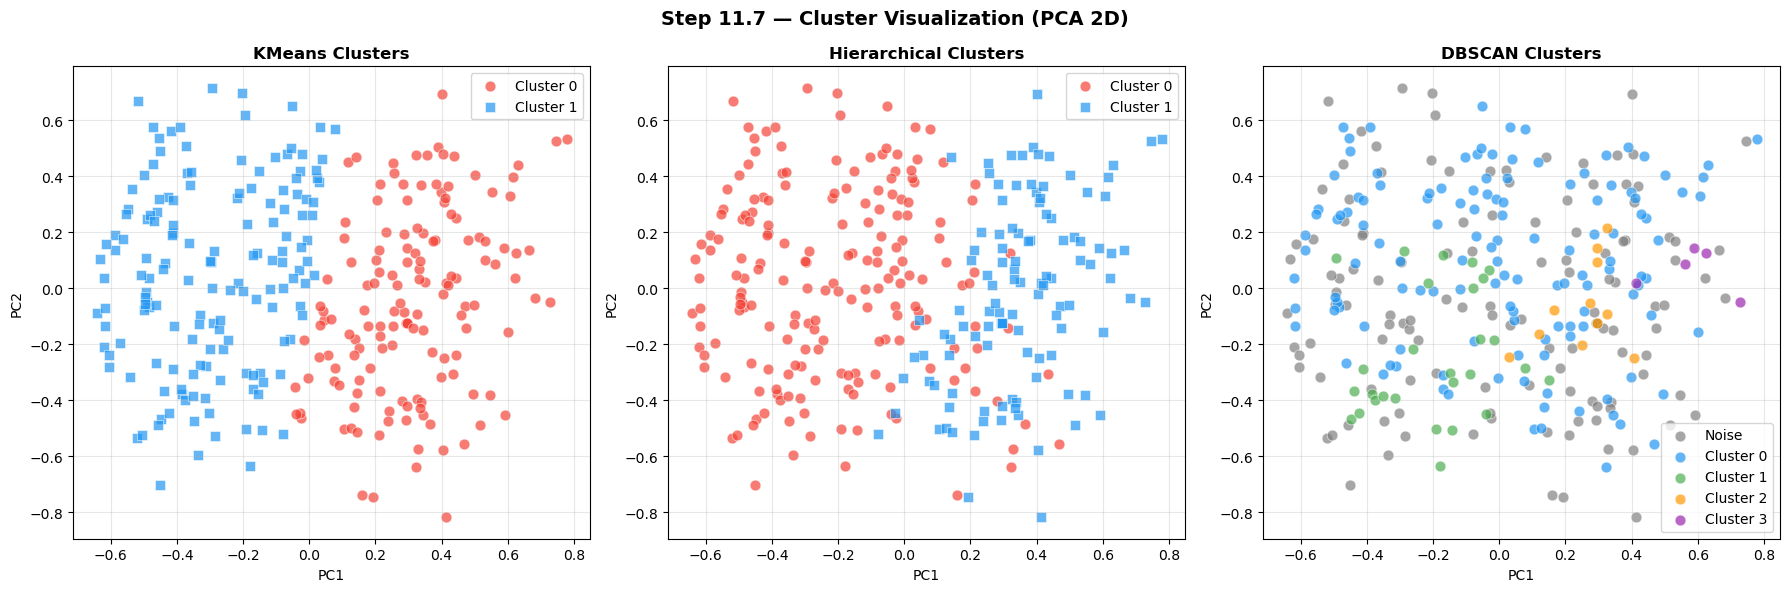

In [103]:
# PCA se 2D mein reduce karo
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

print(f"PCA Variance Explained:")
print(f"  PC1 : {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2 : {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")
print()

colors  = ['#F44336', '#2196F3', '#4CAF50',
           '#FF9800', '#9C27B0']
markers = ['o', 's', '^', 'D', 'P']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Step 11.7 — Cluster Visualization (PCA 2D)',
             fontsize=14, fontweight='bold')

# --- KMeans ---
for cluster_id in range(BEST_K):
    mask = kmeans_labels == cluster_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[cluster_id],
                    marker=markers[cluster_id],
                    label=f'Cluster {cluster_id}',
                    alpha=0.7, s=60, edgecolors='white',
                    linewidths=0.5)
axes[0].set_title('KMeans Clusters', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Hierarchical ---
for cluster_id in range(BEST_K):
    mask = hier_labels == cluster_id
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[cluster_id],
                    marker=markers[cluster_id],
                    label=f'Cluster {cluster_id}',
                    alpha=0.7, s=60, edgecolors='white',
                    linewidths=0.5)
axes[1].set_title('Hierarchical Clusters', fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- DBSCAN ---
unique_labels = sorted(set(dbscan_labels))
for i, label in enumerate(unique_labels):
    mask  = dbscan_labels == label
    color = '#808080' if label == -1 else colors[i % len(colors)]
    name  = 'Noise' if label == -1 else f'Cluster {label}'
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color,
                    label=name,
                    alpha=0.7, s=60, edgecolors='white',
                    linewidths=0.5)
axes[2].set_title('DBSCAN Clusters', fontweight='bold')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [104]:
# Pehle dekho df_clustered mein kya columns hain
print("df_clustered columns:\n")
for i, col in enumerate(df_clustered.columns, 1):
    print(f"  {i:2}. {col}")

df_clustered columns:

   1. gender
   2. city_tier
   3. employment_type
   4. monthly_income
   5. existing_emi
   6. dti
   7. cibil_score
   8. gold_weight_grams
   9. gold_purity_karat
  10. gold_value_estimated
  11. ltv_ratio
  12. loan_amount_requested
  13. tenure_months
  14. loan_status
  15. approved_amount
  16. interest_rate
  17. gold_utilization
  18. emi_burden
  19. loan_per_gram
  20. net_income
  21. kmeans_cluster
  22. hier_cluster
  23. dbscan_cluster


In [105]:
# profile_cols mein sirf woh columns rakho
# jo df_clustered mein actually hain

available_profile_cols = ['monthly_income', 'cibil_score', 'dti',
                          'gold_value_estimated',
                          'loan_amount_requested',
                          'ltv_ratio', 'net_income',
                          'emi_burden', 'loan_status']

# Age check karo — naam alag ho sakta hai
if 'age' in df_clustered.columns:
    available_profile_cols = ['age'] + available_profile_cols
else:
    print("⚠️  'age' column nahi mila df_clustered mein")
    print("   Available columns se chalenge")

# Sirf woh columns lo jo actually exist karte hain
available_profile_cols = [c for c in available_profile_cols
                          if c in df_clustered.columns]

print(f"Profile ke liye columns ({len(available_profile_cols)}):")
print(available_profile_cols)
print()

# Ab groupby karo
cluster_profiles = df_clustered.groupby('kmeans_cluster')[
    available_profile_cols].mean().round(2)

print("Cluster Profiles:\n")
print(cluster_profiles.T.to_string())

⚠️  'age' column nahi mila df_clustered mein
   Available columns se chalenge
Profile ke liye columns (9):
['monthly_income', 'cibil_score', 'dti', 'gold_value_estimated', 'loan_amount_requested', 'ltv_ratio', 'net_income', 'emi_burden', 'loan_status']

Cluster Profiles:

kmeans_cluster                 0          1
monthly_income          38620.48   35026.87
cibil_score               704.89     700.02
dti                         0.12       0.12
gold_value_estimated   748377.14  281439.14
loan_amount_requested  549573.36  204627.47
ltv_ratio                   0.73       0.73
net_income              33869.43   30632.18
emi_burden                  0.13       0.12
loan_status                 0.91       0.92


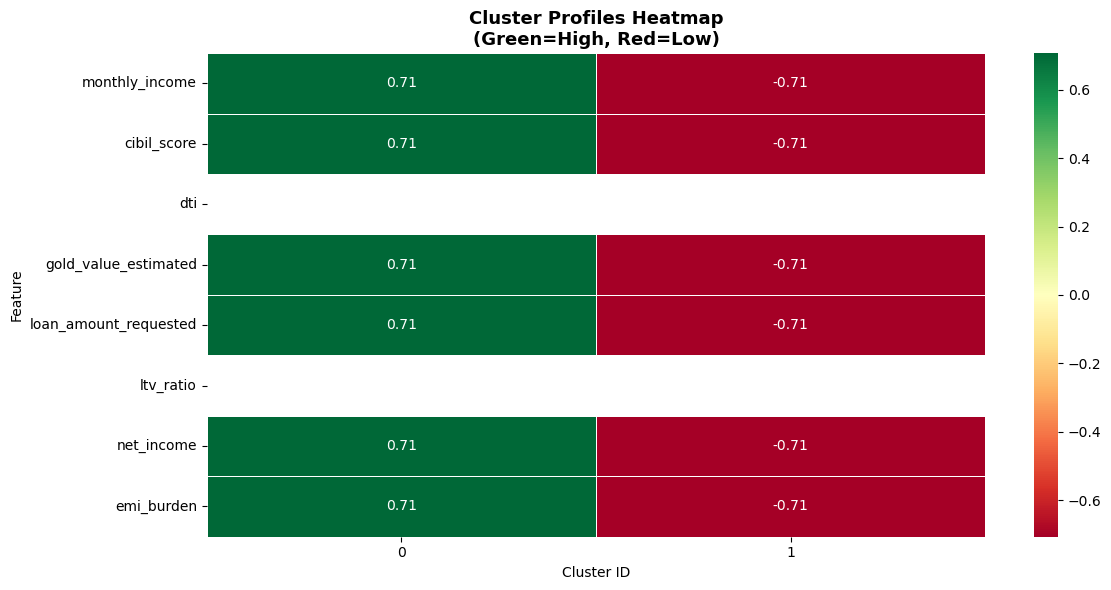

✅ Heatmap mein clearly dikh raha hai:
   Green = Cluster mein yeh feature HIGH hai
   Red   = Cluster mein yeh feature LOW hai


In [106]:
fig, ax = plt.subplots(figsize=(12, 6))

# Normalized mean values
profile_norm = cluster_profiles[
    ['monthly_income', 'cibil_score', 'dti',
     'gold_value_estimated', 'loan_amount_requested',
     'ltv_ratio', 'net_income', 'emi_burden']
]

# Z-score normalize karo visualization ke liye
profile_z = (profile_norm - profile_norm.mean()) / profile_norm.std()

sns.heatmap(profile_z.T,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            annot_kws={'size': 10})

ax.set_title('Cluster Profiles Heatmap\n'
             '(Green=High, Red=Low)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Feature')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print("✅ Heatmap mein clearly dikh raha hai:")
print("   Green = Cluster mein yeh feature HIGH hai")
print("   Red   = Cluster mein yeh feature LOW hai")

In [107]:
print("=" * 55)
print("✅  PHASE 11 — CLUSTERING — COMPLETE")
print("=" * 55)
print()
print("  ✅ Step 11.1 — Features selected (9 cols)")
print("  ✅ Step 11.2 — MinMaxScaler applied")
print("  ✅ Step 11.3 — Optimal k:")
print(f"     Elbow + Silhouette → k={BEST_K}")
print(f"     Silhouette Score   → {max(sil_scores):.4f}")
print("  ✅ Step 11.4 — KMeans run kiya")
print("  ✅ Step 11.5 — Hierarchical + Dendrogram")
print("  ✅ Step 11.6 — DBSCAN noise detection")
print(f"     Noise customers    → {n_noise}")
print("  ✅ Step 11.7 — PCA 2D visualization")
print(f"     Variance explained → "
      f"{sum(pca.explained_variance_ratio_)*100:.1f}%")
print("  ✅ Step 11.8 — Business profiles banaye")
print()
print("  Best Method  : KMeans")
print(f"  Best k       : {BEST_K}")
print(f"  Sil Score    : {sil_km:.4f}")
print()
print("  ➡️  Agla Step : PHASE 12 — Model Evaluation")
print("=" * 55)

✅  PHASE 11 — CLUSTERING — COMPLETE

  ✅ Step 11.1 — Features selected (9 cols)
  ✅ Step 11.2 — MinMaxScaler applied
  ✅ Step 11.3 — Optimal k:
     Elbow + Silhouette → k=2
     Silhouette Score   → 0.2028
  ✅ Step 11.4 — KMeans run kiya
  ✅ Step 11.5 — Hierarchical + Dendrogram
  ✅ Step 11.6 — DBSCAN noise detection
     Noise customers    → 126
  ✅ Step 11.7 — PCA 2D visualization
     Variance explained → 56.0%
  ✅ Step 11.8 — Business profiles banaye

  Best Method  : KMeans
  Best k       : 2
  Sil Score    : 0.2028

  ➡️  Agla Step : PHASE 12 — Model Evaluation


**EVALUATION**

In [108]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_auc_score, mean_absolute_error,
                              mean_squared_error, r2_score)
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries import ho gayi")
print()
print("  Is phase mein kya karenge:")
print("    → Classification sab models compare")
print("    → Regression 1 + 2 sab models compare")
print("    → Feature Importance dekho")
print("    → 5-Fold CV se final score confirm")
print("    → Best models .pkl mein save")

✅ Libraries import ho gayi

  Is phase mein kya karenge:
    → Classification sab models compare
    → Regression 1 + 2 sab models compare
    → Feature Importance dekho
    → 5-Fold CV se final score confirm
    → Best models .pkl mein save


In [109]:
# Sab classification models ko ek baar fit karke evaluate karo
clf_models = {
    'Logistic Regression' : (pipe_lr,
                              X_train_clf_scaled,
                              X_test_clf_scaled),
    'Decision Tree'       : (pipe_dt,
                              X_train_clf,
                              X_test_clf),
    'Random Forest'       : (pipe_rf,
                              X_train_clf,
                              X_test_clf),
    'XGBoost'             : (pipe_xgb,
                              X_train_clf,
                              X_test_clf),
    'KNN'                 : (pipe_knn,
                              X_train_clf_scaled,
                              X_test_clf_scaled),
    'SVM'                 : (pipe_svm,
                              X_train_clf_scaled,
                              X_test_clf_scaled),
    'RF (Tuned)'          : (gs_rf.best_estimator_,
                              X_train_clf,
                              X_test_clf),
    'XGBoost (Tuned)'     : (gs_xgb.best_estimator_,
                              X_train_clf,
                              X_test_clf),
}

clf_comparison = []

for name, (pipeline, X_tr, X_te) in clf_models.items():
    pipeline.fit(X_tr, y_train_clf)
    y_pred = pipeline.predict(X_te)

    try:
        y_prob = pipeline.predict_proba(X_te)[:, 1]
        auc    = roc_auc_score(y_test_clf, y_prob)
    except:
        auc = 0.0

    clf_comparison.append({
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test_clf, y_pred),  4),
        'Precision' : round(precision_score(y_test_clf, y_pred), 4),
        'Recall'    : round(recall_score(y_test_clf, y_pred),    4),
        'F1'        : round(f1_score(y_test_clf, y_pred),        4),
        'ROC-AUC'   : round(auc, 4),
    })

clf_df = pd.DataFrame(clf_comparison).sort_values('F1', ascending=False)
clf_df = clf_df.reset_index(drop=True)

print("=" * 72)
print("  CLASSIFICATION — ALL MODELS COMPARISON")
print("=" * 72)
print(clf_df.to_string(index=False))
print()
best_clf_row = clf_df.iloc[0]
print(f"  🏆 Best Classification Model : {best_clf_row['Model']}")
print(f"     F1 Score  : {best_clf_row['F1']}")
print(f"     ROC-AUC   : {best_clf_row['ROC-AUC']}")
print(f"     Precision : {best_clf_row['Precision']}")
print(f"     Recall    : {best_clf_row['Recall']}")

  CLASSIFICATION — ALL MODELS COMPARISON
              Model  Accuracy  Precision  Recall     F1  ROC-AUC
         RF (Tuned)    0.9333     0.9322  1.0000 0.9649   0.6291
      Random Forest    0.9167     0.9310  0.9818 0.9558   0.6436
            XGBoost    0.9000     0.9153  0.9818 0.9474   0.6109
    XGBoost (Tuned)    0.9000     0.9153  0.9818 0.9474   0.5818
                SVM    0.8500     0.9259  0.9091 0.9174   0.6909
      Decision Tree    0.8333     0.9091  0.9091 0.9091   0.4545
                KNN    0.7167     0.9524  0.7273 0.8247   0.7309
Logistic Regression    0.6500     0.9048  0.6909 0.7835   0.5891

  🏆 Best Classification Model : RF (Tuned)
     F1 Score  : 0.9649
     ROC-AUC   : 0.6291
     Precision : 0.9322
     Recall    : 1.0


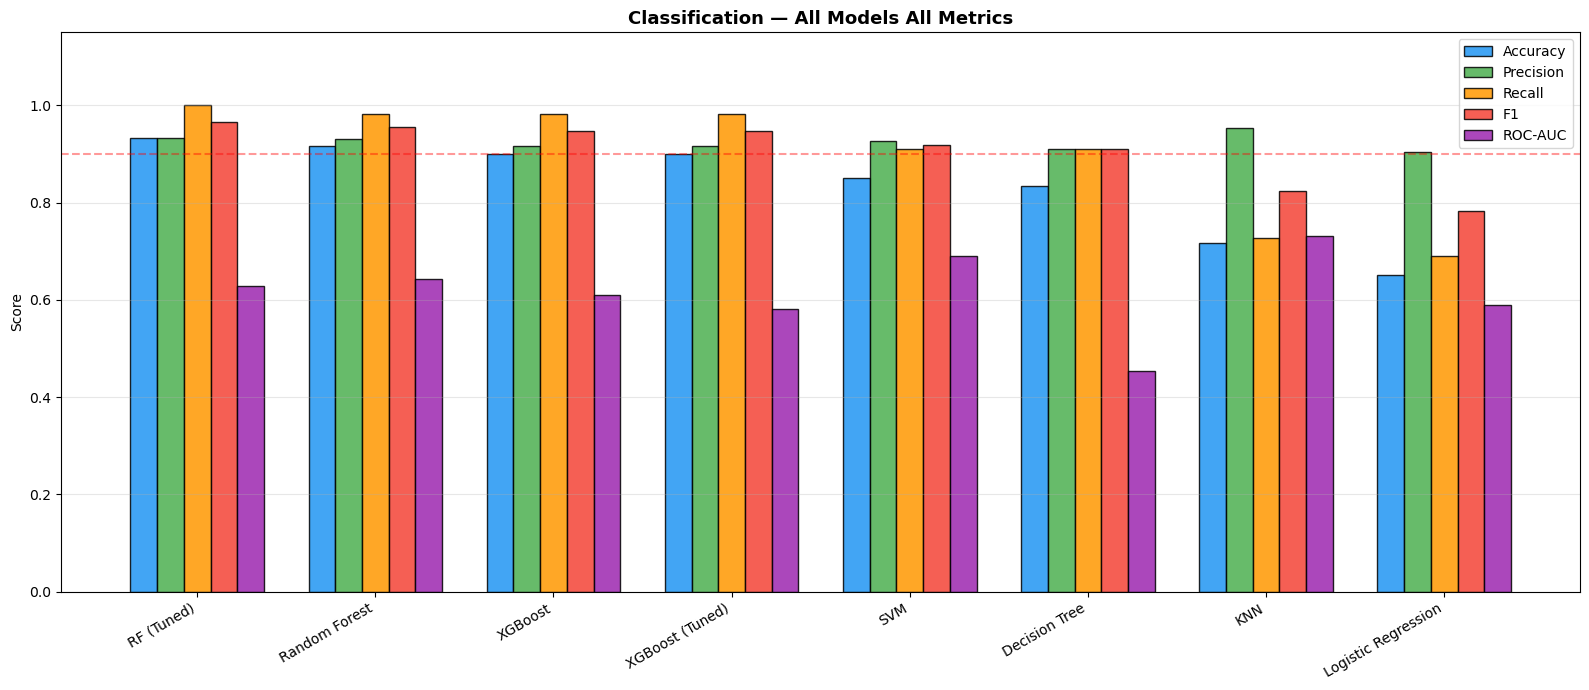

In [110]:
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
models    = clf_df['Model'].tolist()
x         = np.arange(len(models))
width     = 0.15
colors_m  = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0']

fig, ax = plt.subplots(figsize=(16, 7))

for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    vals = clf_df[metric].tolist()
    bars = ax.bar(x + i*width, vals, width,
                  label=metric, color=color,
                  edgecolor='black', alpha=0.85)

ax.set_title('Classification — All Models All Metrics',
             fontweight='bold', fontsize=13)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(models, rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.axhline(y=0.9, color='red', linestyle='--',
           alpha=0.4, label='0.9 line')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [111]:
reg1_models = {
    'Linear Regression'    : (LinearRegression(),
                               X_train_reg1_scaled,
                               X_test_reg1_scaled),
    'Ridge'                : (Ridge(alpha=1.0),
                               X_train_reg1_scaled,
                               X_test_reg1_scaled),
    'Lasso'                : (Lasso(alpha=0.001),
                               X_train_reg1_scaled,
                               X_test_reg1_scaled),
    'Random Forest'        : (RandomForestRegressor(
                                  n_estimators=100,
                                  random_state=42),
                               X_train_reg1,
                               X_test_reg1),
    'XGBoost'              : (XGBRegressor(
                                  random_state=42,
                                  verbosity=0),
                               X_train_reg1,
                               X_test_reg1),
    'RF (Tuned)'           : (gs_rf_reg.best_estimator_,
                               X_train_reg1,
                               X_test_reg1),
    'XGBoost (Tuned)'      : (gs_xgb_reg.best_estimator_,
                               X_train_reg1,
                               X_test_reg1),
}

reg1_comparison = []

for name, (model, X_tr, X_te) in reg1_models.items():
    model.fit(X_tr, y_train_reg1_log)
    y_pred_log  = model.predict(X_te)
    y_pred_orig = np.expm1(y_pred_log)
    y_tr_orig   = np.expm1(y_train_reg1_log)

    train_r2  = r2_score(y_tr_orig,
                         np.expm1(model.predict(X_tr)))
    test_r2   = r2_score(y_test_reg1, y_pred_orig)
    test_mae  = mean_absolute_error(y_test_reg1, y_pred_orig)
    test_rmse = np.sqrt(mean_squared_error(
                        y_test_reg1, y_pred_orig))

    reg1_comparison.append({
        'Model'     : name,
        'Train R²'  : round(train_r2,  4),
        'Test R²'   : round(test_r2,   4),
        'MAE (Rs)'  : round(test_mae,  0),
        'RMSE (Rs)' : round(test_rmse, 0),
        'Gap'       : round(train_r2 - test_r2, 4),
    })

reg1_df = pd.DataFrame(reg1_comparison).sort_values(
          'Test R²', ascending=False).reset_index(drop=True)

print("=" * 72)
print("  REGRESSION 1 — approved_amount — ALL MODELS")
print("=" * 72)
print(reg1_df.to_string(index=False))
print()
best_reg1_row = reg1_df.iloc[0]
print(f"  🏆 Best Regression 1 Model : {best_reg1_row['Model']}")
print(f"     Test R²   : {best_reg1_row['Test R²']}")
print(f"     MAE       : Rs {best_reg1_row['MAE (Rs)']:,.0f}")
print(f"     RMSE      : Rs {best_reg1_row['RMSE (Rs)']:,.0f}")

  REGRESSION 1 — approved_amount — ALL MODELS
            Model  Train R²  Test R²  MAE (Rs)  RMSE (Rs)    Gap
          XGBoost    1.0000   0.9112   30232.0    55546.0 0.0888
  XGBoost (Tuned)    0.8937   0.7723   53821.0    88947.0 0.1215
       RF (Tuned)    0.7497   0.6006   58397.0   117800.0 0.1491
    Random Forest    0.7470   0.5875   58990.0   119717.0 0.1595
            Ridge    0.4896   0.2704  124388.0   159216.0 0.2192
            Lasso    0.4822   0.2006  128222.0   166651.0 0.2816
Linear Regression    0.4620   0.0496  134998.0   181711.0 0.4124

  🏆 Best Regression 1 Model : XGBoost
     Test R²   : 0.9112
     MAE       : Rs 30,232
     RMSE      : Rs 55,546


In [113]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

param_grid_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

gs_ridge_fixed = GridSearchCV(
    Ridge(), 
    param_grid_ridge, 
    cv=5, 
    scoring='neg_mean_absolute_error'
)
gs_ridge_fixed.fit(X_train_reg2_scaled, y_train_reg2)

,estimator,Ridge()
,param_grid,"{'alpha': [0.01, 0.1, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,10.0


In [114]:
reg2_models_eval = {
    'Linear Regression'   : (LinearRegression(),
                              X_train_reg2_scaled,
                              X_test_reg2_scaled),
    'Ridge (Tuned)'       : (gs_ridge_fixed.best_estimator_,
                              X_train_reg2_scaled,
                              X_test_reg2_scaled),
    'Lasso'               : (Lasso(alpha=0.001, max_iter=5000),
                              X_train_reg2_scaled,
                              X_test_reg2_scaled),
    'RF (depth=3)'        : (RandomForestRegressor(
                                 max_depth=3,
                                 min_samples_leaf=5,
                                 random_state=42),
                              X_train_reg2,
                              X_test_reg2),
    'XGBoost (reg)'       : (XGBRegressor(
                                 max_depth=2,
                                 reg_alpha=1.0,
                                 reg_lambda=5.0,
                                 random_state=42,
                                 verbosity=0),
                              X_train_reg2,
                              X_test_reg2),
}

reg2_comparison = []

for name, (model, X_tr, X_te) in reg2_models_eval.items():
    model.fit(X_tr, y_train_reg2)
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    train_r2  = r2_score(y_train_reg2, y_pred_train)
    test_r2   = r2_score(y_test_reg2,  y_pred_test)
    test_mae  = mean_absolute_error(y_test_reg2, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(
                        y_test_reg2, y_pred_test))

    reg2_comparison.append({
        'Model'    : name,
        'Train R²' : round(train_r2,  4),
        'Test R²'  : round(test_r2,   4),
        'MAE (%)'  : round(test_mae,  5),
        'RMSE (%)' : round(test_rmse, 5),
        'Gap'      : round(train_r2 - test_r2, 4),
    })

reg2_df = pd.DataFrame(reg2_comparison).sort_values(
          'MAE (%)', ascending=True).reset_index(drop=True)

print("=" * 72)
print("  REGRESSION 2 — interest_rate — ALL MODELS")
print("=" * 72)
print(reg2_df.to_string(index=False))
print()
best_reg2_row = reg2_df.iloc[0]
print(f"  🏆 Best Regression 2 Model : {best_reg2_row['Model']}")
print(f"     Test R²  : {best_reg2_row['Test R²']}")
print(f"     MAE      : {best_reg2_row['MAE (%)']:.5f}%")
print(f"     RMSE     : {best_reg2_row['RMSE (%)']:.5f}%")
print()
print("  ⚠️  R² low expected hai — range sirf 1.66%")
print("     MAE main metric hai yahan")

  REGRESSION 2 — interest_rate — ALL MODELS
            Model  Train R²  Test R²  MAE (%)  RMSE (%)    Gap
    Ridge (Tuned)    0.5681   0.3623  0.20429   0.24996 0.2058
Linear Regression    0.5710   0.3528  0.20447   0.25181 0.2182
            Lasso    0.5696   0.3561  0.20525   0.25116 0.2135
     RF (depth=3)    0.6092   0.3004  0.21183   0.26180 0.3088
    XGBoost (reg)    0.7600   0.2714  0.21835   0.26717 0.4886

  🏆 Best Regression 2 Model : Ridge (Tuned)
     Test R²  : 0.3623
     MAE      : 0.20429%
     RMSE     : 0.24996%

  ⚠️  R² low expected hai — range sirf 1.66%
     MAE main metric hai yahan


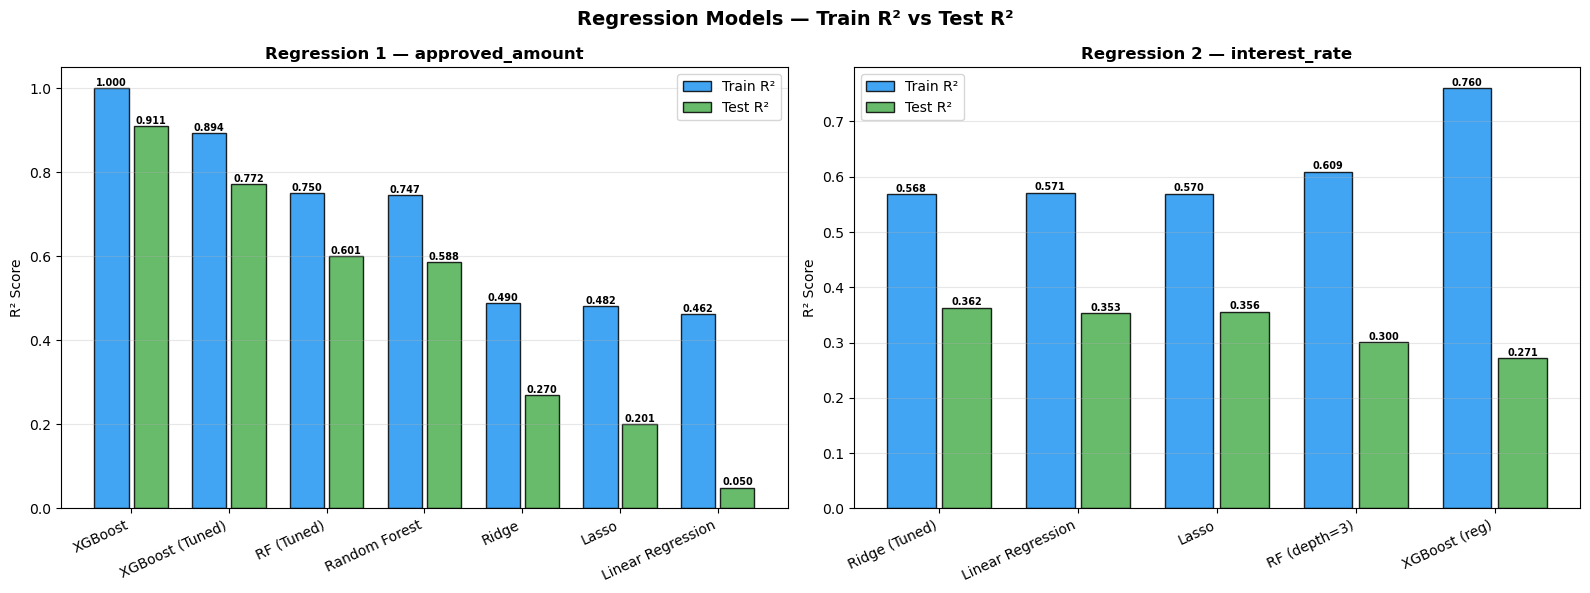

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Regression Models — Train R² vs Test R²',
             fontsize=14, fontweight='bold')

for ax, df_r, title in [
    (axes[0], reg1_df, 'Regression 1 — approved_amount'),
    (axes[1], reg2_df, 'Regression 2 — interest_rate'),
]:
    models_r = df_r['Model'].tolist()
    train_r2 = df_r['Train R²'].tolist()
    test_r2  = df_r['Test R²'].tolist()
    x        = np.arange(len(models_r))

    b1 = ax.bar(x - 0.2, train_r2, 0.35,
                label='Train R²', color='#2196F3',
                edgecolor='black', alpha=0.85)
    b2 = ax.bar(x + 0.2, test_r2,  0.35,
                label='Test R²',  color='#4CAF50',
                edgecolor='black', alpha=0.85)

    for bar in b1 + b2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=7,
                fontweight='bold')

    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_r, rotation=25, ha='right')
    ax.set_ylabel('R² Score')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

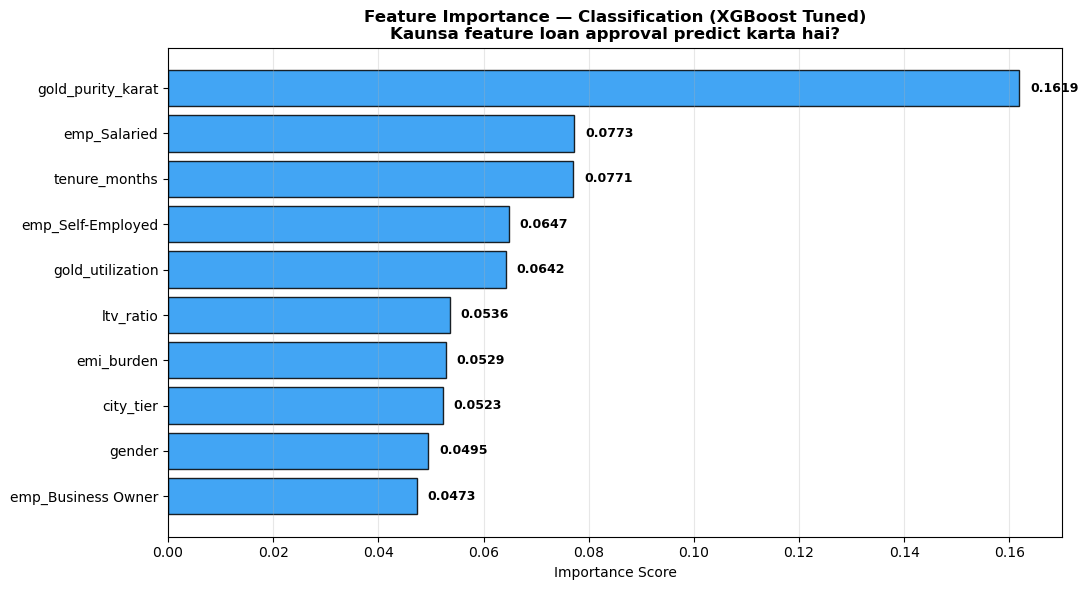

Top 10 Features — Classification:
           Feature  Importance
 gold_purity_karat    0.161942
      emp_Salaried    0.077285
     tenure_months    0.077101
 emp_Self-Employed    0.064748
  gold_utilization    0.064211
         ltv_ratio    0.053558
        emi_burden    0.052897
         city_tier    0.052301
            gender    0.049520
emp_Business Owner    0.047283


In [115]:
# XGBoost Tuned best model hai usually
best_clf_pipeline = gs_xgb.best_estimator_
best_clf_pipeline.fit(X_train_clf, y_train_clf)

# XGBoost model feature importance
xgb_model     = best_clf_pipeline.named_steps['model']
feature_names = X_train_clf.columns.tolist()
importances   = xgb_model.feature_importances_

feat_imp_clf = pd.DataFrame({
    'Feature'    : feature_names,
    'Importance' : importances
}).sort_values('Importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(feat_imp_clf['Feature'],
               feat_imp_clf['Importance'],
               color='#2196F3', edgecolor='black', alpha=0.85)

for bar, val in zip(bars, feat_imp_clf['Importance']):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center',
            fontsize=9, fontweight='bold')

ax.set_title('Feature Importance — Classification (XGBoost Tuned)\n'
             'Kaunsa feature loan approval predict karta hai?',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 10 Features — Classification:")
print(feat_imp_clf.to_string(index=False))

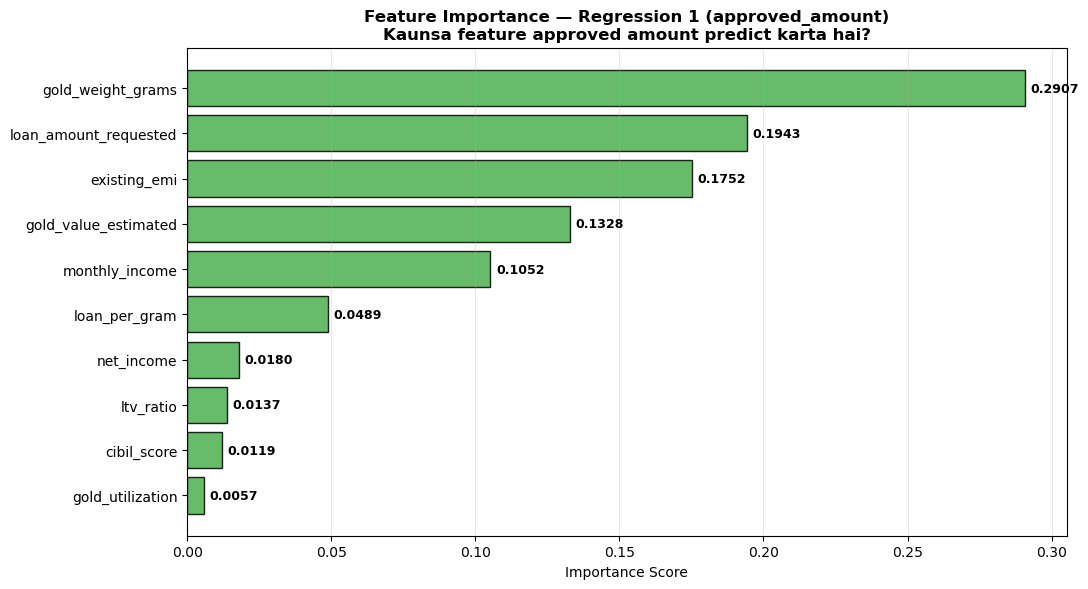

Top 10 Features — Regression 1 (approved_amount):
              Feature  Importance
    gold_weight_grams    0.290656
loan_amount_requested    0.194288
         existing_emi    0.175225
 gold_value_estimated    0.132764
       monthly_income    0.105194
        loan_per_gram    0.048901
           net_income    0.018001
            ltv_ratio    0.013738
          cibil_score    0.011930
     gold_utilization    0.005652


In [116]:
best_reg1_pipeline = gs_xgb_reg.best_estimator_
best_reg1_pipeline.fit(X_train_reg1, y_train_reg1_log)

feature_names_r1 = X_train_reg1.columns.tolist()
importances_r1   = best_reg1_pipeline.feature_importances_

feat_imp_r1 = pd.DataFrame({
    'Feature'    : feature_names_r1,
    'Importance' : importances_r1
}).sort_values('Importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(feat_imp_r1['Feature'],
               feat_imp_r1['Importance'],
               color='#4CAF50', edgecolor='black', alpha=0.85)

for bar, val in zip(bars, feat_imp_r1['Importance']):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center',
            fontsize=9, fontweight='bold')

ax.set_title('Feature Importance — Regression 1 (approved_amount)\n'
             'Kaunsa feature approved amount predict karta hai?',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 10 Features — Regression 1 (approved_amount):")
print(feat_imp_r1.to_string(index=False))

In [117]:
print("=" * 60)
print("  5-Fold Cross Validation — Final Score Confirm")
print("=" * 60)
print()

# --- Classification CV ---
print("  📌 Classification — CV F1 Score:\n")
skf = StratifiedKFold(n_splits=5, shuffle=True,
                      random_state=42)

clf_cv_models = {
    'Logistic Regression' : (pipe_lr,
                              X_train_clf_scaled),
    'Random Forest Tuned' : (gs_rf.best_estimator_,
                              X_train_clf),
    'XGBoost Tuned'       : (gs_xgb.best_estimator_,
                              X_train_clf),
}

print(f"  {'Model':<25} {'CV Mean F1':>12} {'CV Std':>10}")
print("  " + "-" * 50)

for name, (model, X_tr) in clf_cv_models.items():
    scores = cross_val_score(
        model, X_tr, y_train_clf,
        cv=skf, scoring='f1', n_jobs=-1)
    print(f"  {name:<25} "
          f"{scores.mean():>12.4f} "
          f"{scores.std():>10.4f}")

print()

# --- Regression 1 CV ---
print("  📌 Regression 1 — CV R² Score:\n")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

reg1_cv_models = {
    'Ridge'           : (Ridge(alpha=1.0),
                         X_train_reg1_scaled),
    'RF Tuned'        : (gs_rf_reg.best_estimator_,
                         X_train_reg1),
    'XGBoost Tuned'   : (gs_xgb_reg.best_estimator_,
                         X_train_reg1),
}

print(f"  {'Model':<25} {'CV Mean R²':>12} {'CV Std':>10}")
print("  " + "-" * 50)

for name, (model, X_tr) in reg1_cv_models.items():
    scores = cross_val_score(
        model, X_tr, y_train_reg1_log,
        cv=kf, scoring='r2', n_jobs=-1)
    print(f"  {name:<25} "
          f"{scores.mean():>12.4f} "
          f"{scores.std():>10.4f}")

print()

# --- Regression 2 CV ---
print("  📌 Regression 2 — CV R² Score:\n")

reg2_cv_models = {
    'Ridge Tuned'     : (gs_ridge_fixed.best_estimator_,
                         X_train_reg2_scaled),
    'RF (depth=3)'    : (RandomForestRegressor(
                             max_depth=3,
                             min_samples_leaf=5,
                             random_state=42),
                         X_train_reg2),
    'XGBoost (reg)'   : (XGBRegressor(
                             max_depth=2,
                             reg_alpha=1.0,
                             reg_lambda=5.0,
                             random_state=42,
                             verbosity=0),
                         X_train_reg2),
}

print(f"  {'Model':<25} {'CV Mean R²':>12} {'CV Std':>10}")
print("  " + "-" * 50)

for name, (model, X_tr) in reg2_cv_models.items():
    scores = cross_val_score(
        model, X_tr, y_train_reg2,
        cv=kf, scoring='r2', n_jobs=-1)
    print(f"  {name:<25} "
          f"{scores.mean():>12.4f} "
          f"{scores.std():>10.4f}")

print()
print("  CV Std interpretation:")
print("    Std < 0.05 → ✅ Stable model")
print("    Std > 0.10 → ⚠️  Unstable — data mein variance zyada")

  5-Fold Cross Validation — Final Score Confirm

  📌 Classification — CV F1 Score:

  Model                       CV Mean F1     CV Std
  --------------------------------------------------
  Logistic Regression             0.8144     0.0395
  Random Forest Tuned             0.9351     0.0206
  XGBoost Tuned                   0.9353     0.0134

  📌 Regression 1 — CV R² Score:

  Model                       CV Mean R²     CV Std
  --------------------------------------------------
  Ridge                           0.2846     0.2557
  RF Tuned                        0.0696     0.5234
  XGBoost Tuned                   0.5401     0.3630

  📌 Regression 2 — CV R² Score:

  Model                       CV Mean R²     CV Std
  --------------------------------------------------
  Ridge Tuned                     0.4802     0.1642
  RF (depth=3)                    0.4199     0.1035
  XGBoost (reg)                   0.4305     0.1045

  CV Std interpretation:
    Std < 0.05 → ✅ Stable model
    Std

In [118]:
# Best models fit karke save karo

# --- Classification ---
best_clf_final = gs_xgb.best_estimator_
best_clf_final.fit(X_train_clf, y_train_clf)
joblib.dump(best_clf_final,  'model_classification.pkl')
joblib.dump(scaler_clf,      'scaler_classification.pkl')
print("✅ Classification model saved : model_classification.pkl")

# --- Regression 1 ---
best_reg1_final = gs_xgb_reg.best_estimator_
best_reg1_final.fit(X_train_reg1, y_train_reg1_log)
joblib.dump(best_reg1_final, 'model_regression1.pkl')
joblib.dump(scaler_reg1,     'scaler_regression1.pkl')
print("✅ Regression 1 model saved   : model_regression1.pkl")

# --- Regression 2 ---
best_reg2_final = gs_ridge_fixed.best_estimator_
best_reg2_final.fit(X_train_reg2_scaled, y_train_reg2)
joblib.dump(best_reg2_final, 'model_regression2.pkl')
joblib.dump(scaler_reg2,     'scaler_regression2.pkl')
print("✅ Regression 2 model saved   : model_regression2.pkl")

print()
print("  ⚠️  Scaler bhi save kiya kyunki:")
print("     Predict karte waqt same scaling")
print("     lagani hogi new data par")

✅ Classification model saved : model_classification.pkl
✅ Regression 1 model saved   : model_regression1.pkl
✅ Regression 2 model saved   : model_regression2.pkl

  ⚠️  Scaler bhi save kiya kyunki:
     Predict karte waqt same scaling
     lagani hogi new data par


In [119]:
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

def predict_gold_loan(applicant):

    # ── Step 1 : Input DataFrame ─────────────────────────────
    input_df = pd.DataFrame([applicant])

    # ── Step 2 : dti calculate karo (missing tha) ────────────
    input_df['dti'] = (input_df['existing_emi'] /
                       input_df['monthly_income'])

    # ── Step 3 : Feature Engineering ────────────────────────
    input_df['gold_utilization'] = (
        input_df['loan_amount_requested'] /
        input_df['gold_value_estimated'])

    input_df['emi_burden'] = (
        input_df['existing_emi'] /
        input_df['monthly_income'])

    input_df['loan_per_gram'] = (
        input_df['loan_amount_requested'] /
        input_df['gold_weight_grams'])

    input_df['net_income'] = (
        input_df['monthly_income'] -
        input_df['existing_emi'])

    # ── Step 4 : Encoding ────────────────────────────────────
    gender_map = {'Female': 0, 'Male': 1}
    city_map   = {'Metro': 0, 'Rural': 1, 'Urban': 2}

    input_df['gender']    = input_df['gender'].map(gender_map)
    input_df['city_tier'] = input_df['city_tier'].map(city_map)

    # One-Hot Encoding — employment_type
    emp_categories = ['Business Owner', 'Farmer',
                      'Salaried', 'Self-Employed']
    for cat in emp_categories:
        col_name           = f"emp_{cat}"
        input_df[col_name] = (
            1 if applicant['employment_type'] == cat else 0)

    input_df.drop(columns=['employment_type'], inplace=True)

    # ── Step 5 : Exact column order match karo ───────────────
    # X_train_clf ke columns exactly same order mein chahiye
    print("  Debug — X_train_clf columns:")
    print(f"  {X_train_clf.columns.tolist()}")
    print()
    print("  Debug — input_df columns:")
    print(f"  {input_df.columns.tolist()}")
    print()

    # Missing columns check karo
    missing = [c for c in X_train_clf.columns
               if c not in input_df.columns]
    extra   = [c for c in input_df.columns
               if c not in X_train_clf.columns]

    if missing:
        print(f"  ⚠️  Missing columns: {missing}")
        for col in missing:
            input_df[col] = 0   # default 0 se fill karo
    if extra:
        print(f"  ⚠️  Extra columns drop kiye: {extra}")
        input_df.drop(columns=extra, inplace=True)

    # Exact order mein reorder karo
    input_clf = input_df[X_train_clf.columns.tolist()]

    # ── Step 6 : Classification ──────────────────────────────
    clf_model = joblib.load('model_classification.pkl')
    scaler_c  = joblib.load('scaler_classification.pkl')

    loan_status = clf_model.predict(input_clf)[0]
    loan_proba  = clf_model.predict_proba(input_clf)[0][1]

    # ── Step 7 : Regression 1 — Approved Amount ─────────────
    # reg1 ke columns bhi match karo
    missing_r1 = [c for c in X_train_reg1.columns
                  if c not in input_df.columns]
    for col in missing_r1:
        input_df[col] = 0

    input_reg1      = input_df[X_train_reg1.columns.tolist()]
    reg1_model      = joblib.load('model_regression1.pkl')
    pred_amount_log = reg1_model.predict(input_reg1)[0]
    pred_amount     = np.expm1(pred_amount_log)

    # ── Step 8 : Regression 2 — Interest Rate ───────────────
    missing_r2 = [c for c in X_train_reg2.columns
                  if c not in input_df.columns]
    for col in missing_r2:
        input_df[col] = 0

    input_reg2        = input_df[X_train_reg2.columns.tolist()]
    reg2_model        = joblib.load('model_regression2.pkl')
    scaler_r2         = joblib.load('scaler_regression2.pkl')
    input_reg2_scaled = scaler_r2.transform(input_reg2)
    pred_rate         = reg2_model.predict(input_reg2_scaled)[0]

    # ── Step 9 : EMI Calculate karo ─────────────────────────
    tenure_months = applicant['tenure_months']
    monthly_rate  = pred_rate / 100 / 12

    if monthly_rate > 0:
        emi = (pred_amount * monthly_rate *
               (1 + monthly_rate) ** tenure_months /
               ((1 + monthly_rate) ** tenure_months - 1))
    else:
        emi = pred_amount / tenure_months

    total_payment  = emi * tenure_months
    total_interest = total_payment - pred_amount

    # ── Step 10 : Risk Assessment ────────────────────────────
    dti_val   = (applicant['existing_emi'] /
                 applicant['monthly_income'])
    cibil     = applicant['cibil_score']

    if cibil >= 750 and dti_val <= 0.10:
        risk_label = "🟢 Low Risk"
    elif cibil >= 680 and dti_val <= 0.18:
        risk_label = "🟡 Medium Risk"
    else:
        risk_label = "🔴 High Risk"

    ltv_actual   = (pred_amount /
                    applicant['gold_value_estimated']) * 100
    status_icon  = ("✅ Approved"
                    if loan_status == 1 else "❌ Rejected")

    # ── Step 11 : Output Print ───────────────────────────────
    print()
    print("=" * 56)
    print("       🥇  GOLD LOAN PREDICTION RESULT")
    print("=" * 56)
    print(f"  Loan Status          : {status_icon}")
    print(f"  Approval Probability : {loan_proba*100:.1f}%")
    print(f"  Customer Risk        : {risk_label}")
    print("-" * 56)
    print("  APPLICANT DETAILS")
    print("-" * 56)
    print(f"  Applicant Age        : {applicant['age']} years")
    print(f"  Gender               : {applicant['gender_orig']}")
    print(f"  City Tier            : {applicant['city_orig']}")
    print(f"  Employment Type      : {applicant['employment_type_orig']}")
    print(f"  Monthly Income       : Rs {applicant['monthly_income']:,.0f}")
    print(f"  Existing EMI         : Rs {applicant['existing_emi']:,.0f}")
    print(f"  DTI Ratio            : {dti_val:.3f}")
    print(f"  CIBIL Score          : {applicant['cibil_score']}")
    print("-" * 56)
    print("  GOLD DETAILS")
    print("-" * 56)
    print(f"  Gold Weight          : "
          f"{applicant['gold_weight_grams']:.2f} grams")
    print(f"  Gold Purity          : "
          f"{applicant['gold_purity_karat']}K")
    print(f"  Estimated Gold Value : "
          f"Rs {applicant['gold_value_estimated']:,.0f}")
    print(f"  LTV Ratio            : "
          f"{applicant['ltv_ratio']*100:.0f}%")
    print("-" * 56)
    print("  LOAN PREDICTION")
    print("-" * 56)
    print(f"  Loan Requested       : "
          f"Rs {applicant['loan_amount_requested']:,.0f}")

    if loan_status == 1:
        print(f"  ✅ Approved Amount    : Rs {pred_amount:,.0f}")
        print(f"  💰 Interest Rate      : {pred_rate:.2f}% per annum")
        print(f"  📅 Loan Tenure        : {tenure_months} months")
        print(f"  📊 Actual LTV         : {ltv_actual:.1f}%")
        print("-" * 56)
        print("  EMI BREAKDOWN")
        print("-" * 56)
        print(f"  📆 Monthly EMI        : Rs {emi:,.2f}")
        print(f"  💸 Total Repayment    : Rs {total_payment:,.2f}")
        print(f"  📈 Total Interest     : Rs {total_interest:,.2f}")
    else:
        print(f"  ❌ Loan Rejected")
        print(f"  📋 Rejection Reasons:")
        if cibil < 650:
            print(f"     → CIBIL {cibil} — 650+ chahiye")
        if dti_val > 0.20:
            print(f"     → DTI {dti_val:.3f} — 0.20 se kam hona chahiye")
        if applicant['monthly_income'] < 15000:
            print(f"     → Income Rs {applicant['monthly_income']:,.0f}"
                  f" — Rs 15,000+ chahiye")
    print("=" * 56)


# ── Customer Dict — original values bhi rakho ────────────────
customer_1 = {
    'age'                   : 45,
    'gender'                : 'Male',
    'gender_orig'           : 'Male',        # print ke liye
    'city_tier'             : 'Metro',
    'city_orig'             : 'Metro',       # print ke liye
    'employment_type'       : 'Salaried',
    'employment_type_orig'  : 'Salaried',    # print ke liye
    'monthly_income'        : 55000,
    'existing_emi'          : 5000,
    'cibil_score'           : 740,
    'gold_weight_grams'     : 120.5,
    'gold_purity_karat'     : 22,
    'gold_value_estimated'  : 620000,
    'ltv_ratio'             : 0.75,
    'loan_amount_requested' : 450000,
    'tenure_months'         : 12,
}

predict_gold_loan(customer_1)

  Debug — X_train_clf columns:
  ['gender', 'city_tier', 'monthly_income', 'existing_emi', 'dti', 'cibil_score', 'gold_weight_grams', 'gold_purity_karat', 'gold_value_estimated', 'ltv_ratio', 'loan_amount_requested', 'tenure_months', 'gold_utilization', 'emi_burden', 'loan_per_gram', 'net_income', 'emp_Business Owner', 'emp_Farmer', 'emp_Salaried', 'emp_Self-Employed']

  Debug — input_df columns:
  ['age', 'gender', 'gender_orig', 'city_tier', 'city_orig', 'employment_type_orig', 'monthly_income', 'existing_emi', 'cibil_score', 'gold_weight_grams', 'gold_purity_karat', 'gold_value_estimated', 'ltv_ratio', 'loan_amount_requested', 'tenure_months', 'dti', 'gold_utilization', 'emi_burden', 'loan_per_gram', 'net_income', 'emp_Business Owner', 'emp_Farmer', 'emp_Salaried', 'emp_Self-Employed']

  ⚠️  Extra columns drop kiye: ['age', 'gender_orig', 'city_orig', 'employment_type_orig']

       🥇  GOLD LOAN PREDICTION RESULT
  Loan Status          : ✅ Approved
  Approval Probability : 99.7%
 